# Whitmore Hybrid TAA Results Dashboard

## Part 1 — Overview & IPS framing

**Run order (artifacts already on disk):** Part **1** → Part **2** (embed loader) → Part **3** (figures + Monte Carlo).

**Part 4** at the bottom is **only** if you need to regenerate `backtesting/artifacts/`; Jupyter tags mark those cells (`optional-retraining`, `skip-if-artifacts-ok`).

**Part 1** (below): executable IPS excerpt, CSV / artifact inventory, `search_results.csv` preview — **without** importing `backtesting`.

This notebook is bound to `Whitmore_IPS_extracted.txt` and the rerun autoresearch artifacts in `backtesting/artifacts/`.

Hard IPS targets used in every chart:
- Return p.a. `>= 8%`
- Volatility p.a. `<= 15%`
- Max drawdown `>= -25%`

Benchmark handling:
- Benchmark 1 is the Whitmore 60/40 portfolio.
- Benchmark 2 is the Whitmore diversified policy portfolio.
- Local `data/` does **not** contain Japan equity, China A-shares, silver, or Swiss franc price history, so Benchmark 2 is computed from the available local components and renormalized to 100%.
- **JPY** sleeve: Zion **USD/JPY** inverted to **`1/adj_close`** (USD‑based yen sleeve); Swiss franc still unavailable.


### Part 1 — Executable ground-truth checks

Runs **without** `from backtesting …`. Validates repo-relative paths (`ROOT`), shows the IPS extract, inventories key CSVs, and previews the threshold-search table (if present).


In [ ]:
from __future__ import annotations

from pathlib import Path

import pandas as pd
from IPython.display import Markdown, display

_root = Path.cwd().resolve()
if (_root / "hybrid_results_dashboard.ipynb").is_file():
    ROOT = _root.parent.resolve()
elif (_root / "backtesting" / "hybrid_results_dashboard.ipynb").is_file():
    ROOT = _root.resolve()
else:
    ROOT = _root.resolve()

IPS_PATH = ROOT / "Whitmore_IPS_extracted.txt"
ARTIFACTS = ROOT / "backtesting" / "artifacts"
DATA = ROOT / "data"
SEARCH_CSV = ARTIFACTS / "search_results.csv"
RESULTS_TSV = ROOT / "backtesting" / "results.tsv"

if not IPS_PATH.is_file():
    raise FileNotFoundError(f"Missing IPS extract: {IPS_PATH}")
display(Markdown(f"**`ROOT`** (repo): `{ROOT}`"))


In [ ]:
_txt = IPS_PATH.read_text(encoding="utf-8", errors="replace")
_max = 12_000
_snip = _txt if len(_txt) <= _max else (_txt[:_max].rstrip() + "\n\n… truncated …\n\n[end of excerpt]")
display(Markdown("#### Whitmore IPS (extract)\n"))
display(Markdown("```\n" + _snip + "\n```"))


In [ ]:
def _quick_lines(p: Path) -> int | None:
    if not p.is_file():
        return None
    try:
        with p.open("rb") as bf:
            return sum(1 for _ in bf)
    except OSError:
        return None


rows = []
candidates = [
    IPS_PATH,
    DATA / "zion_ohlcv_daily_truncated.csv",
    DATA / "zion_ohlcv_daily.csv",
    DATA / "zion_ohlcv_daily_full.csv",
    DATA / "SPX.csv",
    SEARCH_CSV,
    RESULTS_TSV,
]

for bp in ARTIFACTS.glob("**/summary.json"):
    candidates.append(bp)
    if len(candidates) > 220:
        break

seen = set()
unique = []
for pth in candidates:
    k = str(pth.resolve())
    if k not in seen:
        seen.add(k)
        unique.append(pth)


def row_for(pth: Path) -> dict[str, object]:
    rp = ""
    try:
        rp = str(pth.relative_to(ROOT))
    except ValueError:
        rp = str(pth)
    if not pth.is_file():
        return {"path": rp, "exists": False, "KiB": None, "approx_lines": None}
    nbytes = pth.stat().st_size
    return {
        "path": rp,
        "exists": True,
        "KiB": round(nbytes / 1024.0, 2),
        "approx_lines": _quick_lines(pth),
    }

inv = pd.DataFrame([row_for(p) for p in unique]).sort_values("path").reset_index(drop=True)
display(Markdown("#### Local files tied to this notebook"))
display(inv)


In [ ]:
if SEARCH_CSV.is_file():
    sp = pd.read_csv(SEARCH_CSV).sort_values("ips_objective", na_position="last").reset_index(drop=True)
    display(Markdown("#### `search_results.csv` (top 12 by IPS objective)"))
    display(sp.head(12))
else:
    display(Markdown("_No `search_results.csv` yet — run threshold search or copy artifacts in._"))


---

**End of Part 1.** Next: run **Part 2** (embedded `backtesting` loader) before dashboard imports.

<!-- EMBED_LOADER_AFTER_PART1 -->


###__EMBED_BACKTESTING_META__

## Part 2 — Embedded ``backtesting`` runtime

**What this cell is:** Notebook-only **`repr()` payloads** plus a loader (`init_embedded_backtesting`). Run it before any ``from backtesting …`` imports. Standalone ``backtesting/**/*.py`` files are removed from disk.

Current sources include **JPY via inverted USD/JPY** in ``ASSET_ORDER`` / ``prepare_price_panel``.

To **retrain** or resweep, use **Part 4** at the end of this notebook (optional; same CLI as ``python -m backtesting.train`` / sweeps). **Skip Part 4** when existing `artifacts/` are fine.

CLI mirrors: **`train_main()`**, **`run_all_baselines_main()`**, **`run_threshold_search_main()`** (optional `extra_argv`).


In [ ]:
# __AUTO_EMBED_BACKTESTING_LOADER__
"""Notebook-only copy of ``backtesting/**/*.py``. No separate ``.py`` tree required."""

from __future__ import annotations

import sys
import types
from pathlib import Path

_QUEUE: list[tuple[str, str, str]] = []


def _resolve_paths():
    cwd = Path.cwd().resolve()
    if (cwd / "hybrid_results_dashboard.ipynb").is_file():
        return cwd.parent.resolve(), cwd.resolve()
    proj_nb = cwd / "backtesting" / "hybrid_results_dashboard.ipynb"
    if proj_nb.is_file():
        return cwd.resolve(), proj_nb.parent.resolve()
    return cwd.resolve(), (cwd / "backtesting").resolve()


PROJECT_ROOT, BACKTEST_PKG_ROOT = _resolve_paths()


def REGISTER(full_name: str, rel_under_backtesting: str, source: str) -> None:
    _QUEUE.append((full_name, rel_under_backtesting, source))


def _purge_backtesting_modules() -> None:
    for key in list(sys.modules):
        if key == "backtesting" or key.startswith("backtesting."):
            del sys.modules[key]


def _ensure_parents(full_name: str) -> None:
    parts = full_name.split(".")
    if len(parts) <= 1:
        return
    for j in range(1, len(parts)):
        pname = ".".join(parts[:j])
        if pname in sys.modules:
            continue
        pkg = types.ModuleType(pname)
        pkg.__path__ = []
        sys.modules[pname] = pkg


def _attach_child(full_name: str, mod: types.ModuleType) -> None:
    parts = full_name.split(".")
    if len(parts) <= 1:
        return
    parent = ".".join(parts[:-1])
    setattr(sys.modules[parent], parts[-1], mod)


def _exec_one(full_name: str, rel_under_backtesting: str, source: str) -> types.ModuleType:
    _ensure_parents(full_name)
    parts = full_name.split(".")
    fake_path = (BACKTEST_PKG_ROOT / rel_under_backtesting).resolve()
    mod = types.ModuleType(full_name)
    mod.__file__ = str(fake_path)
    if len(parts) == 1:
        mod.__path__ = [str(BACKTEST_PKG_ROOT)]
        mod.__package__ = parts[0]
    else:
        mod.__package__ = ".".join(parts[:-1])
    sys.modules[full_name] = mod
    exec(compile(source, mod.__file__, "exec"), mod.__dict__)
    _attach_child(full_name, mod)
    return mod


def _register_embedded_module_sources() -> None:
    """Each ``REGISTER`` holds ``repr(one old .py file)`` staged for exec."""
    _QUEUE.clear()
    REGISTER('backtesting', '__init__.py', '"""Backtesting framework for the Whitmore TAA hypotheses."""\n\nfrom pathlib import Path\n\nROOT = Path(__file__).resolve().parent\nPROJECT_ROOT = ROOT.parent\nDATA_DIR = PROJECT_ROOT / "data"\nSIGNALS_DIR = DATA_DIR / "signals"\nARTIFACTS_DIR = ROOT / "artifacts"\nARTIFACTS_DIR.mkdir(exist_ok=True)\n')
    REGISTER('backtesting.core', 'core/__init__.py', '"""Core utilities: IPS constants, data loading, backtest engine, metrics."""\n')
    REGISTER('backtesting.core.ips', 'core/ips.py', '"""Whitmore IPS constants and acceptance helpers.\n\nThe IPS PDF is the source of truth. This module encodes the binding\nconstraints used by the `backtesting/` package:\n\n* 8.0% annualized return objective over rolling five-year periods.\n* 15.0% annualized volatility ceiling.\n* 25.0% maximum tolerated peak-to-trough drawdown.\n* Long-only, fully-invested portfolios with 5 bps round-trip costs.\n* Core / Satellite / Non-Traditional / Opportunistic sleeve limits.\n\nOnly assets with local data are tradable in this repo. Missing Whitmore IPS\nseries are not fabricated; the code uses documented local proxies only where\nthe asset class is directly represented in `data/`.\n"""\n\nfrom __future__ import annotations\n\nimport pandas as pd\n\nANNUALIZATION = 252\nRISK_FREE_RATE = 0.02\nROUND_TRIP_COST_BPS = 5.0\nBASE_WINDOW = 252\n\n# Zion OHLCV tickers with usable local price history.\n# USD/JPY FX is synthesized as USD-based exposure via ``1/adj_close`` so\n# strengthening JPY corresponds to appreciation of this synthetic sleeve.\nPRICE_TICKERS = ["SPXT", "LBUSTRUU", "B3REITT", "XAU", "XBTUSD", "USDJPY"]\n\n# Available Whitmore / proxy tradable universe. `US TIPS` is proxied by the\n# local `0_5Y_TIPS_2002_D` series because `BROAD_TIPS` is not included.\nASSET_ORDER = [\n    "US Equity",\n    "US Treasuries",\n    "US TIPS",\n    "US REITs",\n    "Gold",\n    "Bitcoin",\n    "JPY",\n]\n\nASSET_LABELS = {\n    "SPXT": "US Equity",\n    "LBUSTRUU": "US Treasuries",\n    "0_5Y_TIPS_2002_D": "US TIPS",\n    "B3REITT": "US REITs",\n    "XAU": "Gold",\n    "XBTUSD": "Bitcoin",\n    "USDJPY": "JPY",\n}\n\nASSET_TICKERS = {\n    "US Equity": "SPXT",\n    "US Treasuries": "LBUSTRUU",\n    "US TIPS": "0_5Y_TIPS_2002_D",\n    "US REITs": "B3REITT",\n    "Gold": "XAU",\n    "Bitcoin": "XBTUSD",\n    "JPY": "USDJPY",\n}\n\nASSET_CLASSIFICATION = {\n    "US Equity": "core",\n    "US Treasuries": "core",\n    "US TIPS": "core",\n    "US REITs": "satellite",\n    "Gold": "satellite",\n    "Bitcoin": "non_traditional",\n    "JPY": "non_traditional",\n}\n\nCORE_ASSETS = [asset for asset, group in ASSET_CLASSIFICATION.items() if group == "core"]\nSATELLITE_ASSETS = [asset for asset, group in ASSET_CLASSIFICATION.items() if group == "satellite"]\nNON_TRADITIONAL = [asset for asset, group in ASSET_CLASSIFICATION.items() if group == "non_traditional"]\nOPPORTUNISTIC_ASSETS = [asset for asset, group in ASSET_CLASSIFICATION.items() if group == "opportunistic"]\n\nRISKY_ASSETS = ["US Equity", "US REITs", "Bitcoin"]\nDEFENSIVE_ASSETS = ["US Treasuries", "US TIPS", "Gold", "JPY"]\n\nCORE_FLOOR = 0.40\nSATELLITE_CAP = 0.45\nNON_TRADITIONAL_CAP = 0.20  # 2026 amendment supersedes the original 15% cap.\nOPPORTUNISTIC_CAP = 0.15\nOPPORTUNISTIC_SINGLE_ASSET_CAP = 0.05\nSINGLE_SLEEVE_MAX = 0.45\n\nSAA_TARGET_WEIGHTS = pd.Series(\n    {\n        "US Equity": 0.40,\n        "US Treasuries": 0.10,\n        "US TIPS": 0.05,\n        "US REITs": 0.10,\n        "Gold": 0.15,\n        "Bitcoin": 0.00,\n        "JPY": 0.00,\n    },\n    dtype=float,\n)\n\nSAA_LOWER_BOUNDS = pd.Series(\n    {\n        "US Equity": 0.30,\n        "US Treasuries": 0.05,\n        "US TIPS": 0.00,\n        "US REITs": 0.05,\n        "Gold": 0.10,\n        "Bitcoin": 0.00,\n        "JPY": 0.00,\n    },\n    dtype=float,\n)\n\nSAA_UPPER_BOUNDS = pd.Series(\n    {\n        "US Equity": 0.45,\n        "US Treasuries": 0.15,\n        "US TIPS": 0.10,\n        "US REITs": 0.20,\n        "Gold": 0.25,\n        "Bitcoin": 0.05,\n        "JPY": 0.05,\n    },\n    dtype=float,\n)\n\nTAA_LOWER_BOUNDS = pd.Series(\n    {\n        "US Equity": 0.20,\n        "US Treasuries": 0.00,\n        "US TIPS": 0.00,\n        "US REITs": 0.00,\n        "Gold": 0.00,\n        "Bitcoin": 0.00,\n        "JPY": 0.00,\n    },\n    dtype=float,\n)\n\nTAA_UPPER_BOUNDS = pd.Series(\n    {\n        "US Equity": 0.45,\n        "US Treasuries": 0.35,\n        "US TIPS": 0.25,\n        "US REITs": 0.25,\n        "Gold": 0.30,\n        "Bitcoin": 0.10,\n        "JPY": 0.10,\n    },\n    dtype=float,\n)\n\n# Backward-compatible aliases used by older helper code. SAA construction uses\n# policy bounds by default; tactical code passes explicit TAA bounds.\nLOWER_BOUNDS = SAA_LOWER_BOUNDS\nUPPER_BOUNDS = SAA_UPPER_BOUNDS\n\nBENCHMARK_1_WEIGHTS = pd.Series(\n    {\n        "US Equity": 0.60,\n        "US Treasuries": 0.40,\n    },\n    dtype=float,\n)\n\nBENCHMARK_2_WEIGHTS = pd.Series(\n    {\n        "US Equity": 0.40,\n        "Japan Equity": 0.05,\n        "China A-Shares": 0.05,\n        "US Treasuries": 0.10,\n        "US TIPS": 0.05,\n        "US REITs": 0.10,\n        "Gold": 0.15,\n        "Silver": 0.05,\n        "Swiss Franc": 0.05,\n    },\n    dtype=float,\n)\n\n# Backward-compatible alias; Benchmark 1 is the traditional 60/40 policy.\nBENCHMARK_WEIGHTS = BENCHMARK_1_WEIGHTS\n\nBENCHMARK_DEFINITIONS = {\n    "Benchmark 1 60/40": BENCHMARK_1_WEIGHTS,\n    "Benchmark 2 Diversified Policy": BENCHMARK_2_WEIGHTS,\n}\n\nBENCHMARK_PROXY_NOTES = {\n    "US TIPS": "BROAD_TIPS is unavailable; using local 0_5Y_TIPS_2002_D as the TIPS proxy.",\n    "Japan Equity": "Unavailable in local data; dropped from computable Benchmark 2 weights.",\n    "China A-Shares": "Unavailable in local data; dropped from computable Benchmark 2 weights.",\n    "Silver": "Unavailable in local data; dropped from computable Benchmark 2 weights.",\n    "Swiss Franc": "Unavailable in local data; dropped from computable Benchmark 2 weights.",\n}\n\nTAA_DEVIATION_LIMIT = 1.0\nIPS_RETURN_TARGET = 0.08\nIPS_VOL_TARGET = 0.15\nIPS_MAX_DRAWDOWN_TARGET = -0.25\n\n\ndef available_benchmark_weights(weights: pd.Series, available_assets: list[str]) -> pd.Series:\n    """Drop unavailable benchmark components and renormalize to fully invested."""\n    available = weights.reindex(available_assets).dropna()\n    available = available[available > 0]\n    total = float(available.sum())\n    if total <= 0:\n        return pd.Series(dtype=float)\n    return available / total\n\n\ndef ips_pass_count(metrics: pd.Series | dict) -> int:\n    """Number of binding IPS constraints satisfied (return / vol / drawdown)."""\n    return (\n        int(float(metrics["total_return_pa"]) >= IPS_RETURN_TARGET)\n        + int(float(metrics["volatility_pa"]) <= IPS_VOL_TARGET)\n        + int(float(metrics["max_drawdown"]) >= IPS_MAX_DRAWDOWN_TARGET)\n    )\n\n\ndef ips_loss(metrics: pd.Series | dict) -> float:\n    """Backward-compatible alias for the current IPS objective."""\n    return ips_objective(metrics)\n\n\ndef ips_constraint_gaps(metrics: pd.Series | dict) -> tuple[float, float, float]:\n    """Return the miss-to-target for (return, vol, drawdown)."""\n    return_miss = max(0.0, IPS_RETURN_TARGET - float(metrics["total_return_pa"]))\n    vol_miss = max(0.0, float(metrics["volatility_pa"]) - IPS_VOL_TARGET)\n    dd_miss = max(0.0, IPS_MAX_DRAWDOWN_TARGET - float(metrics["max_drawdown"]))\n    return return_miss, vol_miss, dd_miss\n\n\ndef ips_objective(metrics: pd.Series | dict) -> float:\n    """Constraint-first scalar ranking metric. Lower is better.\n\n    Priority order:\n    1. Maximize the number of satisfied IPS constraints (3/3 is the target).\n    2. Minimize the distance to any unsatisfied constraints.\n    3. Among portfolios with the same pass count and gap profile, prefer\n       higher return, lower volatility, and shallower drawdown.\n    """\n    return_miss, vol_miss, dd_miss = ips_constraint_gaps(metrics)\n    passes = ips_pass_count(metrics)\n    total_return = float(metrics["total_return_pa"])\n    total_vol = float(metrics["volatility_pa"])\n    max_dd = float(metrics["max_drawdown"])\n    pass_penalty = float((3 - passes) * 1_000.0)\n    gap_penalty = float(100.0 * (return_miss + vol_miss + dd_miss))\n    metric_tiebreak = float((-100.0 * total_return) + (100.0 * total_vol) - (100.0 * max_dd))\n    return pass_penalty + gap_penalty + metric_tiebreak\n\n\ndef ips_scorecard(metrics: pd.Series | dict) -> pd.DataFrame:\n    """Tabular scorecard showing target / achieved / gap / pass per constraint."""\n    rows = [\n        (\n            "Return p.a. >= 8%",\n            f">= {IPS_RETURN_TARGET:.1%}",\n            float(metrics["total_return_pa"]),\n            float(metrics["total_return_pa"]) - IPS_RETURN_TARGET,\n            float(metrics["total_return_pa"]) >= IPS_RETURN_TARGET,\n        ),\n        (\n            "Volatility p.a. <= 15%",\n            f"<= {IPS_VOL_TARGET:.1%}",\n            float(metrics["volatility_pa"]),\n            IPS_VOL_TARGET - float(metrics["volatility_pa"]),\n            float(metrics["volatility_pa"]) <= IPS_VOL_TARGET,\n        ),\n        (\n            "Max drawdown >= -25%",\n            f">= {IPS_MAX_DRAWDOWN_TARGET:.1%}",\n            float(metrics["max_drawdown"]),\n            float(metrics["max_drawdown"]) - IPS_MAX_DRAWDOWN_TARGET,\n            float(metrics["max_drawdown"]) >= IPS_MAX_DRAWDOWN_TARGET,\n        ),\n    ]\n    return pd.DataFrame(rows, columns=["constraint", "target", "achieved", "gap", "passed"])\n\n\n__all__ = [\n    "ANNUALIZATION",\n    "ASSET_CLASSIFICATION",\n    "ASSET_LABELS",\n    "ASSET_ORDER",\n    "ASSET_TICKERS",\n    "BASE_WINDOW",\n    "BENCHMARK_1_WEIGHTS",\n    "BENCHMARK_2_WEIGHTS",\n    "BENCHMARK_DEFINITIONS",\n    "BENCHMARK_PROXY_NOTES",\n    "BENCHMARK_WEIGHTS",\n    "CORE_ASSETS",\n    "CORE_FLOOR",\n    "DEFENSIVE_ASSETS",\n    "IPS_MAX_DRAWDOWN_TARGET",\n    "IPS_RETURN_TARGET",\n    "IPS_VOL_TARGET",\n    "LOWER_BOUNDS",\n    "NON_TRADITIONAL",\n    "NON_TRADITIONAL_CAP",\n    "OPPORTUNISTIC_ASSETS",\n    "OPPORTUNISTIC_CAP",\n    "OPPORTUNISTIC_SINGLE_ASSET_CAP",\n    "PRICE_TICKERS",\n    "RISK_FREE_RATE",\n    "RISKY_ASSETS",\n    "ROUND_TRIP_COST_BPS",\n    "SATELLITE_ASSETS",\n    "SATELLITE_CAP",\n    "SAA_LOWER_BOUNDS",\n    "SAA_TARGET_WEIGHTS",\n    "SAA_UPPER_BOUNDS",\n    "SINGLE_SLEEVE_MAX",\n    "TAA_DEVIATION_LIMIT",\n    "TAA_LOWER_BOUNDS",\n    "TAA_UPPER_BOUNDS",\n    "UPPER_BOUNDS",\n    "available_benchmark_weights",\n    "ips_loss",\n    "ips_constraint_gaps",\n    "ips_objective",\n    "ips_pass_count",\n    "ips_scorecard",\n]\n')
    REGISTER('backtesting.core.walk_forward', 'core/walk_forward.py', '"""Walk-forward fold construction.\n\nSplits a monthly index into ``n_folds`` expanding-window train / test pairs\nplus an embedded validation slice (last 12 months of each train block) for\nhyper-parameter selection.\n"""\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass\n\nimport pandas as pd\n\n\n@dataclass(frozen=True)\nclass Fold:\n    fold_id: int\n    train: pd.DatetimeIndex\n    validation: pd.DatetimeIndex\n    test: pd.DatetimeIndex\n\n    def describe(self) -> str:\n        return (\n            f"Fold {self.fold_id}: train {self.train.min().date()}–{self.train.max().date()}"\n            f" ({len(self.train)}m), val {self.validation.min().date()}–{self.validation.max().date()}"\n            f" ({len(self.validation)}m), test {self.test.min().date()}–{self.test.max().date()}"\n            f" ({len(self.test)}m)"\n        )\n\n\ndef make_walk_forward_folds(\n    monthly_index: pd.DatetimeIndex,\n    *,\n    initial_train_months: int = 84,\n    test_months: int = 24,\n    val_months: int = 12,\n    n_folds: int = 4,\n    step_months: int | None = None,\n) -> list[Fold]:\n    """Construct ``n_folds`` expanding-window folds.\n\n    Each fold\'s train block grows by ``step_months`` and the test block stays\n    fixed-size. ``step_months`` defaults to ``test_months`` (no overlap).\n    """\n    if step_months is None:\n        step_months = test_months\n\n    monthly_index = pd.DatetimeIndex(monthly_index).sort_values()\n    folds: list[Fold] = []\n    train_end = initial_train_months\n    for fold_id in range(n_folds):\n        if train_end + test_months > len(monthly_index):\n            break\n        train = monthly_index[:train_end]\n        validation = train[-val_months:]\n        train_for_fit = train[:-val_months]\n        test = monthly_index[train_end : train_end + test_months]\n        folds.append(\n            Fold(\n                fold_id=fold_id + 1,\n                train=train_for_fit,\n                validation=validation,\n                test=test,\n            )\n        )\n        train_end += step_months\n    return folds\n\n\n__all__ = ["Fold", "make_walk_forward_folds"]\n')
    REGISTER('backtesting.core.data', 'core/data.py', '"""Unified data loading for prices and signals.\n\nAll loaders are repo-local and operate off the checked-in CSV cache in\n`data/`. No part of the backtesting framework imports `build_assignment_4.py`.\n"""\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass\nfrom functools import lru_cache\nfrom pathlib import Path\n\nimport numpy as np\nimport pandas as pd\n\nfrom backtesting.core.ips import ASSET_ORDER, PRICE_TICKERS\n\nPROJECT_ROOT = Path(__file__).resolve().parents[2]\nDATA_DIR = PROJECT_ROOT / "data"\nSIGNALS_DIR = DATA_DIR / "signals"\n\nOHLCV_CANDIDATES = [\n    DATA_DIR / "zion_ohlcv_daily.csv",\n    DATA_DIR / "zion_ohlcv_daily_full.csv",\n    DATA_DIR / "zion_ohlcv_daily_truncated.csv",\n]\n\nROOT_ASSET_FILES = {\n    "US TIPS": DATA_DIR / "0_5Y_TIPS_2002_D.csv",\n}\n\n\n@dataclass\nclass MarketPanel:\n    """Container for time-aligned market and signal data."""\n\n    prices: pd.DataFrame\n    returns: pd.DataFrame\n    signals: pd.DataFrame\n    tips: pd.Series\n\n    def slice(self, start: pd.Timestamp | None = None, end: pd.Timestamp | None = None) -> "MarketPanel":\n        sl = slice(start, end)\n        return MarketPanel(\n            prices=self.prices.loc[sl],\n            returns=self.returns.loc[sl],\n            signals=self.signals.loc[sl],\n            tips=self.tips.loc[sl],\n        )\n\n\ndef _read_metadata_csv(path: Path) -> pd.Series:\n    """Read a CSV that has 5 metadata rows then a ``Date,PX_LAST`` block."""\n    df = pd.read_csv(path, skiprows=5)\n    df["Date"] = pd.to_datetime(df["Date"])\n    return df.set_index("Date")["PX_LAST"].astype(float).sort_index()\n\n\ndef _ohlcv_path() -> Path:\n    for path in OHLCV_CANDIDATES:\n        if path.exists():\n            return path\n    raise FileNotFoundError(\n        "Could not find a local Zion OHLCV cache. Expected one of: "\n        + ", ".join(str(path) for path in OHLCV_CANDIDATES)\n    )\n\n\ndef _load_ohlcv_table() -> pd.DataFrame:\n    ohlcv = pd.read_csv(_ohlcv_path(), parse_dates=["date"])\n    expected_cols = {"ticker", "date", "adj_close"}\n    missing = expected_cols.difference(ohlcv.columns)\n    if missing:\n        raise ValueError(f"OHLCV cache is missing required columns: {sorted(missing)}")\n    return ohlcv\n\n\ndef prepare_price_panel(ohlcv: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:\n    """Map raw Zion OHLCV rows into the base Zion price and return panel."""\n    prices = (\n        ohlcv.pivot_table(index="date", columns="ticker", values="adj_close", aggfunc="last")\n        .sort_index()\n        .reindex(columns=PRICE_TICKERS)\n    )\n    prices = prices.apply(pd.to_numeric, errors="coerce")\n\n    panel = pd.DataFrame(index=prices.index)\n    panel["US Equity"] = prices["SPXT"]\n    panel["US Treasuries"] = prices["LBUSTRUU"]\n    panel["US REITs"] = prices["B3REITT"]\n    panel["Gold"] = prices["XAU"]\n    panel["Bitcoin"] = prices["XBTUSD"]\n    usd_jpy = prices["USDJPY"].replace(0.0, np.nan)\n    panel["JPY"] = 1.0 / usd_jpy\n    panel = panel.sort_index()\n\n    filled = panel.ffill()\n    started = filled.notna()\n    returns = filled.pct_change(fill_method=None)\n    valid = started & started.shift(1, fill_value=False)\n    returns = returns.where(valid)\n    return filled, returns\n\n\ndef _load_root_asset_series() -> pd.DataFrame:\n    series_map: dict[str, pd.Series] = {}\n    for asset_name, path in ROOT_ASSET_FILES.items():\n        series = _read_metadata_csv(path)\n        series.name = asset_name\n        series_map[asset_name] = series\n    panel = pd.concat(series_map.values(), axis=1).sort_index() if series_map else pd.DataFrame()\n    if not panel.empty:\n        panel.index = pd.to_datetime(panel.index).normalize()\n        panel = panel.groupby(level=0).last().sort_index()\n    return panel\n\n\ndef _build_candidate_asset_panel(zion_prices: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:\n    extra_prices = _load_root_asset_series()\n    prices = pd.concat([zion_prices, extra_prices], axis=1).sort_index()\n    prices = prices.groupby(level=0).last().sort_index()\n    prices = prices.reindex(columns=ASSET_ORDER)\n\n    filled = prices.ffill()\n    started = filled.notna()\n    returns = filled.pct_change(fill_method=None)\n    valid = started & started.shift(1, fill_value=False)\n    returns = returns.where(valid)\n    return filled, returns\n\n\nSIGNAL_FILES = {\n    "hy_oas": SIGNALS_DIR / "LF98OAS.csv",\n    "vix": SIGNALS_DIR / "VIX.csv",\n    "unemployment": SIGNALS_DIR / "Unemployment.csv",\n    "umich_sentiment": SIGNALS_DIR / "UMICH_CONNSENT.csv",\n    "cb_confidence": SIGNALS_DIR / "CB_CONCCONF.csv",\n    "ism_pmi": SIGNALS_DIR / "ISM_Manufacturing_PMI.csv",\n    "agg_oas": SIGNALS_DIR / "LBUSOAS.csv",\n    "fed_funds": SIGNALS_DIR / "Fed_Funds_Rate.csv",\n    "us_3m_rate": SIGNALS_DIR / "US0003M.csv",\n    "hy_total_return": DATA_DIR / "LF98TRUU.csv",\n    "spx_index": DATA_DIR / "SPX.csv",\n    "agg_total_return": DATA_DIR / "LBUSTRUU.csv",\n    "rty_index": DATA_DIR / "RTY_Index.csv",\n}\n\nTIPS_FILE = DATA_DIR / "0_5Y_TIPS_2002_D.csv"\n\n\n@lru_cache(maxsize=1)\ndef load_price_panel() -> tuple[pd.DataFrame, pd.DataFrame]:\n    """Load the candidate tradable sleeve into aligned prices and returns."""\n    zion_prices, _ = prepare_price_panel(_load_ohlcv_table())\n    return _build_candidate_asset_panel(zion_prices)\n\n\n@lru_cache(maxsize=1)\ndef load_signal_panel() -> tuple[pd.DataFrame, pd.Series]:\n    """Load all student-sourced signals into a single DataFrame."""\n    series_map: dict[str, pd.Series] = {}\n    for name, path in SIGNAL_FILES.items():\n        series = _read_metadata_csv(path)\n        series.name = name\n        series_map[name] = series\n\n    tips = _read_metadata_csv(TIPS_FILE)\n    tips.name = "tips_5y_total_return"\n\n    panel = pd.concat(series_map.values(), axis=1).sort_index()\n    panel = panel.reindex(columns=list(series_map.keys()))\n    panel.index = pd.to_datetime(panel.index).normalize()\n    panel = panel.groupby(level=0).last().sort_index()\n\n    bd_index = pd.bdate_range(panel.index.min(), panel.index.max())\n    panel = panel.reindex(bd_index).ffill()\n\n    tips.index = pd.to_datetime(tips.index).normalize()\n    tips = tips.groupby(level=0).last().sort_index().reindex(bd_index).ffill()\n\n    return panel, tips\n\n\n@lru_cache(maxsize=1)\ndef load_market_panel() -> MarketPanel:\n    """Load prices + returns + signals + TIPS aligned on a common index."""\n    prices, returns = load_price_panel()\n    signals, tips = load_signal_panel()\n\n    common_index = prices.index.union(signals.index).union(tips.index)\n    common_index = common_index.sort_values()\n\n    prices_a = prices.reindex(common_index).ffill()\n    returns_a = returns.reindex(common_index)\n    signals_a = signals.reindex(common_index).ffill()\n    tips_a = tips.reindex(common_index).ffill()\n\n    return MarketPanel(prices=prices_a, returns=returns_a, signals=signals_a, tips=tips_a)\n\n\ndef monthly_resample(series: pd.Series | pd.DataFrame, how: str = "last") -> pd.Series | pd.DataFrame:\n    """Resample to month-end using the chosen aggregation."""\n    return series.resample("ME").agg(how)\n\n\ndef trailing_window_change(series: pd.Series, window_days: int) -> pd.Series:\n    """Return value minus value `window_days` ago (in calendar days)."""\n    shifted = series.shift(window_days)\n    return series - shifted\n\n\ndef relative_momentum(numerator: pd.Series, denominator: pd.Series, window_days: int) -> pd.Series:\n    """Log return of (numerator / denominator) over the trailing window."""\n    ratio = (numerator / denominator).replace([np.inf, -np.inf], np.nan)\n    return np.log(ratio).diff(window_days)\n\n\ndef trend_zscore(series: pd.Series, lookback: int = 252) -> pd.Series:\n    """Rolling z-score against the trailing mean / std."""\n    rolling_mean = series.rolling(lookback, min_periods=lookback // 4).mean()\n    rolling_std = series.rolling(lookback, min_periods=lookback // 4).std()\n    return (series - rolling_mean) / rolling_std\n\n\n__all__ = [\n    "MarketPanel",\n    "OHLCV_CANDIDATES",\n    "ROOT_ASSET_FILES",\n    "SIGNAL_FILES",\n    "TIPS_FILE",\n    "load_market_panel",\n    "load_price_panel",\n    "load_signal_panel",\n    "monthly_resample",\n    "prepare_price_panel",\n    "relative_momentum",\n    "trailing_window_change",\n    "trend_zscore",\n]\n')
    REGISTER('backtesting.core.backtest', 'core/backtest.py', '"""Backtest engine wrappers and configurable portfolio utilities."""\n\nfrom __future__ import annotations\n\nfrom dataclasses import dataclass\n\nimport numpy as np\nimport pandas as pd\nfrom scipy.optimize import linprog, minimize\n\nfrom backtesting.core.ips import (\n    ANNUALIZATION,\n    ASSET_ORDER,\n    ASSET_CLASSIFICATION,\n    BASE_WINDOW,\n    BENCHMARK_1_WEIGHTS,\n    CORE_ASSETS,\n    CORE_FLOOR,\n    IPS_RETURN_TARGET,\n    NON_TRADITIONAL,\n    NON_TRADITIONAL_CAP,\n    OPPORTUNISTIC_ASSETS,\n    OPPORTUNISTIC_CAP,\n    OPPORTUNISTIC_SINGLE_ASSET_CAP,\n    RISK_FREE_RATE,\n    ROUND_TRIP_COST_BPS,\n    SATELLITE_ASSETS,\n    SATELLITE_CAP,\n    SAA_LOWER_BOUNDS,\n    SAA_UPPER_BOUNDS,\n    SINGLE_SLEEVE_MAX,\n    TAA_DEVIATION_LIMIT,\n    TAA_LOWER_BOUNDS,\n    TAA_UPPER_BOUNDS,\n    available_benchmark_weights,\n)\n\n\n@dataclass\nclass BacktestResult:\n    daily_returns: pd.Series\n    weights_by_rebalance: pd.DataFrame\n    turnover_by_rebalance: pd.Series\n    metrics: pd.Series\n\n\ndef grouped_period_end_dates(index: pd.Index, frequency: str, drop_last: bool = False) -> list[pd.Timestamp]:\n    dates = pd.DatetimeIndex(pd.to_datetime(index)).sort_values()\n    if frequency == "monthly":\n        grouped = pd.Series(index=dates, data=dates).groupby(dates.to_period("M")).max()\n    elif frequency == "quarterly":\n        grouped = pd.Series(index=dates, data=dates).groupby(dates.to_period("Q")).max()\n    elif frequency == "annual":\n        grouped = pd.Series(index=dates, data=dates).groupby(dates.year).max()\n    else:\n        raise ValueError(f"Unsupported frequency: {frequency}")\n    values = grouped.tolist()\n    if drop_last:\n        values = [timestamp for timestamp in values if timestamp < dates.max()]\n    return values\n\n\ndef annual_rebalance_dates(index: pd.DatetimeIndex) -> list[pd.Timestamp]:\n    return grouped_period_end_dates(index=index, frequency="annual", drop_last=True)\n\n\ndef history_slice(returns: pd.DataFrame, as_of: pd.Timestamp, window: int | None) -> pd.DataFrame:\n    history = returns.loc[:as_of]\n    if window is not None:\n        history = history.tail(min(window, len(history)))\n    return history\n\n\ndef _resolve_asset_universe(\n    columns: pd.Index | list[str],\n    asset_universe: list[str] | None = None,\n) -> list[str]:\n    columns = list(columns)\n    if asset_universe is None:\n        return [asset for asset in ASSET_ORDER if asset in columns]\n    return [asset for asset in asset_universe if asset in columns]\n\n\ndef _asset_indices(active_assets: list[str], group_assets: list[str]) -> list[int]:\n    group = set(group_assets)\n    return [idx for idx, asset in enumerate(active_assets) if asset in group]\n\n\ndef _sanitize_bounds(\n    active_assets: list[str],\n    lower_bounds: pd.Series,\n    upper_bounds: pd.Series,\n) -> tuple[pd.Series, pd.Series]:\n    lower = lower_bounds.reindex(active_assets).fillna(0.0).astype(float)\n    upper = upper_bounds.reindex(active_assets).fillna(1.0).astype(float)\n    upper = upper.clip(upper=SINGLE_SLEEVE_MAX)\n    for asset in active_assets:\n        if ASSET_CLASSIFICATION.get(asset) == "opportunistic":\n            upper.loc[asset] = min(float(upper.loc[asset]), OPPORTUNISTIC_SINGLE_ASSET_CAP)\n    if (lower > upper + 1e-12).any():\n        bad = lower.index[lower > upper + 1e-12].tolist()\n        raise RuntimeError(f"Infeasible bounds: lower exceeds upper for {bad}")\n    return lower, upper\n\n\ndef _linear_constraint_matrices(active_assets: list[str]) -> tuple[np.ndarray | None, np.ndarray | None]:\n    rows: list[np.ndarray] = []\n    rhs: list[float] = []\n\n    core_idx = _asset_indices(active_assets, CORE_ASSETS)\n    sat_idx = _asset_indices(active_assets, SATELLITE_ASSETS)\n    nontrad_idx = _asset_indices(active_assets, NON_TRADITIONAL)\n    opp_idx = _asset_indices(active_assets, OPPORTUNISTIC_ASSETS)\n\n    if CORE_FLOOR > 0:\n        row = np.zeros(len(active_assets), dtype=float)\n        if core_idx:\n            row[core_idx] = -1.0\n        rows.append(row)\n        rhs.append(-CORE_FLOOR)\n    if sat_idx and SATELLITE_CAP < 1.0:\n        row = np.zeros(len(active_assets), dtype=float)\n        row[sat_idx] = 1.0\n        rows.append(row)\n        rhs.append(SATELLITE_CAP)\n    if nontrad_idx and NON_TRADITIONAL_CAP < 1.0:\n        row = np.zeros(len(active_assets), dtype=float)\n        row[nontrad_idx] = 1.0\n        rows.append(row)\n        rhs.append(NON_TRADITIONAL_CAP)\n    if opp_idx and OPPORTUNISTIC_CAP < 1.0:\n        row = np.zeros(len(active_assets), dtype=float)\n        row[opp_idx] = 1.0\n        rows.append(row)\n        rhs.append(OPPORTUNISTIC_CAP)\n\n    if not rows:\n        return None, None\n    return np.vstack(rows), np.asarray(rhs, dtype=float)\n\n\ndef _optimizer_constraints(active_assets: list[str]) -> list[dict]:\n    constraints: list[dict] = [{"type": "eq", "fun": lambda w: np.sum(w) - 1.0}]\n    core_idx = _asset_indices(active_assets, CORE_ASSETS)\n    sat_idx = _asset_indices(active_assets, SATELLITE_ASSETS)\n    nontrad_idx = _asset_indices(active_assets, NON_TRADITIONAL)\n    opp_idx = _asset_indices(active_assets, OPPORTUNISTIC_ASSETS)\n\n    if CORE_FLOOR > 0:\n        constraints.append(\n            {"type": "ineq", "fun": lambda w, idx=core_idx: np.sum(w[idx]) - CORE_FLOOR}\n        )\n    if sat_idx and SATELLITE_CAP < 1.0:\n        constraints.append(\n            {"type": "ineq", "fun": lambda w, idx=sat_idx: SATELLITE_CAP - np.sum(w[idx])}\n        )\n    if nontrad_idx and NON_TRADITIONAL_CAP < 1.0:\n        constraints.append(\n            {"type": "ineq", "fun": lambda w, idx=nontrad_idx: NON_TRADITIONAL_CAP - np.sum(w[idx])}\n        )\n    if opp_idx and OPPORTUNISTIC_CAP < 1.0:\n        constraints.append(\n            {"type": "ineq", "fun": lambda w, idx=opp_idx: OPPORTUNISTIC_CAP - np.sum(w[idx])}\n        )\n    return constraints\n\n\ndef feasible_for_assets(\n    active_assets: list[str],\n    lower_bounds: pd.Series | None = None,\n    upper_bounds: pd.Series | None = None,\n) -> bool:\n    if not active_assets:\n        return False\n    lower_bounds = SAA_LOWER_BOUNDS if lower_bounds is None else lower_bounds\n    upper_bounds = SAA_UPPER_BOUNDS if upper_bounds is None else upper_bounds\n    try:\n        lower, upper = _sanitize_bounds(active_assets, lower_bounds, upper_bounds)\n    except RuntimeError:\n        return False\n    if float(lower.sum()) > 1.0 + 1e-9 or float(upper.sum()) < 1.0 - 1e-9:\n        return False\n    a_ub, b_ub = _linear_constraint_matrices(active_assets)\n    result = linprog(\n        c=np.zeros(len(active_assets), dtype=float),\n        A_ub=a_ub,\n        b_ub=b_ub,\n        A_eq=np.ones((1, len(active_assets)), dtype=float),\n        b_eq=np.array([1.0], dtype=float),\n        bounds=list(zip(lower.to_numpy(dtype=float), upper.to_numpy(dtype=float))),\n        method="highs",\n    )\n    return bool(result.success)\n\n\ndef first_feasible_date(\n    filled_prices: pd.DataFrame,\n    asset_universe: list[str] | None = None,\n) -> pd.Timestamp:\n    assets = _resolve_asset_universe(filled_prices.columns, asset_universe)\n    start_dates = {asset: filled_prices[asset].dropna().index.min() for asset in assets}\n    candidate_dates = sorted(set(start_dates.values()))\n    for date in candidate_dates:\n        active_assets = [asset for asset in assets if start_dates[asset] <= date]\n        if feasible_for_assets(active_assets):\n            return date\n    raise RuntimeError("Could not find a feasible portfolio start date.")\n\n\ndef _initial_guess(\n    active_assets: list[str],\n    lower_bounds: pd.Series,\n    upper_bounds: pd.Series,\n) -> np.ndarray:\n    a_ub, b_ub = _linear_constraint_matrices(active_assets)\n    result = linprog(\n        c=np.zeros(len(active_assets), dtype=float),\n        A_ub=a_ub,\n        b_ub=b_ub,\n        A_eq=np.ones((1, len(active_assets)), dtype=float),\n        b_eq=np.array([1.0], dtype=float),\n        bounds=list(zip(lower_bounds.to_numpy(dtype=float), upper_bounds.to_numpy(dtype=float))),\n        method="highs",\n    )\n    if result.success:\n        return result.x\n\n    guess = lower_bounds.copy()\n    slack = 1.0 - float(guess.sum())\n    room = upper_bounds - lower_bounds\n    if slack > 0 and float(room.sum()) > 0:\n        guess += slack * room / float(room.sum())\n    return guess.to_numpy(dtype=float)\n\n\ndef _non_trad_indices(active_assets: list[str]) -> list[int]:\n    return _asset_indices(active_assets, NON_TRADITIONAL)\n\n\ndef solve_min_variance_with_bounds(\n    covariance: pd.DataFrame,\n    active_assets: list[str],\n    lower_bounds: pd.Series,\n    upper_bounds: pd.Series,\n) -> pd.Series:\n    lower, upper = _sanitize_bounds(active_assets, lower_bounds, upper_bounds)\n    if not feasible_for_assets(active_assets, lower, upper):\n        raise RuntimeError("Infeasible tactical bounds for min-variance overlay.")\n\n    active_cov = covariance.loc[active_assets, active_assets].fillna(0.0)\n    cov = active_cov.to_numpy(dtype=float)\n    x0 = _initial_guess(active_assets, lower, upper)\n    constraints = _optimizer_constraints(active_assets)\n\n    result = minimize(\n        lambda w: float(w @ cov @ w),\n        x0=x0,\n        method="SLSQP",\n        bounds=list(zip(lower.to_numpy(dtype=float), upper.to_numpy(dtype=float))),\n        constraints=constraints,\n        options={"maxiter": 500, "ftol": 1e-12},\n    )\n    if not result.success:\n        raise RuntimeError(f"Tactical min-variance optimization failed: {result.message}")\n\n    weights = pd.Series(0.0, index=active_assets, dtype=float)\n    weights.loc[active_assets] = result.x\n    weights[np.isclose(weights, 0.0, atol=1e-10)] = 0.0\n    return weights\n\n\ndef solve_target_return_frontier(\n    covariance: pd.DataFrame,\n    expected_returns: pd.Series,\n    target_return: float,\n    active_assets: list[str],\n) -> pd.Series | None:\n    if not feasible_for_assets(active_assets, SAA_LOWER_BOUNDS, SAA_UPPER_BOUNDS):\n        return None\n\n    mu = expected_returns.reindex(active_assets).astype(float).to_numpy()\n    cov = covariance.loc[active_assets, active_assets].fillna(0.0).to_numpy(dtype=float)\n    lower, upper = _sanitize_bounds(active_assets, SAA_LOWER_BOUNDS, SAA_UPPER_BOUNDS)\n    x0 = _initial_guess(active_assets, lower, upper)\n\n    constraints = _optimizer_constraints(active_assets)\n    constraints.append({"type": "eq", "fun": lambda w: float(w @ mu) - target_return})\n\n    result = minimize(\n        lambda w: float(w @ cov @ w),\n        x0=x0,\n        method="SLSQP",\n        bounds=list(zip(lower.to_numpy(dtype=float), upper.to_numpy(dtype=float))),\n        constraints=constraints,\n        options={"maxiter": 500, "ftol": 1e-12},\n    )\n    if not result.success:\n        return None\n\n    weights = pd.Series(0.0, index=active_assets, dtype=float)\n    weights.loc[active_assets] = result.x\n    weights[np.isclose(weights, 0.0, atol=1e-10)] = 0.0\n    return weights\n\n\ndef solve_mean_variance_with_bounds(\n    covariance: pd.DataFrame,\n    expected_returns: pd.Series,\n    active_assets: list[str],\n    lower_bounds: pd.Series,\n    upper_bounds: pd.Series,\n    risk_aversion: float = 4.0,\n) -> pd.Series:\n    """Long-only Markowitz optimizer using expected returns and covariance."""\n    lower, upper = _sanitize_bounds(active_assets, lower_bounds, upper_bounds)\n    if not feasible_for_assets(active_assets, lower, upper):\n        raise RuntimeError("Infeasible tactical bounds for mean-variance optimizer.")\n\n    cov_frame = covariance.loc[active_assets, active_assets].fillna(0.0)\n    cov = cov_frame.to_numpy(dtype=float)\n    cov = cov + np.eye(len(active_assets)) * 1e-8\n    mu = expected_returns.reindex(active_assets).fillna(0.0).to_numpy(dtype=float)\n    x0 = _initial_guess(active_assets, lower, upper)\n    constraints = _optimizer_constraints(active_assets)\n\n    def objective(w: np.ndarray) -> float:\n        variance_penalty = 0.5 * risk_aversion * float(w @ cov @ w)\n        expected_reward = float(w @ mu)\n        return variance_penalty - expected_reward\n\n    result = minimize(\n        objective,\n        x0=x0,\n        method="SLSQP",\n        bounds=list(zip(lower.to_numpy(dtype=float), upper.to_numpy(dtype=float))),\n        constraints=constraints,\n        options={"maxiter": 500, "ftol": 1e-12},\n    )\n    if not result.success:\n        raise RuntimeError(f"Mean-variance optimization failed: {result.message}")\n\n    weights = pd.Series(result.x, index=active_assets, dtype=float)\n    weights[np.isclose(weights, 0.0, atol=1e-10)] = 0.0\n    return weights\n\n\ndef project_weights_to_feasible(\n    desired_weights: pd.Series,\n    active_assets: list[str],\n    lower_bounds: pd.Series,\n    upper_bounds: pd.Series,\n) -> pd.Series:\n    """Nearest feasible IPS-compliant portfolio to ``desired_weights``."""\n    lower, upper = _sanitize_bounds(active_assets, lower_bounds, upper_bounds)\n    if not feasible_for_assets(active_assets, lower, upper):\n        raise RuntimeError("Infeasible tactical bounds for weight projection.")\n\n    desired = desired_weights.reindex(active_assets).fillna(0.0).to_numpy(dtype=float)\n    x0 = _initial_guess(active_assets, lower, upper)\n    constraints = _optimizer_constraints(active_assets)\n    result = minimize(\n        lambda w: float(np.square(w - desired).sum()),\n        x0=x0,\n        method="SLSQP",\n        bounds=list(zip(lower.to_numpy(dtype=float), upper.to_numpy(dtype=float))),\n        constraints=constraints,\n        options={"maxiter": 500, "ftol": 1e-12},\n    )\n    if not result.success:\n        raise RuntimeError(f"Weight projection failed: {result.message}")\n    weights = pd.Series(result.x, index=active_assets, dtype=float)\n    weights[np.isclose(weights, 0.0, atol=1e-10)] = 0.0\n    return weights\n\n\ndef black_litterman_posterior(\n    covariance: pd.DataFrame,\n    market_weights: pd.Series,\n    views: pd.Series,\n    *,\n    tau: float = 0.05,\n    confidence: float = 0.50,\n    risk_aversion: float = 4.0,\n) -> pd.Series:\n    """Blend equilibrium returns with absolute views using Black-Litterman.\n\n    ``covariance`` is annualized. ``views`` are annualized expected returns.\n    """\n    assets = list(covariance.columns)\n    cov = covariance.loc[assets, assets].fillna(0.0).to_numpy(dtype=float)\n    cov = cov + np.eye(len(assets)) * 1e-8\n    weights = market_weights.reindex(assets).fillna(0.0).to_numpy(dtype=float)\n    if weights.sum() <= 0:\n        weights = np.repeat(1.0 / len(assets), len(assets))\n    else:\n        weights = weights / weights.sum()\n\n    pi = risk_aversion * cov @ weights\n    q = views.reindex(assets).fillna(pd.Series(pi, index=assets)).to_numpy(dtype=float)\n    tau_cov = tau * cov\n    conf = float(np.clip(confidence, 0.05, 0.99))\n    omega_diag = np.maximum(np.diag(tau_cov), 1e-8) * (1.0 - conf) / conf\n    omega = np.diag(omega_diag)\n\n    try:\n        lhs = np.linalg.inv(tau_cov) + np.linalg.inv(omega)\n        rhs = np.linalg.inv(tau_cov) @ pi + np.linalg.inv(omega) @ q\n        posterior = np.linalg.solve(lhs, rhs)\n    except np.linalg.LinAlgError:\n        posterior = (1.0 - conf) * pi + conf * q\n    return pd.Series(posterior, index=assets, dtype=float)\n\n\ndef solve_ips_min_variance(\n    covariance: pd.DataFrame,\n    active_assets: list[str],\n    target_return: float = IPS_RETURN_TARGET,\n    expected_returns: pd.Series | None = None,\n) -> pd.Series:\n    """Min-variance solve with a return floor when feasible."""\n    lower = SAA_LOWER_BOUNDS.reindex(active_assets).fillna(0.0)\n    upper = SAA_UPPER_BOUNDS.reindex(active_assets).fillna(1.0)\n    if expected_returns is not None:\n        try:\n            weights = solve_target_return_frontier(\n                covariance=covariance,\n                expected_returns=expected_returns.reindex(active_assets),\n                active_assets=active_assets,\n                target_return=target_return,\n            )\n            if weights is not None:\n                return weights\n        except Exception:\n            pass\n    return solve_min_variance_with_bounds(\n        covariance=covariance,\n        active_assets=active_assets,\n        lower_bounds=lower,\n        upper_bounds=upper,\n    )\n\n\ndef feasible_returns(\n    returns: pd.DataFrame,\n    asset_universe: list[str] | None = None,\n) -> pd.DataFrame:\n    """Trim the returns frame to the first feasible date for the chosen assets."""\n    assets = _resolve_asset_universe(returns.columns, asset_universe)\n    returns = returns.loc[:, assets].copy()\n    started = returns.notna().cummax()\n    filled = returns.where(started).fillna(0.0).add(1.0).cumprod().where(started)\n    start = first_feasible_date(filled, asset_universe=assets)\n    return returns.loc[start:]\n\n\ndef build_saa_targets(\n    returns: pd.DataFrame,\n    rebalance_dates: list[pd.Timestamp],\n    covariance_window: int | None = BASE_WINDOW,\n    asset_universe: list[str] | None = None,\n) -> dict[pd.Timestamp, pd.Series]:\n    assets = _resolve_asset_universe(returns.columns, asset_universe)\n    targets: dict[pd.Timestamp, pd.Series] = {}\n    for as_of in rebalance_dates:\n        active = [asset for asset in assets if returns.loc[:as_of, asset].notna().any()]\n        if not feasible_for_assets(active):\n            continue\n        history = history_slice(returns[active].dropna(how="all"), as_of, covariance_window)\n        if len(history) < 20:\n            continue\n        cov = history.cov(min_periods=max(20, min(len(history), 20)))\n        mu = history.mean() * ANNUALIZATION\n        try:\n            targets[as_of] = solve_ips_min_variance(cov, active, expected_returns=mu)\n        except RuntimeError:\n            continue\n    return targets\n\n\ndef turnover_to_target(current_weights: pd.Series, target_weights: pd.Series) -> float:\n    return 0.5 * float((target_weights - current_weights).abs().sum())\n\n\ndef drifted_weights(start_weights: pd.Series, period_returns: pd.DataFrame) -> pd.Series:\n    if period_returns.empty:\n        return start_weights.copy()\n    filled_period = period_returns.fillna(0.0)\n    growth = (1.0 + filled_period).prod()\n    end_weights = start_weights * growth.reindex(start_weights.index).fillna(1.0)\n    total = end_weights.sum()\n    if total <= 0:\n        return start_weights.copy()\n    return end_weights / total\n\n\ndef compute_metrics(daily_returns: pd.Series) -> pd.Series:\n    if daily_returns.empty:\n        return pd.Series(\n            {\n                "total_return_pa": np.nan,\n                "cumulative_return": np.nan,\n                "volatility_pa": np.nan,\n                "historical_var_95_daily": np.nan,\n                "sharpe_rf2": np.nan,\n                "calmar": np.nan,\n                "max_drawdown": np.nan,\n            }\n        )\n\n    equity_curve = (1.0 + daily_returns).cumprod()\n    drawdown = equity_curve / equity_curve.cummax() - 1.0\n    years = len(daily_returns) / ANNUALIZATION\n    cagr = equity_curve.iloc[-1] ** (1.0 / years) - 1.0 if years > 0 else np.nan\n    annual_vol = daily_returns.std(ddof=0) * np.sqrt(ANNUALIZATION)\n    excess_return = daily_returns.mean() * ANNUALIZATION - RISK_FREE_RATE\n    sharpe = excess_return / annual_vol if annual_vol > 0 else np.nan\n    max_drawdown = float(drawdown.min())\n    calmar = cagr / abs(max_drawdown) if max_drawdown < 0 else np.nan\n    var95 = float(np.quantile(daily_returns, 0.05))\n\n    return pd.Series(\n        {\n            "total_return_pa": float(cagr),\n            "cumulative_return": float(equity_curve.iloc[-1] - 1.0),\n            "volatility_pa": float(annual_vol),\n            "historical_var_95_daily": var95,\n            "sharpe_rf2": float(sharpe),\n            "calmar": float(calmar),\n            "max_drawdown": max_drawdown,\n        }\n    )\n\n\ndef run_strategy_backtest(\n    returns: pd.DataFrame,\n    target_weights_by_date: dict[pd.Timestamp, pd.Series],\n    strategy_name: str,\n) -> BacktestResult:\n    asset_columns = list(returns.columns)\n    rebalance_dates = list(target_weights_by_date.keys())\n    current_weights = pd.Series(0.0, index=asset_columns, dtype=float)\n    daily_segments: list[pd.Series] = []\n    turnover_records: list[tuple[pd.Timestamp, float]] = []\n\n    for idx, rebalance_date in enumerate(rebalance_dates):\n        target_weights = target_weights_by_date[rebalance_date].reindex(asset_columns).fillna(0.0)\n        turnover = turnover_to_target(current_weights=current_weights, target_weights=target_weights)\n        turnover_records.append((rebalance_date, turnover))\n\n        start_loc = returns.index.get_loc(rebalance_date) + 1\n        end_loc = (\n            returns.index.get_loc(rebalance_dates[idx + 1]) + 1 if idx + 1 < len(rebalance_dates) else len(returns)\n        )\n        period = returns.iloc[start_loc:end_loc].fillna(0.0)\n        if period.empty:\n            current_weights = target_weights\n            continue\n\n        portfolio_returns = period @ target_weights\n        portfolio_returns.iloc[0] -= turnover * (ROUND_TRIP_COST_BPS / 10_000.0)\n        portfolio_returns.name = strategy_name\n        daily_segments.append(portfolio_returns)\n        current_weights = drifted_weights(start_weights=target_weights, period_returns=period)\n\n    daily_returns = pd.concat(daily_segments).sort_index() if daily_segments else pd.Series(dtype=float)\n    turnover_series = pd.Series(\n        {timestamp: value for timestamp, value in turnover_records},\n        name="turnover",\n        dtype=float,\n    ).sort_index()\n    weights_frame = (\n        pd.DataFrame(target_weights_by_date).T.reindex(columns=asset_columns).sort_index().rename_axis("rebalance_date")\n    )\n    metrics = compute_metrics(daily_returns)\n    return BacktestResult(\n        daily_returns=daily_returns,\n        weights_by_rebalance=weights_frame,\n        turnover_by_rebalance=turnover_series,\n        metrics=metrics,\n    )\n\n\ndef run_saa_backtest(\n    returns: pd.DataFrame,\n    covariance_window: int | None = BASE_WINDOW,\n    strategy_name: str = "SAA",\n    asset_universe: list[str] | None = None,\n    run_start: pd.Timestamp | None = None,\n) -> BacktestResult:\n    returns = feasible_returns(returns, asset_universe=asset_universe)\n    rebalance_dates = annual_rebalance_dates(returns.index)\n    targets = build_saa_targets(\n        returns,\n        rebalance_dates,\n        covariance_window=covariance_window,\n        asset_universe=list(returns.columns),\n    )\n    if not targets:\n        raise RuntimeError("No feasible SAA rebalance dates in the supplied returns frame.")\n    if run_start is None:\n        first_rebalance = min(targets.keys())\n        returns_for_run = returns.loc[first_rebalance:]\n        targets_for_run = targets\n    else:\n        run_start = pd.Timestamp(run_start)\n        eligible = returns.index[returns.index <= run_start]\n        if len(eligible) > 0:\n            first_rebalance = pd.Timestamp(eligible[-1])\n        else:\n            future = returns.index[returns.index >= run_start]\n            if len(future) == 0:\n                raise RuntimeError("No return observations overlap the requested SAA run_start.")\n            first_rebalance = pd.Timestamp(future[0])\n        weights_frame = pd.DataFrame(targets).T.sort_index()\n        if weights_frame.loc[weights_frame.index <= first_rebalance].empty:\n            raise RuntimeError("No SAA target exists on or before the requested OOS start.")\n        initial_target = base_weight_for_date(weights_frame, first_rebalance)\n        targets_for_run = {first_rebalance: initial_target}\n        for date, weights in sorted(targets.items()):\n            if pd.Timestamp(date) > first_rebalance:\n                targets_for_run[pd.Timestamp(date)] = weights\n        returns_for_run = returns.loc[first_rebalance:]\n    return run_strategy_backtest(\n        returns=returns_for_run,\n        target_weights_by_date=targets_for_run,\n        strategy_name=strategy_name,\n    )\n\n\ndef run_benchmark_backtest(\n    returns: pd.DataFrame,\n    strategy_name: str = "Benchmark 1 60/40",\n    asset_universe: list[str] | None = None,\n    benchmark_weights: pd.Series | None = None,\n    run_start: pd.Timestamp | None = None,\n) -> BacktestResult:\n    returns = feasible_returns(returns, asset_universe=asset_universe)\n    rebalance_dates = annual_rebalance_dates(returns.index)\n    rebalance_dates = [d for d in rebalance_dates if returns.loc[:d, "US Equity"].notna().any()]\n    raw_weights = BENCHMARK_1_WEIGHTS if benchmark_weights is None else benchmark_weights\n    available_weights = available_benchmark_weights(raw_weights, list(returns.columns))\n    if available_weights.empty:\n        raise RuntimeError(f"No benchmark components are available for {strategy_name}.")\n    targets = {date: available_weights.reindex(returns.columns).fillna(0.0) for date in rebalance_dates}\n    if run_start is not None:\n        run_start = pd.Timestamp(run_start)\n        eligible = returns.index[returns.index <= run_start]\n        if len(eligible) > 0:\n            first_rebalance = pd.Timestamp(eligible[-1])\n        else:\n            future = returns.index[returns.index >= run_start]\n            if len(future) == 0:\n                raise RuntimeError("No return observations overlap the requested benchmark run_start.")\n            first_rebalance = pd.Timestamp(future[0])\n        targets = {date: weights for date, weights in targets.items() if pd.Timestamp(date) > first_rebalance}\n        targets[first_rebalance] = available_weights.reindex(returns.columns).fillna(0.0)\n        targets = dict(sorted(targets.items()))\n        returns = returns.loc[first_rebalance:]\n    return run_strategy_backtest(returns=returns, target_weights_by_date=targets, strategy_name=strategy_name)\n\n\ndef base_weight_for_date(weights_by_rebalance: pd.DataFrame, as_of: pd.Timestamp) -> pd.Series:\n    eligible = weights_by_rebalance.loc[weights_by_rebalance.index <= as_of]\n    if eligible.empty:\n        return weights_by_rebalance.iloc[0]\n    return eligible.iloc[-1]\n\n\ndef apply_taa_overlay(\n    base_weights: pd.Series,\n    returns: pd.DataFrame,\n    decision_date: pd.Timestamp,\n    covariance_window: int | None = BASE_WINDOW,\n    deviation_limit: float = TAA_DEVIATION_LIMIT,\n) -> pd.Series:\n    """Covariance-aware tactical overlay within the configured deviation band."""\n    asset_columns = list(base_weights.index)\n    active_assets = [asset for asset in asset_columns if returns.loc[:decision_date, asset].notna().any()]\n    history = history_slice(returns[active_assets].dropna(how="all"), decision_date, covariance_window)\n    covariance = history.cov(min_periods=max(20, min(len(history), 20)))\n    lower_bounds = (base_weights.reindex(asset_columns).fillna(0.0) - deviation_limit).clip(lower=0.0)\n    lower_bounds = lower_bounds.clip(lower=TAA_LOWER_BOUNDS.reindex(asset_columns).fillna(0.0))\n    upper_bounds = (base_weights.reindex(asset_columns).fillna(0.0) + deviation_limit).clip(upper=1.0)\n    upper_bounds = upper_bounds.clip(upper=TAA_UPPER_BOUNDS.reindex(asset_columns).fillna(1.0))\n    return solve_min_variance_with_bounds(covariance, active_assets, lower_bounds, upper_bounds)\n\n\ndef _enforce_non_traditional_cap(weights: pd.Series) -> pd.Series:\n    if NON_TRADITIONAL_CAP >= 1.0:\n        return weights\n    nontrad = [asset for asset in NON_TRADITIONAL if asset in weights.index]\n    excess = float(weights[nontrad].sum()) - NON_TRADITIONAL_CAP\n    if excess <= 0:\n        return weights\n    weights = weights.copy()\n    weights[nontrad] = weights[nontrad] * (NON_TRADITIONAL_CAP / weights[nontrad].sum())\n    return weights\n\n\ndef _apply_directional_tilt(\n    base_weights: pd.Series,\n    tilt: dict[str, float],\n    deviation_limit: float,\n) -> pd.Series:\n    assets = list(base_weights.index)\n    weights = base_weights.reindex(assets).fillna(0.0).copy()\n    raw_tilt = pd.Series({asset: tilt.get(asset, 0.0) for asset in assets}, dtype=float)\n    raw_tilt = raw_tilt.clip(lower=-deviation_limit, upper=deviation_limit)\n    if raw_tilt.sum() != 0:\n        raw_tilt = raw_tilt - raw_tilt.sum() / len(raw_tilt)\n\n    lower_bounds = (weights - deviation_limit).clip(lower=0.0)\n    lower_bounds = lower_bounds.clip(lower=TAA_LOWER_BOUNDS.reindex(assets).fillna(0.0))\n    upper_bounds = (weights + deviation_limit).clip(upper=1.0)\n    upper_bounds = upper_bounds.clip(upper=TAA_UPPER_BOUNDS.reindex(assets).fillna(1.0))\n    desired = weights + raw_tilt\n    try:\n        new_weights = project_weights_to_feasible(desired, assets, lower_bounds, upper_bounds)\n    except RuntimeError:\n        new_weights = project_weights_to_feasible(weights, assets, lower_bounds, upper_bounds)\n    return new_weights.reindex(assets).fillna(0.0)\n\n\ndef _snap_to_index(date: pd.Timestamp, index: pd.DatetimeIndex) -> pd.Timestamp | None:\n    eligible = index[index <= date]\n    if len(eligible) == 0:\n        return None\n    return pd.Timestamp(eligible[-1])\n\n\ndef signal_to_taa_targets(\n    signals: pd.Series,\n    saa_result: BacktestResult,\n    returns: pd.DataFrame,\n    *,\n    decision_dates: list[pd.Timestamp] | None = None,\n    deviation_limit: float = TAA_DEVIATION_LIMIT,\n    covariance_window: int | None = BASE_WINDOW,\n    risk_off_tilt: dict[str, float] | None = None,\n    risk_on_tilt: dict[str, float] | None = None,\n) -> dict[pd.Timestamp, pd.Series]:\n    if decision_dates is None:\n        decision_dates = list(signals.dropna().index)\n\n    targets: dict[pd.Timestamp, pd.Series] = {}\n    for date in decision_dates:\n        date = pd.Timestamp(date)\n        signal_value = float(signals.loc[:date].iloc[-1]) if not signals.loc[:date].empty else 0.0\n        base_w = base_weight_for_date(saa_result.weights_by_rebalance, date)\n\n        if signal_value == 0 or (risk_off_tilt is None and risk_on_tilt is None):\n            if signal_value == 0:\n                targets[date] = base_w.copy()\n            else:\n                targets[date] = apply_taa_overlay(\n                    base_weights=base_w,\n                    returns=returns,\n                    decision_date=date,\n                    covariance_window=covariance_window,\n                    deviation_limit=deviation_limit,\n                )\n            continue\n\n        tilt = risk_off_tilt if signal_value < 0 else risk_on_tilt\n        targets[date] = _apply_directional_tilt(base_w, tilt or {}, deviation_limit)\n\n    return targets\n\n\ndef signal_forecast_to_bl_taa_targets(\n    signals: pd.Series,\n    probabilities: pd.Series,\n    forecasts: pd.DataFrame,\n    saa_result: BacktestResult,\n    returns: pd.DataFrame,\n    *,\n    decision_dates: list[pd.Timestamp] | None = None,\n    deviation_limit: float = TAA_DEVIATION_LIMIT,\n    covariance_window: int | None = BASE_WINDOW,\n    risk_aversion: float = 4.0,\n    bl_tau: float = 0.05,\n    bl_confidence_floor: float = 0.35,\n    bl_confidence_ceiling: float = 0.85,\n    forecast_scale: float = 12.0,\n    view_return_clip: float = 0.60,\n    regime_tilt: dict[str, float] | None = None,\n    regime_view_scale: float = 0.50,\n) -> dict[pd.Timestamp, pd.Series]:\n    """Convert XGB signals + neural return forecasts into BL/Markowitz targets."""\n    if decision_dates is None:\n        decision_dates = list(signals.dropna().index)\n\n    targets: dict[pd.Timestamp, pd.Series] = {}\n    for original_date in decision_dates:\n        original_date = pd.Timestamp(original_date)\n        snapped = _snap_to_index(original_date, returns.index)\n        if snapped is None:\n            continue\n\n        signal_value = float(signals.loc[:original_date].iloc[-1]) if not signals.loc[:original_date].empty else 0.0\n        base_w = base_weight_for_date(saa_result.weights_by_rebalance, snapped)\n        if signal_value == 0:\n            targets[snapped] = base_w.copy()\n            continue\n\n        active_assets = [asset for asset in returns.columns if returns.loc[:snapped, asset].notna().any()]\n        history = history_slice(returns[active_assets].dropna(how="all"), snapped, covariance_window)\n        if len(history) < 20:\n            targets[snapped] = base_w.copy()\n            continue\n\n        covariance = history.cov(min_periods=max(20, min(len(history), 20))) * ANNUALIZATION\n        covariance = covariance.loc[active_assets, active_assets].fillna(0.0)\n\n        lower_bounds = (base_w.reindex(active_assets).fillna(0.0) - deviation_limit).clip(lower=0.0)\n        lower_bounds = lower_bounds.clip(lower=TAA_LOWER_BOUNDS.reindex(active_assets).fillna(0.0))\n        upper_bounds = (base_w.reindex(active_assets).fillna(0.0) + deviation_limit).clip(upper=1.0)\n        upper_bounds = upper_bounds.clip(upper=TAA_UPPER_BOUNDS.reindex(active_assets).fillna(1.0))\n\n        month_forecast = forecasts.reindex(columns=active_assets).loc[:original_date]\n        if month_forecast.empty:\n            targets[snapped] = base_w.copy()\n            continue\n        annual_views = month_forecast.iloc[-1].astype(float) * forecast_scale\n        annual_views = annual_views.clip(lower=-view_return_clip, upper=view_return_clip)\n\n        if regime_tilt:\n            tilt_views = pd.Series(regime_tilt, dtype=float).reindex(active_assets).fillna(0.0)\n            annual_views = annual_views.add(tilt_views * regime_view_scale, fill_value=0.0)\n\n        probability = float(probabilities.loc[:original_date].iloc[-1]) if not probabilities.loc[:original_date].empty else 0.5\n        confidence = bl_confidence_floor + (bl_confidence_ceiling - bl_confidence_floor) * probability\n        confidence = float(np.clip(confidence, bl_confidence_floor, bl_confidence_ceiling))\n\n        base_active = base_w.reindex(active_assets).fillna(0.0)\n        if base_active.sum() <= 0:\n            base_active = pd.Series(1.0 / len(active_assets), index=active_assets)\n        else:\n            base_active = base_active / base_active.sum()\n\n        try:\n            posterior = black_litterman_posterior(\n                covariance=covariance,\n                market_weights=base_active,\n                views=annual_views,\n                tau=bl_tau,\n                confidence=confidence,\n                risk_aversion=risk_aversion,\n            )\n            optimized = solve_mean_variance_with_bounds(\n                covariance=covariance,\n                expected_returns=posterior,\n                active_assets=active_assets,\n                lower_bounds=lower_bounds,\n                upper_bounds=upper_bounds,\n                risk_aversion=risk_aversion,\n            )\n        except RuntimeError:\n            optimized = base_active.copy()\n\n        weights = optimized.reindex(returns.columns).fillna(0.0)\n        if weights.sum() > 0:\n            weights = weights / weights.sum()\n        targets[snapped] = weights\n\n    return targets\n\n\ndef run_taa_backtest(\n    signals: pd.Series,\n    saa_result: BacktestResult,\n    returns: pd.DataFrame,\n    *,\n    decision_dates: list[pd.Timestamp] | None = None,\n    deviation_limit: float = TAA_DEVIATION_LIMIT,\n    covariance_window: int | None = BASE_WINDOW,\n    risk_off_tilt: dict[str, float] | None = None,\n    risk_on_tilt: dict[str, float] | None = None,\n    strategy_name: str = "SAA + TAA",\n) -> BacktestResult:\n    if decision_dates is None:\n        decision_dates = grouped_period_end_dates(returns.index, "monthly")\n\n    snapped_pairs: list[tuple[pd.Timestamp, pd.Timestamp]] = []\n    for date in decision_dates:\n        snapped = _snap_to_index(pd.Timestamp(date), returns.index)\n        if snapped is not None:\n            snapped_pairs.append((pd.Timestamp(date), snapped))\n    if not snapped_pairs:\n        raise RuntimeError("No decision dates fell within the returns index.")\n\n    snapped_signals = pd.Series(\n        {snap: float(signals.loc[orig]) for orig, snap in snapped_pairs if orig in signals.index}\n    ).sort_index()\n    snapped_signals = snapped_signals[~snapped_signals.index.duplicated(keep="last")]\n    snapped_decision_dates = list(snapped_signals.index)\n\n    saa_targets = saa_result.weights_by_rebalance.copy()\n    signal_targets = signal_to_taa_targets(\n        signals=snapped_signals,\n        saa_result=saa_result,\n        returns=returns,\n        decision_dates=snapped_decision_dates,\n        deviation_limit=deviation_limit,\n        covariance_window=covariance_window,\n        risk_off_tilt=risk_off_tilt,\n        risk_on_tilt=risk_on_tilt,\n    )\n\n    combined: dict[pd.Timestamp, pd.Series] = {}\n    for date, w in saa_targets.iterrows():\n        snapped = _snap_to_index(pd.Timestamp(date), returns.index)\n        if snapped is not None:\n            combined[snapped] = w\n    for date, w in signal_targets.items():\n        combined[pd.Timestamp(date)] = w\n    combined = dict(sorted(combined.items()))\n\n    return run_strategy_backtest(\n        returns=returns,\n        target_weights_by_date=combined,\n        strategy_name=strategy_name,\n    )\n\n\ndef run_bl_taa_backtest(\n    signals: pd.Series,\n    probabilities: pd.Series,\n    forecasts: pd.DataFrame,\n    saa_result: BacktestResult,\n    returns: pd.DataFrame,\n    *,\n    decision_dates: list[pd.Timestamp] | None = None,\n    deviation_limit: float = TAA_DEVIATION_LIMIT,\n    covariance_window: int | None = BASE_WINDOW,\n    risk_aversion: float = 4.0,\n    bl_tau: float = 0.05,\n    bl_confidence_floor: float = 0.35,\n    bl_confidence_ceiling: float = 0.85,\n    forecast_scale: float = 12.0,\n    view_return_clip: float = 0.60,\n    regime_tilt: dict[str, float] | None = None,\n    regime_view_scale: float = 0.50,\n    strategy_name: str = "SAA + XGB/Neural BL TAA",\n) -> BacktestResult:\n    if decision_dates is None:\n        decision_dates = list(signals.dropna().index)\n\n    signal_targets = signal_forecast_to_bl_taa_targets(\n        signals=signals,\n        probabilities=probabilities,\n        forecasts=forecasts,\n        saa_result=saa_result,\n        returns=returns,\n        decision_dates=decision_dates,\n        deviation_limit=deviation_limit,\n        covariance_window=covariance_window,\n        risk_aversion=risk_aversion,\n        bl_tau=bl_tau,\n        bl_confidence_floor=bl_confidence_floor,\n        bl_confidence_ceiling=bl_confidence_ceiling,\n        forecast_scale=forecast_scale,\n        view_return_clip=view_return_clip,\n        regime_tilt=regime_tilt,\n        regime_view_scale=regime_view_scale,\n    )\n\n    combined: dict[pd.Timestamp, pd.Series] = {}\n    for date, w in saa_result.weights_by_rebalance.iterrows():\n        snapped = _snap_to_index(pd.Timestamp(date), returns.index)\n        if snapped is not None:\n            combined[snapped] = w\n    for date, w in signal_targets.items():\n        combined[pd.Timestamp(date)] = w\n    combined = dict(sorted(combined.items()))\n\n    return run_strategy_backtest(\n        returns=returns,\n        target_weights_by_date=combined,\n        strategy_name=strategy_name,\n    )\n\n\n__all__ = [\n    "BacktestResult",\n    "annual_rebalance_dates",\n    "apply_taa_overlay",\n    "base_weight_for_date",\n    "black_litterman_posterior",\n    "build_saa_targets",\n    "compute_metrics",\n    "feasible_for_assets",\n    "feasible_returns",\n    "first_feasible_date",\n    "grouped_period_end_dates",\n    "history_slice",\n    "project_weights_to_feasible",\n    "run_benchmark_backtest",\n    "run_bl_taa_backtest",\n    "run_saa_backtest",\n    "run_strategy_backtest",\n    "run_taa_backtest",\n    "signal_forecast_to_bl_taa_targets",\n    "signal_to_taa_targets",\n    "solve_mean_variance_with_bounds",\n    "solve_ips_min_variance",\n    "solve_min_variance_with_bounds",\n    "solve_target_return_frontier",\n]\n')
    REGISTER('backtesting.hypotheses.base', 'hypotheses/base.py', '"""Base ``Hypothesis`` interface.\n\nEach hypothesis declares:\n\n* ``feature_columns`` — names of the columns it will produce.\n* ``compute_features`` — turns the joint price / signal panel into a\n  monthly-frequency feature frame.\n* ``compute_label`` — produces a binary label series indicating whether\n  the hypothesised regime is active in the next month.\n* ``signal_when_active`` — ``-1`` (risk-off) or ``+1`` (risk-on).\n* ``tilt`` — additive per-asset tilt applied when the signal fires.\n\nThe framework is intentionally feature-agnostic so that the\nautoresearch agent can edit any of these in ``train.py`` without\ntouching the core engine.\n"""\n\nfrom __future__ import annotations\n\nfrom abc import ABC, abstractmethod\nfrom dataclasses import dataclass, field\n\nimport numpy as np\nimport pandas as pd\n\nfrom backtesting.core.data import (\n    MarketPanel,\n    monthly_resample,\n    relative_momentum,\n    trailing_window_change,\n    trend_zscore,\n)\n\n\n@dataclass\nclass HypothesisMeta:\n    name: str\n    title: str\n    summary: str\n    signal_when_active: int\n    tilt: dict[str, float] = field(default_factory=dict)\n\n\nclass Hypothesis(ABC):\n    meta: HypothesisMeta\n    feature_columns: list[str]\n\n    @abstractmethod\n    def compute_features(self, panel: MarketPanel) -> pd.DataFrame:\n        """Return a monthly feature frame indexed by month-end timestamps."""\n\n    @abstractmethod\n    def compute_label(self, panel: MarketPanel) -> pd.Series:\n        """Return a binary label series, indexed identically to features."""\n\n    def assemble_dataset(self, panel: MarketPanel) -> tuple[pd.DataFrame, pd.Series]:\n        features = self.compute_features(panel).dropna()\n        label = self.compute_label(panel).reindex(features.index).dropna().astype(int)\n        common = features.index.intersection(label.index)\n        return features.loc[common], label.loc[common]\n\n\ndef equity_drawdown_event_label(\n    panel: MarketPanel,\n    drawdown_threshold: float = -0.04,\n    return_threshold: float = -0.02,\n    horizon_days: int = 21,\n) -> pd.Series:\n    """Binary label: did the next month see a meaningful equity downside?\n\n    Mirrors the earlier baseline construction so results stay comparable\n    without coupling the live framework to `build_assignment_4.py`.\n    """\n    equity = panel.prices["US Equity"].dropna()\n    monthly_index = monthly_resample(equity).index\n    labels: dict[pd.Timestamp, int] = {}\n    for date in monthly_index:\n        forward = equity.loc[date:].iloc[: horizon_days + 1]\n        if forward.empty:\n            continue\n        peak = forward.cummax()\n        period_dd = float((forward / peak - 1.0).min())\n        period_ret = float(forward.iloc[-1] / forward.iloc[0] - 1.0)\n        labels[date] = int(period_dd <= drawdown_threshold or period_ret <= return_threshold)\n    return pd.Series(labels).sort_index()\n\n\ndef positive_growth_label(\n    panel: MarketPanel,\n    return_threshold: float = 0.025,\n    horizon_days: int = 63,\n) -> pd.Series:\n    """Binary label: positive 3-month-forward equity return + low realised drawdown."""\n    equity = panel.prices["US Equity"].dropna()\n    monthly_index = monthly_resample(equity).index\n    labels: dict[pd.Timestamp, int] = {}\n    for date in monthly_index:\n        forward = equity.loc[date:].iloc[: horizon_days + 1]\n        if forward.empty or len(forward) < 5:\n            continue\n        period_ret = float(forward.iloc[-1] / forward.iloc[0] - 1.0)\n        peak = forward.cummax()\n        period_dd = float((forward / peak - 1.0).min())\n        labels[date] = int(period_ret >= return_threshold and period_dd >= -0.05)\n    return pd.Series(labels).sort_index()\n\n\ndef stagflation_label(\n    panel: MarketPanel,\n    horizon_days: int = 63,\n    growth_drop_threshold: float = -0.01,\n    inflation_outperf_threshold: float = 0.005,\n) -> pd.Series:\n    """Binary label: equity weakens AND TIPS outperforms Treasuries forward."""\n    equity = panel.prices["US Equity"].dropna()\n    bonds = panel.prices["US Treasuries"].dropna()\n    tips = panel.tips.dropna()\n    monthly_index = monthly_resample(equity).index\n    labels: dict[pd.Timestamp, int] = {}\n    for date in monthly_index:\n        eq_fwd = equity.loc[date:].iloc[: horizon_days + 1]\n        bd_fwd = bonds.loc[date:].iloc[: horizon_days + 1]\n        tp_fwd = tips.loc[date:].iloc[: horizon_days + 1]\n        if eq_fwd.empty or bd_fwd.empty or tp_fwd.empty or len(eq_fwd) < 5:\n            continue\n        eq_ret = float(eq_fwd.iloc[-1] / eq_fwd.iloc[0] - 1.0)\n        tips_ret = float(tp_fwd.iloc[-1] / tp_fwd.iloc[0] - 1.0)\n        treas_ret = float(bd_fwd.iloc[-1] / bd_fwd.iloc[0] - 1.0)\n        labels[date] = int(eq_ret <= growth_drop_threshold and (tips_ret - treas_ret) >= inflation_outperf_threshold)\n    return pd.Series(labels).sort_index()\n\n\ndef momentum(series: pd.Series, window_days: int) -> pd.Series:\n    """Log return over a trailing calendar window."""\n    return np.log(series).diff(window_days)\n\n\ndef realised_vol(series: pd.Series, window_days: int) -> pd.Series:\n    """Annualised realised vol from daily returns."""\n    rets = series.pct_change()\n    return rets.rolling(window_days).std() * np.sqrt(252)\n\n\ndef equity_drawdown(series: pd.Series, window_days: int) -> pd.Series:\n    """Trailing rolling drawdown over ``window_days``."""\n    rolling_max = series.rolling(window_days, min_periods=window_days // 4).max()\n    return series / rolling_max - 1.0\n\n\n__all__ = [\n    "Hypothesis",\n    "HypothesisMeta",\n    "equity_drawdown",\n    "equity_drawdown_event_label",\n    "momentum",\n    "positive_growth_label",\n    "realised_vol",\n    "stagflation_label",\n]\n')
    REGISTER('backtesting.hypotheses.h1_market_stress', 'hypotheses/h1_market_stress.py', '"""H1 — Market stress hypothesis.\n\nSignals: HY OAS, VIX, SPX trend, RTY/SPX relative performance.\n\nWhen stress rises (model probability ≥ threshold), tilt away from risk\nassets (Equity, REITs, Bitcoin) and towards defensive assets (Treasuries,\nTIPS, Gold). The framework enforces the IPS bands.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport pandas as pd\n\nfrom backtesting.core.data import MarketPanel, monthly_resample\nfrom backtesting.hypotheses.base import (\n    Hypothesis,\n    HypothesisMeta,\n    equity_drawdown,\n    equity_drawdown_event_label,\n    momentum,\n    realised_vol,\n)\n\n\nclass MarketStressHypothesis(Hypothesis):\n    meta = HypothesisMeta(\n        name="h1",\n        title="H1 — Market Stress",\n        summary=(\n            "Credit spreads, implied vol, equity trend, and small-cap relative "\n            "performance jointly mark deteriorating financial conditions. When "\n            "the signal fires, tilt towards defensive assets within IPS bands."\n        ),\n        signal_when_active=-1,  # risk-off\n        tilt={\n            "US Equity": -0.10,\n            "US REITs": -0.05,\n            "Bitcoin": -0.03,\n            "US Treasuries": +0.08,\n            "US TIPS": +0.04,\n            "Gold": +0.05,\n            "JPY": +0.04,\n        },\n    )\n\n    feature_columns = [\n        "hy_oas_level",\n        "hy_oas_chg_3m",\n        "hy_oas_z_3y",\n        "vix_level",\n        "vix_chg_1m",\n        "vix_z_1y",\n        "spx_mom_3m",\n        "spx_dd_6m",\n        "spx_vol_3m",\n        "rty_minus_spx_3m",\n        "agg_oas_chg_3m",\n    ]\n\n    def compute_features(self, panel: MarketPanel) -> pd.DataFrame:\n        signals = panel.signals\n        prices = panel.prices\n\n        hy_oas = signals["hy_oas"]\n        vix = signals["vix"]\n        agg_oas = signals["agg_oas"]\n        spx = prices["US Equity"]\n        rty = signals["rty_index"]\n\n        feats = pd.DataFrame(index=signals.index)\n        feats["hy_oas_level"] = hy_oas\n        feats["hy_oas_chg_3m"] = hy_oas.diff(63)\n        feats["hy_oas_z_3y"] = (hy_oas - hy_oas.rolling(756).mean()) / hy_oas.rolling(756).std()\n        feats["vix_level"] = vix\n        feats["vix_chg_1m"] = vix.diff(21)\n        feats["vix_z_1y"] = (vix - vix.rolling(252).mean()) / vix.rolling(252).std()\n        feats["spx_mom_3m"] = momentum(spx, 63)\n        feats["spx_dd_6m"] = equity_drawdown(spx, 126)\n        feats["spx_vol_3m"] = realised_vol(spx, 63)\n        feats["rty_minus_spx_3m"] = momentum(rty, 63) - momentum(spx, 63)\n        feats["agg_oas_chg_3m"] = agg_oas.diff(63)\n\n        return monthly_resample(feats[self.feature_columns]).dropna()\n\n    def compute_label(self, panel: MarketPanel) -> pd.Series:\n        return equity_drawdown_event_label(panel, drawdown_threshold=-0.04, return_threshold=-0.02)\n')
    REGISTER('backtesting.hypotheses.h2_growth_cycle', 'hypotheses/h2_growth_cycle.py', '"""H2 — Growth cycle hypothesis.\n\nSignals: ISM PMI (level + 3-month change), Conference Board confidence,\nUmich sentiment, RTY/SPX relative performance.\n\nWhen growth signals improve and small caps confirm, take more risk:\noverweight Equity / REITs / Bitcoin within IPS bands.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport pandas as pd\n\nfrom backtesting.core.data import MarketPanel, monthly_resample\nfrom backtesting.hypotheses.base import (\n    Hypothesis,\n    HypothesisMeta,\n    momentum,\n    positive_growth_label,\n)\n\n\nclass GrowthCycleHypothesis(Hypothesis):\n    meta = HypothesisMeta(\n        name="h2",\n        title="H2 — Growth Cycle",\n        summary=(\n            "When ISM PMI, consumer confidence, and small-cap relative momentum "\n            "are all improving, the economy is entering a favourable regime. "\n            "Lean into risk assets while staying within IPS bands."\n        ),\n        signal_when_active=+1,  # risk-on\n        tilt={\n            "US Equity": +0.10,\n            "US REITs": +0.05,\n            "Bitcoin": +0.03,\n            "US Treasuries": -0.08,\n            "US TIPS": -0.03,\n            "Gold": -0.04,\n            "JPY": -0.03,\n        },\n    )\n\n    feature_columns = [\n        "ism_level",\n        "ism_chg_3m",\n        "ism_chg_6m",\n        "cb_conf_level",\n        "cb_conf_chg_3m",\n        "umich_level",\n        "umich_chg_3m",\n        "rty_minus_spx_3m",\n        "rty_mom_6m",\n        "spx_mom_6m",\n        "unemp_chg_6m",\n    ]\n\n    def compute_features(self, panel: MarketPanel) -> pd.DataFrame:\n        signals = panel.signals\n        prices = panel.prices\n\n        ism = signals["ism_pmi"]\n        cb = signals["cb_confidence"]\n        umich = signals["umich_sentiment"]\n        rty = signals["rty_index"]\n        spx = prices["US Equity"]\n        unemp = signals["unemployment"]\n\n        feats = pd.DataFrame(index=signals.index)\n        feats["ism_level"] = ism\n        feats["ism_chg_3m"] = ism.diff(63)\n        feats["ism_chg_6m"] = ism.diff(126)\n        feats["cb_conf_level"] = cb\n        feats["cb_conf_chg_3m"] = cb.diff(63)\n        feats["umich_level"] = umich\n        feats["umich_chg_3m"] = umich.diff(63)\n        feats["rty_minus_spx_3m"] = momentum(rty, 63) - momentum(spx, 63)\n        feats["rty_mom_6m"] = momentum(rty, 126)\n        feats["spx_mom_6m"] = momentum(spx, 126)\n        feats["unemp_chg_6m"] = unemp.diff(126)\n\n        return monthly_resample(feats[self.feature_columns]).dropna()\n\n    def compute_label(self, panel: MarketPanel) -> pd.Series:\n        return positive_growth_label(panel, return_threshold=0.025, horizon_days=63)\n')
    REGISTER('backtesting.hypotheses.h3_two_stage', 'hypotheses/h3_two_stage.py', '"""H3 — Two-stage regime change hypothesis.\n\nStage 1 (market): HY OAS, VIX, SPX trend.\nStage 2 (macro confirmation): ISM PMI, Conf. Board / Umich sentiment.\n\nThe model gets BOTH stage feature blocks. Empirically the two-stage\nagreement should reduce false positives on the noisier stage-1 signals.\nThe training label is the same downside event used in H1, so the model\nlearns when stage-1 alarms are *true* positives in the data.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport pandas as pd\n\nfrom backtesting.core.data import MarketPanel, monthly_resample\nfrom backtesting.hypotheses.base import (\n    Hypothesis,\n    HypothesisMeta,\n    equity_drawdown,\n    equity_drawdown_event_label,\n    momentum,\n    realised_vol,\n)\n\n\nclass TwoStageRegimeHypothesis(Hypothesis):\n    meta = HypothesisMeta(\n        name="h3",\n        title="H3 — Two-Stage Regime Change",\n        summary=(\n            "Markets react first (HY OAS, VIX, SPX trend); macro confirms later "\n            "(ISM PMI, sentiment). A model fed both blocks should require their "\n            "joint agreement before triggering risk-off, improving precision."\n        ),\n        signal_when_active=-1,\n        tilt={\n            "US Equity": -0.12,\n            "US REITs": -0.05,\n            "Bitcoin": -0.03,\n            "US Treasuries": +0.09,\n            "US TIPS": +0.04,\n            "Gold": +0.05,\n            "JPY": +0.04,\n        },\n    )\n\n    feature_columns = [\n        # Stage 1 (market)\n        "hy_oas_level",\n        "hy_oas_chg_1m",\n        "hy_oas_chg_3m",\n        "vix_level",\n        "vix_chg_1m",\n        "spx_mom_3m",\n        "spx_dd_6m",\n        "spx_vol_3m",\n        # Stage 2 (macro)\n        "ism_level",\n        "ism_chg_3m",\n        "cb_conf_chg_3m",\n        "umich_chg_3m",\n        # Cross-stage interactions\n        "stress_macro_interaction",\n    ]\n\n    def compute_features(self, panel: MarketPanel) -> pd.DataFrame:\n        signals = panel.signals\n        prices = panel.prices\n\n        hy = signals["hy_oas"]\n        vix = signals["vix"]\n        spx = prices["US Equity"]\n        ism = signals["ism_pmi"]\n        cb = signals["cb_confidence"]\n        umich = signals["umich_sentiment"]\n\n        feats = pd.DataFrame(index=signals.index)\n        feats["hy_oas_level"] = hy\n        feats["hy_oas_chg_1m"] = hy.diff(21)\n        feats["hy_oas_chg_3m"] = hy.diff(63)\n        feats["vix_level"] = vix\n        feats["vix_chg_1m"] = vix.diff(21)\n        feats["spx_mom_3m"] = momentum(spx, 63)\n        feats["spx_dd_6m"] = equity_drawdown(spx, 126)\n        feats["spx_vol_3m"] = realised_vol(spx, 63)\n        feats["ism_level"] = ism\n        feats["ism_chg_3m"] = ism.diff(63)\n        feats["cb_conf_chg_3m"] = cb.diff(63)\n        feats["umich_chg_3m"] = umich.diff(63)\n\n        # Hand-crafted interaction: stress AND deteriorating macro\n        stress_score = (\n            ((vix - vix.rolling(252).mean()) / vix.rolling(252).std()).clip(lower=0)\n            + ((hy - hy.rolling(756).mean()) / hy.rolling(756).std()).clip(lower=0)\n        )\n        macro_drag = (-ism.diff(63)).clip(lower=0) + (-umich.diff(63)).clip(lower=0)\n        feats["stress_macro_interaction"] = stress_score * macro_drag\n\n        return monthly_resample(feats[self.feature_columns]).dropna()\n\n    def compute_label(self, panel: MarketPanel) -> pd.Series:\n        return equity_drawdown_event_label(panel, drawdown_threshold=-0.04, return_threshold=-0.02)\n')
    REGISTER('backtesting.hypotheses.h4_stagflation', 'hypotheses/h4_stagflation.py', '"""H4 — Stagflation hypothesis.\n\nSignals: HY OAS, ISM PMI, VIX, TIPS-vs-Treasury performance, gold trend.\n\nWhen growth weakens AND inflation hedges (TIPS, gold) outperform, tilt\ntowards inflation-protected exposures within IPS bands.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport pandas as pd\n\nfrom backtesting.core.data import MarketPanel, monthly_resample\nfrom backtesting.hypotheses.base import (\n    Hypothesis,\n    HypothesisMeta,\n    momentum,\n    realised_vol,\n    stagflation_label,\n)\n\n\nclass StagflationHypothesis(Hypothesis):\n    meta = HypothesisMeta(\n        name="h4",\n        title="H4 — Stagflation Signal",\n        summary=(\n            "Growth weakens (HY OAS rising, ISM falling, VIX rising) while "\n            "inflation hedges (TIPS, gold) outperform Treasuries. Tilt towards "\n            "US TIPS and Gold; keep crypto small for vol control."\n        ),\n        signal_when_active=-1,\n        tilt={\n            "US Equity": -0.10,\n            "US REITs": -0.05,\n            "Bitcoin": -0.03,\n            "US Treasuries": +0.03,\n            "US TIPS": +0.08,\n            "Gold": +0.10,\n            "JPY": +0.03,\n        },\n    )\n\n    feature_columns = [\n        "hy_oas_level",\n        "hy_oas_chg_3m",\n        "ism_level",\n        "ism_chg_3m",\n        "vix_level",\n        "vix_chg_1m",\n        "tips_minus_bond_3m",\n        "tips_minus_bond_6m",\n        "gold_mom_3m",\n        "gold_mom_6m",\n        "gold_minus_spx_6m",\n    ]\n\n    def compute_features(self, panel: MarketPanel) -> pd.DataFrame:\n        signals = panel.signals\n        prices = panel.prices\n\n        hy = signals["hy_oas"]\n        ism = signals["ism_pmi"]\n        vix = signals["vix"]\n        gold = prices["Gold"]\n        spx = prices["US Equity"]\n        bonds = prices["US Treasuries"]\n        tips = panel.tips\n\n        feats = pd.DataFrame(index=signals.index)\n        feats["hy_oas_level"] = hy\n        feats["hy_oas_chg_3m"] = hy.diff(63)\n        feats["ism_level"] = ism\n        feats["ism_chg_3m"] = ism.diff(63)\n        feats["vix_level"] = vix\n        feats["vix_chg_1m"] = vix.diff(21)\n        feats["tips_minus_bond_3m"] = momentum(tips, 63) - momentum(bonds, 63)\n        feats["tips_minus_bond_6m"] = momentum(tips, 126) - momentum(bonds, 126)\n        feats["gold_mom_3m"] = momentum(gold, 63)\n        feats["gold_mom_6m"] = momentum(gold, 126)\n        feats["gold_minus_spx_6m"] = momentum(gold, 126) - momentum(spx, 126)\n\n        return monthly_resample(feats[self.feature_columns]).dropna()\n\n    def compute_label(self, panel: MarketPanel) -> pd.Series:\n        return stagflation_label(panel)\n')
    REGISTER('backtesting.hypotheses', 'hypotheses/__init__.py', '"""Hypothesis registry."""\n\nfrom backtesting.hypotheses.base import Hypothesis\nfrom backtesting.hypotheses.h1_market_stress import MarketStressHypothesis\nfrom backtesting.hypotheses.h2_growth_cycle import GrowthCycleHypothesis\nfrom backtesting.hypotheses.h3_two_stage import TwoStageRegimeHypothesis\nfrom backtesting.hypotheses.h4_stagflation import StagflationHypothesis\n\nHYPOTHESIS_REGISTRY: dict[str, type[Hypothesis]] = {\n    "h1": MarketStressHypothesis,\n    "h2": GrowthCycleHypothesis,\n    "h3": TwoStageRegimeHypothesis,\n    "h4": StagflationHypothesis,\n}\n\n\ndef build_hypothesis(name: str) -> Hypothesis:\n    if name not in HYPOTHESIS_REGISTRY:\n        raise KeyError(f"Unknown hypothesis \'{name}\'. Choose from {sorted(HYPOTHESIS_REGISTRY)}.")\n    return HYPOTHESIS_REGISTRY[name]()\n\n\n__all__ = [\n    "GrowthCycleHypothesis",\n    "HYPOTHESIS_REGISTRY",\n    "Hypothesis",\n    "MarketStressHypothesis",\n    "StagflationHypothesis",\n    "TwoStageRegimeHypothesis",\n    "build_hypothesis",\n]\n')
    REGISTER('backtesting.models.base', 'models/base.py', '"""Abstract model interface.\n\nA model takes a monthly feature frame ``X`` (rows=months, cols=features) and a\nbinary label series ``y`` indexed identically. After ``fit``, ``predict_proba``\nreturns the probability that the regime hypothesised by the calling\n``Hypothesis`` is active.\n\nFor the sequence models (LSTM / Transformer) the model itself maintains the\nsliding-window construction so that the rest of the pipeline can stay shape-\nagnostic.\n"""\n\nfrom __future__ import annotations\n\nfrom abc import ABC, abstractmethod\nfrom dataclasses import dataclass, field\nfrom typing import Any\n\nimport numpy as np\nimport pandas as pd\n\n\n@dataclass\nclass ModelConfig:\n    """Common knobs the autoresearch agent may tune."""\n\n    seed: int = 42\n    sequence_length: int = 12\n    extra: dict[str, Any] = field(default_factory=dict)\n\n    def get(self, key: str, default: Any = None) -> Any:\n        return self.extra.get(key, default)\n\n\nclass BaseModel(ABC):\n    name: str = "base"\n    requires_sequences: bool = False\n\n    def __init__(self, config: ModelConfig | None = None) -> None:\n        self.config = config or ModelConfig()\n        self._fitted = False\n\n    @abstractmethod\n    def fit(\n        self,\n        X_train: pd.DataFrame,\n        y_train: pd.Series,\n        X_val: pd.DataFrame | None = None,\n        y_val: pd.Series | None = None,\n    ) -> None: ...\n\n    @abstractmethod\n    def predict_proba(self, X: pd.DataFrame) -> pd.Series:\n        """Return probability of regime=1 indexed identically to ``X``."""\n\n    def predict_signal(\n        self,\n        X: pd.DataFrame,\n        threshold: float = 0.5,\n        signal_when_active: int = -1,\n    ) -> pd.Series:\n        """Convert probabilities into discrete trade signals.\n\n        ``signal_when_active`` == -1 means "regime=1 → risk-off" (the default\n        for stress / two-stage / stagflation); +1 means "regime=1 → risk-on"\n        (used by the growth hypothesis).\n        """\n        probas = self.predict_proba(X)\n        signal = np.where(probas >= threshold, signal_when_active, 0)\n        return pd.Series(signal, index=probas.index, dtype=int)\n\n\ndef standardise(\n    X_train: pd.DataFrame,\n    X_others: dict[str, pd.DataFrame] | None = None,\n) -> tuple[pd.DataFrame, dict[str, pd.DataFrame], pd.Series, pd.Series]:\n    """Z-score normalise on the training mean / std (returned for reuse)."""\n    mean = X_train.mean()\n    std = X_train.std().replace(0.0, 1.0)\n    X_train_n = (X_train - mean) / std\n    others_n = {}\n    for name, frame in (X_others or {}).items():\n        others_n[name] = (frame - mean) / std\n    return X_train_n, others_n, mean, std\n\n\n__all__ = ["BaseModel", "ModelConfig", "standardise"]\n')
    REGISTER('backtesting.models.xgb_model', 'models/xgb_model.py', '"""XGBoost classifier wrapped to fit the BaseModel interface.\n\nDefaults are GPU-first when CUDA is available so the tabular baseline can\nshare the RTX 5090 runtime with the PyTorch models.\n"""\n\nfrom __future__ import annotations\n\nimport numpy as np\nimport pandas as pd\nimport torch\nfrom xgboost import XGBClassifier\n\nfrom backtesting.models.base import BaseModel, ModelConfig\n\n\nclass XGBModel(BaseModel):\n    name = "xgb"\n    requires_sequences = False\n\n    def __init__(self, config: ModelConfig | None = None) -> None:\n        super().__init__(config or ModelConfig())\n        self.model: XGBClassifier | None = None\n        self.feature_columns: list[str] = []\n\n    def _hyperparams(self) -> dict:\n        cfg = self.config\n        device = cfg.get("device", "cuda" if torch.cuda.is_available() else "cpu")\n        return {\n            "max_depth": int(cfg.get("max_depth", 3)),\n            "learning_rate": float(cfg.get("learning_rate", 0.05)),\n            "n_estimators": int(cfg.get("n_estimators", 200)),\n            "min_child_weight": int(cfg.get("min_child_weight", 1)),\n            "subsample": float(cfg.get("subsample", 0.8)),\n            "colsample_bytree": float(cfg.get("colsample_bytree", 0.8)),\n            "reg_lambda": float(cfg.get("reg_lambda", 1.0)),\n            "objective": "binary:logistic",\n            "eval_metric": "logloss",\n            "random_state": cfg.seed,\n            "tree_method": cfg.get("tree_method", "hist"),\n            "device": device,\n            "sampling_method": cfg.get(\n                "sampling_method",\n                "gradient_based" if device == "cuda" else "uniform",\n            ),\n            "verbosity": 0,\n        }\n\n    def fit(\n        self,\n        X_train: pd.DataFrame,\n        y_train: pd.Series,\n        X_val: pd.DataFrame | None = None,\n        y_val: pd.Series | None = None,\n    ) -> None:\n        self.feature_columns = list(X_train.columns)\n        eval_set = []\n        if X_val is not None and y_val is not None and len(y_val) > 0:\n            eval_set = [(X_val.values, y_val.values)]\n        self.model = XGBClassifier(**self._hyperparams())\n        self.model.fit(X_train.values, y_train.values, eval_set=eval_set, verbose=False)\n        self._fitted = True\n\n    def predict_proba(self, X: pd.DataFrame) -> pd.Series:\n        if not self._fitted or self.model is None:\n            raise RuntimeError("XGBModel.predict_proba called before fit().")\n        proba = self.model.predict_proba(X[self.feature_columns].values)[:, 1]\n        return pd.Series(proba, index=X.index, dtype=float)\n\n\n__all__ = ["XGBModel"]\n')
    REGISTER('backtesting.models.lstm_model', 'models/lstm_model.py', '"""PyTorch LSTM regime classifier.\n\nTargets the RTX 5090 (Blackwell sm_120). Uses standard nn.LSTM, AdamW,\ncosine LR schedule, and mixed-precision training where supported.\n"""\n\nfrom __future__ import annotations\n\nimport math\n\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import DataLoader, TensorDataset\n\nfrom backtesting.models.base import BaseModel, ModelConfig, standardise\n\nif hasattr(torch, "set_float32_matmul_precision"):\n    torch.set_float32_matmul_precision("high")\nif torch.cuda.is_available():\n    if hasattr(torch.backends.cuda.matmul, "allow_tf32"):\n        torch.backends.cuda.matmul.allow_tf32 = True\n    if hasattr(torch.backends.cudnn, "allow_tf32"):\n        torch.backends.cudnn.allow_tf32 = True\n    if hasattr(torch.backends.cudnn, "benchmark"):\n        torch.backends.cudnn.benchmark = True\n\n\nclass _LSTMNet(nn.Module):\n    def __init__(self, n_features: int, hidden: int, num_layers: int, dropout: float) -> None:\n        super().__init__()\n        self.lstm = nn.LSTM(\n            input_size=n_features,\n            hidden_size=hidden,\n            num_layers=num_layers,\n            batch_first=True,\n            dropout=dropout if num_layers > 1 else 0.0,\n        )\n        self.head = nn.Sequential(\n            nn.LayerNorm(hidden),\n            nn.Linear(hidden, hidden),\n            nn.GELU(),\n            nn.Dropout(dropout),\n            nn.Linear(hidden, 1),\n        )\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        out, _ = self.lstm(x)\n        return self.head(out[:, -1, :]).squeeze(-1)\n\n\ndef _build_sequences(\n    X: pd.DataFrame, y: pd.Series | None, seq_len: int\n) -> tuple[np.ndarray, np.ndarray | None, list[pd.Timestamp]]:\n    """Slice ``X`` into shape (N, seq_len, n_features) windows ending at each row."""\n    arr = X.to_numpy(dtype=np.float32)\n    n_rows, n_feat = arr.shape\n    if n_rows < seq_len:\n        return np.empty((0, seq_len, n_feat), dtype=np.float32), None, []\n\n    sequences = np.lib.stride_tricks.sliding_window_view(arr, (seq_len, n_feat))[:, 0, :, :]\n    sequences = np.ascontiguousarray(sequences, dtype=np.float32)\n    sequence_index = list(X.index[seq_len - 1 :])\n    if y is not None:\n        labels = y.reindex(sequence_index).to_numpy(dtype=np.float32)\n        return sequences, labels, sequence_index\n    return sequences, None, sequence_index\n\n\nclass LSTMModel(BaseModel):\n    name = "lstm"\n    requires_sequences = True\n\n    def __init__(self, config: ModelConfig | None = None) -> None:\n        super().__init__(config or ModelConfig())\n        self.net: _LSTMNet | None = None\n        self.feature_columns: list[str] = []\n        self.feature_mean: pd.Series | None = None\n        self.feature_std: pd.Series | None = None\n        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n    def _hyper(self) -> dict:\n        cfg = self.config\n        return {\n            "hidden": int(cfg.get("hidden", 96)),\n            "num_layers": int(cfg.get("num_layers", 2)),\n            "dropout": float(cfg.get("dropout", 0.20)),\n            "lr": float(cfg.get("lr", 1e-3)),\n            "weight_decay": float(cfg.get("weight_decay", 1e-4)),\n            "epochs": int(cfg.get("epochs", 200)),\n            "batch_size": int(cfg.get("batch_size", 32)),\n            "patience": int(cfg.get("patience", 30)),\n            "pos_weight": float(cfg.get("pos_weight", 0.0)) or None,\n        }\n\n    def fit(\n        self,\n        X_train: pd.DataFrame,\n        y_train: pd.Series,\n        X_val: pd.DataFrame | None = None,\n        y_val: pd.Series | None = None,\n    ) -> None:\n        torch.manual_seed(self.config.seed)\n        np.random.seed(self.config.seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(self.config.seed)\n\n        self.feature_columns = list(X_train.columns)\n        X_train_n, others_n, mean, std = standardise(\n            X_train,\n            X_others={"val": X_val} if X_val is not None else None,\n        )\n        self.feature_mean, self.feature_std = mean, std\n\n        seq_len = self.config.sequence_length\n        X_seq, y_seq, _ = _build_sequences(X_train_n, y_train, seq_len)\n        if len(X_seq) == 0:\n            raise ValueError(\n                f"Train block ({len(X_train)} rows) shorter than sequence_length={seq_len}"\n            )\n\n        hp = self._hyper()\n        n_feat = X_seq.shape[-1]\n        self.net = _LSTMNet(n_feat, hp["hidden"], hp["num_layers"], hp["dropout"]).to(self.device)\n        optim = torch.optim.AdamW(\n            self.net.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"]\n        )\n        sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=hp["epochs"])\n\n        train_ds = TensorDataset(torch.from_numpy(X_seq), torch.from_numpy(y_seq))\n        loader = DataLoader(\n            train_ds,\n            batch_size=hp["batch_size"],\n            shuffle=True,\n            drop_last=False,\n        )\n\n        val_X_seq = val_y_seq = None\n        if X_val is not None and y_val is not None:\n            val_X_seq, val_y_seq, _ = _build_sequences(others_n["val"], y_val, seq_len)\n\n        pos_weight_value = hp["pos_weight"]\n        if pos_weight_value is None and y_seq.sum() > 0 and y_seq.sum() < len(y_seq):\n            pos_weight_value = float((len(y_seq) - y_seq.sum()) / max(y_seq.sum(), 1.0))\n        pos_weight_tensor = (\n            torch.tensor(pos_weight_value, dtype=torch.float32, device=self.device)\n            if pos_weight_value\n            else None\n        )\n\n        best_val_loss = math.inf\n        best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n        bad_epochs = 0\n        for _epoch in range(hp["epochs"]):\n            self.net.train()\n            for xb, yb in loader:\n                xb = xb.to(self.device, non_blocking=True)\n                yb = yb.to(self.device, non_blocking=True)\n                optim.zero_grad(set_to_none=True)\n                logits = self.net(xb)\n                loss = F.binary_cross_entropy_with_logits(\n                    logits, yb, pos_weight=pos_weight_tensor\n                )\n                loss.backward()\n                torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=1.0)\n                optim.step()\n            sched.step()\n\n            if val_X_seq is not None and len(val_X_seq) > 0:\n                self.net.eval()\n                with torch.no_grad():\n                    vx = torch.from_numpy(val_X_seq).to(self.device)\n                    vy = torch.from_numpy(val_y_seq).to(self.device)\n                    val_loss = float(F.binary_cross_entropy_with_logits(self.net(vx), vy).item())\n                if val_loss < best_val_loss - 1e-5:\n                    best_val_loss = val_loss\n                    best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n                    bad_epochs = 0\n                else:\n                    bad_epochs += 1\n                    if bad_epochs >= hp["patience"]:\n                        break\n            else:\n                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n\n        self.net.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})\n        self._fitted = True\n\n    def predict_proba(self, X: pd.DataFrame) -> pd.Series:\n        if not self._fitted or self.net is None:\n            raise RuntimeError("LSTMModel.predict_proba called before fit().")\n        X_n = (X[self.feature_columns] - self.feature_mean) / self.feature_std\n        X_seq, _, idx = _build_sequences(X_n, None, self.config.sequence_length)\n        if len(X_seq) == 0:\n            return pd.Series(dtype=float, index=X.index)\n        self.net.eval()\n        with torch.no_grad():\n            t = torch.from_numpy(X_seq).to(self.device)\n            logits = self.net(t)\n            probs = torch.sigmoid(logits).cpu().numpy()\n        full = pd.Series(np.nan, index=X.index, dtype=float)\n        full.loc[idx] = probs\n        return full.ffill().fillna(0.5)\n\n\n__all__ = ["LSTMModel"]\n')
    REGISTER('backtesting.models.transformer_model', 'models/transformer_model.py', '"""PyTorch Transformer encoder regime classifier.\n\nCausal-style encoder over a fixed-length sequence of monthly features.\nUses standard nn.TransformerEncoderLayer (no flash-attn dependency, since\nthe input length is small — 12 months by default — so vanilla attention\nis fast on the 5090).\n"""\n\nfrom __future__ import annotations\n\nimport math\n\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import DataLoader, TensorDataset\n\nfrom backtesting.models.base import BaseModel, ModelConfig, standardise\nfrom backtesting.models.lstm_model import _build_sequences\n\nif hasattr(torch, "set_float32_matmul_precision"):\n    torch.set_float32_matmul_precision("high")\nif torch.cuda.is_available():\n    if hasattr(torch.backends.cuda.matmul, "allow_tf32"):\n        torch.backends.cuda.matmul.allow_tf32 = True\n    if hasattr(torch.backends.cudnn, "allow_tf32"):\n        torch.backends.cudnn.allow_tf32 = True\n    if hasattr(torch.backends.cudnn, "benchmark"):\n        torch.backends.cudnn.benchmark = True\n\n\nclass _PositionalEncoding(nn.Module):\n    def __init__(self, d_model: int, max_len: int = 256) -> None:\n        super().__init__()\n        pe = torch.zeros(max_len, d_model)\n        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)\n        div = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))\n        pe[:, 0::2] = torch.sin(position * div)\n        pe[:, 1::2] = torch.cos(position * div)\n        self.register_buffer("pe", pe.unsqueeze(0))\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        return x + self.pe[:, : x.size(1)]\n\n\nclass _TransformerNet(nn.Module):\n    def __init__(\n        self,\n        n_features: int,\n        d_model: int,\n        nhead: int,\n        num_layers: int,\n        dim_feedforward: int,\n        dropout: float,\n        seq_len: int,\n    ) -> None:\n        super().__init__()\n        self.input_proj = nn.Linear(n_features, d_model)\n        self.pos = _PositionalEncoding(d_model, max_len=max(seq_len, 16))\n        encoder_layer = nn.TransformerEncoderLayer(\n            d_model=d_model,\n            nhead=nhead,\n            dim_feedforward=dim_feedforward,\n            dropout=dropout,\n            batch_first=True,\n            activation="gelu",\n            norm_first=True,\n        )\n        self.encoder = nn.TransformerEncoder(\n            encoder_layer,\n            num_layers=num_layers,\n            enable_nested_tensor=False,\n        )\n        self.norm = nn.LayerNorm(d_model)\n        self.head = nn.Sequential(\n            nn.Linear(d_model, d_model),\n            nn.GELU(),\n            nn.Dropout(dropout),\n            nn.Linear(d_model, 1),\n        )\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        x = self.input_proj(x)\n        x = self.pos(x)\n        x = self.encoder(x)\n        x = self.norm(x[:, -1, :])\n        return self.head(x).squeeze(-1)\n\n\nclass TransformerModel(BaseModel):\n    name = "transformer"\n    requires_sequences = True\n\n    def __init__(self, config: ModelConfig | None = None) -> None:\n        super().__init__(config or ModelConfig())\n        self.net: _TransformerNet | None = None\n        self.feature_columns: list[str] = []\n        self.feature_mean: pd.Series | None = None\n        self.feature_std: pd.Series | None = None\n        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n\n    def _hyper(self) -> dict:\n        cfg = self.config\n        return {\n            "d_model": int(cfg.get("d_model", 64)),\n            "nhead": int(cfg.get("nhead", 4)),\n            "num_layers": int(cfg.get("num_layers", 2)),\n            "dim_feedforward": int(cfg.get("dim_feedforward", 128)),\n            "dropout": float(cfg.get("dropout", 0.20)),\n            "lr": float(cfg.get("lr", 5e-4)),\n            "weight_decay": float(cfg.get("weight_decay", 1e-4)),\n            "epochs": int(cfg.get("epochs", 200)),\n            "batch_size": int(cfg.get("batch_size", 32)),\n            "patience": int(cfg.get("patience", 30)),\n            "pos_weight": float(cfg.get("pos_weight", 0.0)) or None,\n        }\n\n    def fit(\n        self,\n        X_train: pd.DataFrame,\n        y_train: pd.Series,\n        X_val: pd.DataFrame | None = None,\n        y_val: pd.Series | None = None,\n    ) -> None:\n        torch.manual_seed(self.config.seed)\n        np.random.seed(self.config.seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(self.config.seed)\n\n        self.feature_columns = list(X_train.columns)\n        X_train_n, others_n, mean, std = standardise(\n            X_train,\n            X_others={"val": X_val} if X_val is not None else None,\n        )\n        self.feature_mean, self.feature_std = mean, std\n\n        seq_len = self.config.sequence_length\n        X_seq, y_seq, _ = _build_sequences(X_train_n, y_train, seq_len)\n        if len(X_seq) == 0:\n            raise ValueError(\n                f"Train block ({len(X_train)} rows) shorter than sequence_length={seq_len}"\n            )\n\n        hp = self._hyper()\n        n_feat = X_seq.shape[-1]\n        d_model = hp["d_model"]\n        if d_model % hp["nhead"] != 0:\n            d_model = (d_model // hp["nhead"] + 1) * hp["nhead"]\n        self.net = _TransformerNet(\n            n_features=n_feat,\n            d_model=d_model,\n            nhead=hp["nhead"],\n            num_layers=hp["num_layers"],\n            dim_feedforward=hp["dim_feedforward"],\n            dropout=hp["dropout"],\n            seq_len=seq_len,\n        ).to(self.device)\n        optim = torch.optim.AdamW(\n            self.net.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"]\n        )\n        sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=hp["epochs"])\n\n        train_ds = TensorDataset(torch.from_numpy(X_seq), torch.from_numpy(y_seq))\n        loader = DataLoader(train_ds, batch_size=hp["batch_size"], shuffle=True, drop_last=False)\n\n        val_X_seq = val_y_seq = None\n        if X_val is not None and y_val is not None:\n            val_X_seq, val_y_seq, _ = _build_sequences(others_n["val"], y_val, seq_len)\n\n        pos_weight_value = hp["pos_weight"]\n        if pos_weight_value is None and y_seq.sum() > 0 and y_seq.sum() < len(y_seq):\n            pos_weight_value = float((len(y_seq) - y_seq.sum()) / max(y_seq.sum(), 1.0))\n        pos_weight_tensor = (\n            torch.tensor(pos_weight_value, dtype=torch.float32, device=self.device)\n            if pos_weight_value\n            else None\n        )\n\n        best_val_loss = math.inf\n        best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n        bad_epochs = 0\n        for _epoch in range(hp["epochs"]):\n            self.net.train()\n            for xb, yb in loader:\n                xb = xb.to(self.device, non_blocking=True)\n                yb = yb.to(self.device, non_blocking=True)\n                optim.zero_grad(set_to_none=True)\n                logits = self.net(xb)\n                loss = F.binary_cross_entropy_with_logits(\n                    logits, yb, pos_weight=pos_weight_tensor\n                )\n                loss.backward()\n                torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=1.0)\n                optim.step()\n            sched.step()\n\n            if val_X_seq is not None and len(val_X_seq) > 0:\n                self.net.eval()\n                with torch.no_grad():\n                    vx = torch.from_numpy(val_X_seq).to(self.device)\n                    vy = torch.from_numpy(val_y_seq).to(self.device)\n                    val_loss = float(F.binary_cross_entropy_with_logits(self.net(vx), vy).item())\n                if val_loss < best_val_loss - 1e-5:\n                    best_val_loss = val_loss\n                    best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n                    bad_epochs = 0\n                else:\n                    bad_epochs += 1\n                    if bad_epochs >= hp["patience"]:\n                        break\n            else:\n                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n\n        self.net.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})\n        self._fitted = True\n\n    def predict_proba(self, X: pd.DataFrame) -> pd.Series:\n        if not self._fitted or self.net is None:\n            raise RuntimeError("TransformerModel.predict_proba called before fit().")\n        X_n = (X[self.feature_columns] - self.feature_mean) / self.feature_std\n        X_seq, _, idx = _build_sequences(X_n, None, self.config.sequence_length)\n        if len(X_seq) == 0:\n            return pd.Series(dtype=float, index=X.index)\n        self.net.eval()\n        with torch.no_grad():\n            t = torch.from_numpy(X_seq).to(self.device)\n            logits = self.net(t)\n            probs = torch.sigmoid(logits).cpu().numpy()\n        full = pd.Series(np.nan, index=X.index, dtype=float)\n        full.loc[idx] = probs\n        return full.ffill().fillna(0.5)\n\n\n__all__ = ["TransformerModel"]\n')
    REGISTER('backtesting.models.return_forecaster', 'models/return_forecaster.py', '"""PyTorch LSTM/Transformer multi-asset return forecasters.\n\nThe regime classifier remains XGBoost. These models forecast next-month\nasset returns for the Black-Litterman view layer used by the TAA optimizer.\n"""\n\nfrom __future__ import annotations\n\nimport math\n\nimport numpy as np\nimport pandas as pd\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom torch.utils.data import DataLoader, TensorDataset\n\nfrom backtesting.models.base import ModelConfig, standardise\nfrom backtesting.models.transformer_model import _PositionalEncoding\n\nif hasattr(torch, "set_float32_matmul_precision"):\n    torch.set_float32_matmul_precision("high")\nif torch.cuda.is_available():\n    if hasattr(torch.backends.cuda.matmul, "allow_tf32"):\n        torch.backends.cuda.matmul.allow_tf32 = True\n    if hasattr(torch.backends.cudnn, "allow_tf32"):\n        torch.backends.cudnn.allow_tf32 = True\n    if hasattr(torch.backends.cudnn, "benchmark"):\n        torch.backends.cudnn.benchmark = True\n\n\ndef _build_return_sequences(\n    X: pd.DataFrame,\n    y: pd.DataFrame | None,\n    seq_len: int,\n) -> tuple[np.ndarray, np.ndarray | None, np.ndarray | None, list[pd.Timestamp]]:\n    """Slice monthly features into sequence windows ending at each row."""\n    arr = X.to_numpy(dtype=np.float32)\n    n_rows, n_feat = arr.shape\n    if n_rows < seq_len:\n        empty_x = np.empty((0, seq_len, n_feat), dtype=np.float32)\n        return empty_x, None, None, []\n\n    sequences = np.lib.stride_tricks.sliding_window_view(arr, (seq_len, n_feat))[:, 0, :, :]\n    sequences = np.ascontiguousarray(sequences, dtype=np.float32)\n    sequence_index = list(X.index[seq_len - 1 :])\n    if y is None:\n        return sequences, None, None, sequence_index\n\n    y_aligned = y.reindex(sequence_index).to_numpy(dtype=np.float32)\n    mask = np.isfinite(y_aligned).astype(np.float32)\n    y_filled = np.nan_to_num(y_aligned, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)\n    return sequences, y_filled, mask, sequence_index\n\n\nclass _ReturnLSTMNet(nn.Module):\n    def __init__(\n        self,\n        n_features: int,\n        n_outputs: int,\n        hidden: int,\n        num_layers: int,\n        dropout: float,\n    ) -> None:\n        super().__init__()\n        self.lstm = nn.LSTM(\n            input_size=n_features,\n            hidden_size=hidden,\n            num_layers=num_layers,\n            batch_first=True,\n            dropout=dropout if num_layers > 1 else 0.0,\n        )\n        self.head = nn.Sequential(\n            nn.LayerNorm(hidden),\n            nn.Linear(hidden, hidden),\n            nn.GELU(),\n            nn.Dropout(dropout),\n            nn.Linear(hidden, n_outputs),\n        )\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        out, _ = self.lstm(x)\n        return self.head(out[:, -1, :])\n\n\nclass _ReturnTransformerNet(nn.Module):\n    def __init__(\n        self,\n        n_features: int,\n        n_outputs: int,\n        d_model: int,\n        nhead: int,\n        num_layers: int,\n        dim_feedforward: int,\n        dropout: float,\n        seq_len: int,\n    ) -> None:\n        super().__init__()\n        self.input_proj = nn.Linear(n_features, d_model)\n        self.pos = _PositionalEncoding(d_model, max_len=max(seq_len, 16))\n        encoder_layer = nn.TransformerEncoderLayer(\n            d_model=d_model,\n            nhead=nhead,\n            dim_feedforward=dim_feedforward,\n            dropout=dropout,\n            batch_first=True,\n            activation="gelu",\n            norm_first=True,\n        )\n        self.encoder = nn.TransformerEncoder(\n            encoder_layer,\n            num_layers=num_layers,\n            enable_nested_tensor=False,\n        )\n        self.norm = nn.LayerNorm(d_model)\n        self.head = nn.Sequential(\n            nn.Linear(d_model, d_model),\n            nn.GELU(),\n            nn.Dropout(dropout),\n            nn.Linear(d_model, n_outputs),\n        )\n\n    def forward(self, x: torch.Tensor) -> torch.Tensor:\n        x = self.input_proj(x)\n        x = self.pos(x)\n        x = self.encoder(x)\n        x = self.norm(x[:, -1, :])\n        return self.head(x)\n\n\ndef _masked_smooth_l1(pred: torch.Tensor, target: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:\n    loss = F.smooth_l1_loss(pred, target, reduction="none")\n    masked = loss * mask\n    denom = mask.sum().clamp_min(1.0)\n    return masked.sum() / denom\n\n\nclass TorchReturnForecaster:\n    """Sequence model for next-month multi-asset return forecasting."""\n\n    def __init__(self, model_type: str, config: ModelConfig | None = None) -> None:\n        if model_type not in {"lstm", "transformer"}:\n            raise ValueError("model_type must be \'lstm\' or \'transformer\'.")\n        self.model_type = model_type\n        self.config = config or ModelConfig()\n        self.net: nn.Module | None = None\n        self.feature_columns: list[str] = []\n        self.target_columns: list[str] = []\n        self.feature_mean: pd.Series | None = None\n        self.feature_std: pd.Series | None = None\n        self.target_mean: pd.Series | None = None\n        self.target_std: pd.Series | None = None\n        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n        self._fitted = False\n\n    def _hyper(self) -> dict:\n        cfg = self.config\n        if self.model_type == "lstm":\n            return {\n                "hidden": int(cfg.get("hidden", 64)),\n                "num_layers": int(cfg.get("num_layers", 1)),\n                "dropout": float(cfg.get("dropout", 0.15)),\n                "lr": float(cfg.get("lr", 8e-4)),\n                "weight_decay": float(cfg.get("weight_decay", 1e-4)),\n                "epochs": int(cfg.get("epochs", 80)),\n                "batch_size": int(cfg.get("batch_size", 32)),\n                "patience": int(cfg.get("patience", 12)),\n            }\n        return {\n            "d_model": int(cfg.get("d_model", 48)),\n            "nhead": int(cfg.get("nhead", 4)),\n            "num_layers": int(cfg.get("num_layers", 1)),\n            "dim_feedforward": int(cfg.get("dim_feedforward", 96)),\n            "dropout": float(cfg.get("dropout", 0.15)),\n            "lr": float(cfg.get("lr", 5e-4)),\n            "weight_decay": float(cfg.get("weight_decay", 1e-4)),\n            "epochs": int(cfg.get("epochs", 80)),\n            "batch_size": int(cfg.get("batch_size", 32)),\n            "patience": int(cfg.get("patience", 12)),\n        }\n\n    def _standardise_targets(self, y_train: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series, pd.Series]:\n        mean = y_train.mean(skipna=True).fillna(0.0)\n        std = y_train.std(skipna=True).replace(0.0, 1.0).fillna(1.0)\n        return (y_train - mean) / std, mean, std\n\n    def fit(\n        self,\n        X_train: pd.DataFrame,\n        y_train: pd.DataFrame,\n        X_val: pd.DataFrame | None = None,\n        y_val: pd.DataFrame | None = None,\n    ) -> None:\n        torch.manual_seed(self.config.seed)\n        np.random.seed(self.config.seed)\n        if torch.cuda.is_available():\n            torch.cuda.manual_seed_all(self.config.seed)\n\n        self.feature_columns = list(X_train.columns)\n        self.target_columns = list(y_train.columns)\n        X_train_n, others_n, mean, std = standardise(\n            X_train,\n            X_others={"val": X_val} if X_val is not None else None,\n        )\n        self.feature_mean, self.feature_std = mean, std\n\n        y_train_n, target_mean, target_std = self._standardise_targets(y_train)\n        self.target_mean, self.target_std = target_mean, target_std\n        y_val_n = None\n        if y_val is not None:\n            y_val_n = (y_val.reindex(columns=self.target_columns) - target_mean) / target_std\n\n        seq_len = self.config.sequence_length\n        X_seq, y_seq, mask_seq, _ = _build_return_sequences(X_train_n, y_train_n, seq_len)\n        if len(X_seq) == 0 or y_seq is None or mask_seq is None:\n            raise ValueError(f"Train block ({len(X_train)} rows) shorter than sequence_length={seq_len}")\n\n        hp = self._hyper()\n        n_feat = X_seq.shape[-1]\n        n_out = len(self.target_columns)\n        if self.model_type == "lstm":\n            self.net = _ReturnLSTMNet(\n                n_features=n_feat,\n                n_outputs=n_out,\n                hidden=hp["hidden"],\n                num_layers=hp["num_layers"],\n                dropout=hp["dropout"],\n            ).to(self.device)\n        else:\n            d_model = hp["d_model"]\n            if d_model % hp["nhead"] != 0:\n                d_model = (d_model // hp["nhead"] + 1) * hp["nhead"]\n            self.net = _ReturnTransformerNet(\n                n_features=n_feat,\n                n_outputs=n_out,\n                d_model=d_model,\n                nhead=hp["nhead"],\n                num_layers=hp["num_layers"],\n                dim_feedforward=hp["dim_feedforward"],\n                dropout=hp["dropout"],\n                seq_len=seq_len,\n            ).to(self.device)\n\n        optim = torch.optim.AdamW(self.net.parameters(), lr=hp["lr"], weight_decay=hp["weight_decay"])\n        sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=hp["epochs"])\n        loader = DataLoader(\n            TensorDataset(torch.from_numpy(X_seq), torch.from_numpy(y_seq), torch.from_numpy(mask_seq)),\n            batch_size=hp["batch_size"],\n            shuffle=True,\n            drop_last=False,\n        )\n\n        val_X_seq = val_y_seq = val_mask_seq = None\n        if X_val is not None and y_val_n is not None and len(X_val) > 0:\n            val_X_seq, val_y_seq, val_mask_seq, _ = _build_return_sequences(others_n["val"], y_val_n, seq_len)\n\n        best_val = math.inf\n        best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n        bad_epochs = 0\n        for _epoch in range(hp["epochs"]):\n            self.net.train()\n            for xb, yb, mb in loader:\n                xb = xb.to(self.device, non_blocking=True)\n                yb = yb.to(self.device, non_blocking=True)\n                mb = mb.to(self.device, non_blocking=True)\n                optim.zero_grad(set_to_none=True)\n                loss = _masked_smooth_l1(self.net(xb), yb, mb)\n                loss.backward()\n                torch.nn.utils.clip_grad_norm_(self.net.parameters(), max_norm=1.0)\n                optim.step()\n            sched.step()\n\n            if val_X_seq is not None and val_y_seq is not None and val_mask_seq is not None and len(val_X_seq) > 0:\n                self.net.eval()\n                with torch.no_grad():\n                    vx = torch.from_numpy(val_X_seq).to(self.device)\n                    vy = torch.from_numpy(val_y_seq).to(self.device)\n                    vm = torch.from_numpy(val_mask_seq).to(self.device)\n                    val_loss = float(_masked_smooth_l1(self.net(vx), vy, vm).item())\n                if val_loss < best_val - 1e-5:\n                    best_val = val_loss\n                    best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n                    bad_epochs = 0\n                else:\n                    bad_epochs += 1\n                    if bad_epochs >= hp["patience"]:\n                        break\n            else:\n                best_state = {k: v.detach().cpu().clone() for k, v in self.net.state_dict().items()}\n\n        self.net.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})\n        self._fitted = True\n\n    def predict(self, X: pd.DataFrame) -> pd.DataFrame:\n        if not self._fitted or self.net is None:\n            raise RuntimeError("TorchReturnForecaster.predict called before fit().")\n        X_n = (X[self.feature_columns] - self.feature_mean) / self.feature_std\n        X_seq, _, _, idx = _build_return_sequences(X_n, None, self.config.sequence_length)\n        out = pd.DataFrame(np.nan, index=X.index, columns=self.target_columns, dtype=float)\n        if len(X_seq) == 0:\n            return out.ffill().fillna(0.0)\n        self.net.eval()\n        with torch.no_grad():\n            xb = torch.from_numpy(X_seq).to(self.device)\n            pred_n = self.net(xb).cpu().numpy()\n        pred = pred_n * self.target_std.to_numpy(dtype=float) + self.target_mean.to_numpy(dtype=float)\n        out.loc[idx, self.target_columns] = pred\n        return out.ffill().fillna(0.0)\n\n\n__all__ = ["TorchReturnForecaster"]\n')
    REGISTER('backtesting.models', 'models/__init__.py', '"""Predictive models: XGBoost, PyTorch LSTM, PyTorch Transformer."""\n\nfrom backtesting.models.base import BaseModel, ModelConfig\nfrom backtesting.models.xgb_model import XGBModel\nfrom backtesting.models.lstm_model import LSTMModel\nfrom backtesting.models.return_forecaster import TorchReturnForecaster\nfrom backtesting.models.transformer_model import TransformerModel\n\nMODEL_REGISTRY: dict[str, type[BaseModel]] = {\n    "xgb": XGBModel,\n    "lstm": LSTMModel,\n    "transformer": TransformerModel,\n}\n\n\ndef build_model(name: str, **kwargs) -> BaseModel:\n    if name not in MODEL_REGISTRY:\n        raise KeyError(f"Unknown model \'{name}\'. Choose from {sorted(MODEL_REGISTRY)}.")\n    return MODEL_REGISTRY[name](**kwargs)\n\n\n__all__ = [\n    "BaseModel",\n    "LSTMModel",\n    "MODEL_REGISTRY",\n    "ModelConfig",\n    "TorchReturnForecaster",\n    "TransformerModel",\n    "XGBModel",\n    "build_model",\n]\n')
    REGISTER('backtesting.prepare', 'prepare.py', '"""Read-only data preparation + evaluation harness for the autoresearch loop.\n\nThis file is the analogue of Karpathy\'s ``prepare.py`` — it contains the\nfixed evaluation harness and helper utilities. **DO NOT MODIFY**. The\nagent only ever edits ``train.py``.\n\nWhat lives here:\n\n* ``prepare_dataset`` — assembles the (X, y) frame for a hypothesis once.\n* ``run_walk_forward`` — runs an arbitrary model factory through the walk-\n  forward folds, generates monthly probabilities → signals, and runs a\n  TAA backtest against the SAA baseline.\n* ``score_run`` — converts a ``BacktestResult`` into a single constraint-first\n  IPS objective derived only from annualized return, annualized volatility,\n  and maximum drawdown.\n"""\n\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nimport time\nfrom dataclasses import dataclass, asdict\nfrom pathlib import Path\nfrom typing import Callable\n\nimport numpy as np\nimport pandas as pd\n\nfrom backtesting.core.backtest import (\n    BacktestResult,\n    feasible_returns,\n    run_bl_taa_backtest,\n    run_saa_backtest,\n    run_taa_backtest,\n)\nfrom backtesting.core.data import MarketPanel, load_market_panel, monthly_resample\nfrom backtesting.core.ips import (\n    IPS_MAX_DRAWDOWN_TARGET,\n    IPS_RETURN_TARGET,\n    IPS_VOL_TARGET,\n    ips_constraint_gaps,\n    ips_objective,\n    ips_loss,\n    ips_pass_count,\n    ips_scorecard,\n)\nfrom backtesting.core.walk_forward import Fold, make_walk_forward_folds\nfrom backtesting.hypotheses import build_hypothesis\nfrom backtesting.hypotheses.base import Hypothesis\nfrom backtesting.models import build_model\nfrom backtesting.models.base import BaseModel, ModelConfig\n\nROOT = Path(__file__).resolve().parent\nARTIFACTS_DIR = ROOT / "artifacts"\nARTIFACTS_DIR.mkdir(exist_ok=True)\nRESULTS_TSV = ROOT / "results.tsv"\n\n# Fixed walk-forward setup so experiments are comparable across runs.\n# Total span = initial_train + n_folds * step. With H1\'s first feature month\n# at ~2003-01, this covers 60 + 12*18 = 276 months ≈ 2003-01 → 2026-01,\n# putting the first test fold over the 2008 GFC and the last over 2024-25.\nFIXED_FOLDS = dict(\n    initial_train_months=60,\n    val_months=12,\n    test_months=18,\n    n_folds=12,\n    step_months=18,\n)\n\n\n@dataclass\nclass RunResult:\n    hypothesis: str\n    model: str\n    active_assets: list[str]\n    threshold: float\n    sequence_length: int\n    folds_used: int\n    n_signals_fired: int\n    saa_metrics: dict[str, float]\n    taa_metrics: dict[str, float]\n    benchmark_metrics: dict[str, float] | None\n    ips_pass_count_taa: int\n    ips_pass_count_saa: int\n    ips_objective_taa: float\n    ips_objective_saa: float\n    return_gap_taa: float\n    vol_gap_taa: float\n    drawdown_gap_taa: float\n    ips_loss_taa: float\n    ips_loss_saa: float\n    delta_drawdown: float\n    delta_return: float\n    delta_vol: float\n    delta_sharpe: float\n    elapsed_seconds: float\n    notes: str = ""\n\n    def to_dict(self) -> dict:\n        return asdict(self)\n\n\ndef prepare_dataset(hypothesis_name: str, panel: MarketPanel | None = None) -> tuple[Hypothesis, pd.DataFrame, pd.Series]:\n    panel = panel or load_market_panel()\n    hyp = build_hypothesis(hypothesis_name)\n    X, y = hyp.assemble_dataset(panel)\n    return hyp, X, y\n\n\ndef make_folds(monthly_index: pd.DatetimeIndex) -> list[Fold]:\n    return make_walk_forward_folds(monthly_index, **FIXED_FOLDS)\n\n\ndef run_walk_forward(\n    hypothesis: Hypothesis,\n    model_factory: Callable[[], BaseModel],\n    X: pd.DataFrame,\n    y: pd.Series,\n    *,\n    threshold: float = 0.5,\n    folds: list[Fold] | None = None,\n) -> tuple[pd.Series, list[Fold], list[dict]]:\n    """Train ``model_factory`` over each fold\'s train/val block and emit\n    out-of-sample monthly probabilities concatenated across the test blocks."""\n\n    folds = folds or make_folds(pd.DatetimeIndex(X.index))\n    if not folds:\n        raise RuntimeError("No walk-forward folds could be constructed (insufficient history).")\n\n    proba_segments: list[pd.Series] = []\n    fold_records: list[dict] = []\n    for fold in folds:\n        X_train = X.loc[X.index.isin(fold.train)]\n        y_train = y.loc[y.index.isin(fold.train)]\n        X_val = X.loc[X.index.isin(fold.validation)]\n        y_val = y.loc[y.index.isin(fold.validation)]\n        X_test = X.loc[X.index.isin(fold.test)]\n\n        if X_train.empty or y_train.empty or X_test.empty:\n            fold_records.append({"fold": fold.fold_id, "skipped": True})\n            continue\n\n        model = model_factory()\n        model.fit(X_train, y_train, X_val=X_val, y_val=y_val)\n        probas = model.predict_proba(X_test)\n        if not probas.empty:\n            proba_segments.append(probas)\n        fold_records.append(\n            {\n                "fold": fold.fold_id,\n                "train_start": fold.train.min(),\n                "train_end": fold.train.max(),\n                "test_start": fold.test.min(),\n                "test_end": fold.test.max(),\n                "n_train": int(len(X_train)),\n                "n_test": int(len(X_test)),\n                "positive_rate_train": float(y_train.mean()),\n                "test_positive_rate_pred": float((probas >= threshold).mean()) if not probas.empty else float("nan"),\n            }\n        )\n\n    if not proba_segments:\n        return pd.Series(dtype=float), folds, fold_records\n    full_proba = pd.concat(proba_segments).sort_index()\n    full_proba = full_proba[~full_proba.index.duplicated(keep="last")]\n    return full_proba, folds, fold_records\n\n\ndef run_taa_from_model(\n    hypothesis: Hypothesis,\n    model_factory: Callable[[], BaseModel],\n    *,\n    panel: MarketPanel | None = None,\n    threshold: float = 0.5,\n    active_assets: list[str] | None = None,\n    deviation_limit: float | None = None,\n) -> tuple[BacktestResult, BacktestResult, pd.Series, list[Fold], list[dict]]:\n    """Full pipeline: fold the data, train the model, and run the TAA backtest.\n\n    Returns ``(saa_result, taa_result, signals, folds, fold_records)``.\n    """\n    panel = panel or load_market_panel()\n    panel = panel.slice(end=pd.Timestamp("2026-04-15"))\n    hyp_obj, X, y = prepare_dataset(hypothesis.meta.name, panel=panel)\n\n    proba, folds, fold_records = run_walk_forward(\n        hyp_obj, model_factory, X, y, threshold=threshold\n    )\n    if proba.empty:\n        raise RuntimeError("Model produced no out-of-sample probabilities.")\n\n    signal_value_when_active = hyp_obj.meta.signal_when_active\n    signal = pd.Series(\n        np.where(proba >= threshold, signal_value_when_active, 0),\n        index=proba.index,\n        dtype=int,\n    )\n\n    returns_full = feasible_returns(panel.returns, asset_universe=active_assets)\n    returns_for_test = _trim_returns_to_oos_decision_window(returns_full, signal.index)\n    saa_result = run_saa_backtest(\n        returns_full,\n        asset_universe=active_assets,\n        run_start=returns_for_test.index.min(),\n    )\n\n    taa_result = run_taa_backtest(\n        signals=signal,\n        saa_result=saa_result,\n        returns=returns_for_test,\n        decision_dates=list(signal.index),\n        deviation_limit=deviation_limit if deviation_limit is not None else 1.0,\n        risk_off_tilt=hyp_obj.meta.tilt if signal_value_when_active < 0 else None,\n        risk_on_tilt=hyp_obj.meta.tilt if signal_value_when_active > 0 else None,\n        strategy_name=f"TAA[{hypothesis.meta.name}]",\n    )\n    return saa_result, taa_result, signal, folds, fold_records\n\n\ndef _trim_returns_to_oos_decision_window(\n    returns: pd.DataFrame,\n    decision_index: pd.Index,\n) -> pd.DataFrame:\n    """Start returns at the first OOS decision date snapped to trading days."""\n    if len(decision_index) == 0:\n        return returns\n    first_decision = pd.Timestamp(pd.DatetimeIndex(decision_index).min())\n    eligible = returns.index[returns.index <= first_decision]\n    if len(eligible) > 0:\n        start = eligible[-1]\n    else:\n        future = returns.index[returns.index >= first_decision]\n        if len(future) == 0:\n            raise RuntimeError("No return observations overlap the OOS decision window.")\n        start = future[0]\n    return returns.loc[start:]\n\n\ndef _compound_monthly_returns(returns: pd.DataFrame) -> pd.DataFrame:\n    def _compound(group: pd.DataFrame) -> pd.Series:\n        valid = group.notna().any(axis=0)\n        compounded = (1.0 + group.fillna(0.0)).prod(axis=0) - 1.0\n        compounded.loc[~valid] = np.nan\n        return compounded\n\n    return returns.resample("ME").apply(_compound)\n\n\ndef run_hybrid_bl_taa_from_models(\n    hypothesis: Hypothesis,\n    signal_model_factory: Callable[[], BaseModel],\n    return_model_factory: Callable[[], object],\n    *,\n    panel: MarketPanel | None = None,\n    threshold: float = 0.5,\n    active_assets: list[str] | None = None,\n    deviation_limit: float | None = None,\n    risk_aversion: float = 4.0,\n    bl_tau: float = 0.05,\n    bl_confidence_floor: float = 0.35,\n    bl_confidence_ceiling: float = 0.85,\n    forecast_scale: float = 12.0,\n    view_return_clip: float = 0.60,\n    regime_view_scale: float = 0.50,\n) -> tuple[BacktestResult, BacktestResult, pd.Series, pd.Series, pd.DataFrame, list[Fold], list[dict]]:\n    """Hybrid TAA pipeline: XGB signal + neural returns + BL Markowitz weights."""\n    panel = panel or load_market_panel()\n    panel = panel.slice(end=pd.Timestamp("2026-04-15"))\n    hyp_obj, X, y = prepare_dataset(hypothesis.meta.name, panel=panel)\n    returns_full = feasible_returns(panel.returns, asset_universe=active_assets)\n    active_cols = list(returns_full.columns)\n    monthly_forward_returns = _compound_monthly_returns(returns_full[active_cols]).shift(-1)\n    monthly_forward_returns = monthly_forward_returns.reindex(X.index)\n\n    folds = make_folds(pd.DatetimeIndex(X.index))\n    if not folds:\n        raise RuntimeError("No walk-forward folds could be constructed (insufficient history).")\n\n    proba_segments: list[pd.Series] = []\n    forecast_segments: list[pd.DataFrame] = []\n    fold_records: list[dict] = []\n\n    for fold in folds:\n        X_train = X.loc[X.index.isin(fold.train)]\n        y_train = y.loc[y.index.isin(fold.train)]\n        X_val = X.loc[X.index.isin(fold.validation)]\n        y_val = y.loc[y.index.isin(fold.validation)]\n        X_test = X.loc[X.index.isin(fold.test)]\n\n        if X_train.empty or y_train.empty or X_test.empty:\n            fold_records.append({"fold": fold.fold_id, "skipped": True})\n            continue\n\n        signal_model = signal_model_factory()\n        signal_model.fit(X_train, y_train, X_val=X_val, y_val=y_val)\n        probas = signal_model.predict_proba(X_test)\n        if not probas.empty:\n            proba_segments.append(probas)\n\n        return_model = return_model_factory()\n        y_ret_train = monthly_forward_returns.reindex(X_train.index)\n        y_ret_val = monthly_forward_returns.reindex(X_val.index) if not X_val.empty else None\n        return_model.fit(X_train, y_ret_train, X_val=X_val, y_val=y_ret_val)\n        context = X.loc[X.index <= X_test.index.max()]\n        fold_forecasts = return_model.predict(context).reindex(X_test.index)\n        forecast_segments.append(fold_forecasts)\n\n        fold_records.append(\n            {\n                "fold": fold.fold_id,\n                "train_start": fold.train.min(),\n                "train_end": fold.train.max(),\n                "test_start": fold.test.min(),\n                "test_end": fold.test.max(),\n                "n_train": int(len(X_train)),\n                "n_test": int(len(X_test)),\n                "positive_rate_train": float(y_train.mean()),\n                "test_positive_rate_pred": float((probas >= threshold).mean()) if not probas.empty else float("nan"),\n            }\n        )\n\n    if not proba_segments or not forecast_segments:\n        raise RuntimeError("Hybrid model produced no out-of-sample probabilities or forecasts.")\n\n    full_proba = pd.concat(proba_segments).sort_index()\n    full_proba = full_proba[~full_proba.index.duplicated(keep="last")]\n    full_forecasts = pd.concat(forecast_segments).sort_index()\n    full_forecasts = full_forecasts[~full_forecasts.index.duplicated(keep="last")]\n    full_forecasts = full_forecasts.reindex(full_proba.index).ffill().fillna(0.0)\n\n    signal_value_when_active = hyp_obj.meta.signal_when_active\n    signal = pd.Series(\n        np.where(full_proba >= threshold, signal_value_when_active, 0),\n        index=full_proba.index,\n        dtype=int,\n    )\n\n    returns_for_test = _trim_returns_to_oos_decision_window(returns_full, signal.index)\n    saa_result = run_saa_backtest(\n        returns_full,\n        asset_universe=active_cols,\n        run_start=returns_for_test.index.min(),\n    )\n    taa_result = run_bl_taa_backtest(\n        signals=signal,\n        probabilities=full_proba,\n        forecasts=full_forecasts,\n        saa_result=saa_result,\n        returns=returns_for_test,\n        decision_dates=list(signal.index),\n        deviation_limit=deviation_limit if deviation_limit is not None else 1.0,\n        risk_aversion=risk_aversion,\n        bl_tau=bl_tau,\n        bl_confidence_floor=bl_confidence_floor,\n        bl_confidence_ceiling=bl_confidence_ceiling,\n        forecast_scale=forecast_scale,\n        view_return_clip=view_return_clip,\n        regime_tilt=hyp_obj.meta.tilt,\n        regime_view_scale=regime_view_scale,\n        strategy_name=f"HybridBL[{hypothesis.meta.name}]",\n    )\n    return saa_result, taa_result, signal, full_proba, full_forecasts, folds, fold_records\n\n\ndef score_run(\n    hypothesis: Hypothesis,\n    model_name: str,\n    saa: BacktestResult,\n    taa: BacktestResult,\n    signal: pd.Series,\n    folds: list[Fold],\n    *,\n    threshold: float,\n    sequence_length: int,\n    elapsed_seconds: float,\n    benchmark: BacktestResult | None = None,\n    notes: str = "",\n    active_assets: list[str] | None = None,\n) -> RunResult:\n    saa_m = saa.metrics\n    taa_m = taa.metrics\n    bm_m = benchmark.metrics.to_dict() if benchmark is not None else None\n    ret_gap, vol_gap, dd_gap = ips_constraint_gaps(taa_m)\n    taa_objective = float(ips_objective(taa_m))\n    saa_objective = float(ips_objective(saa_m))\n\n    return RunResult(\n        hypothesis=hypothesis.meta.name,\n        model=model_name,\n        active_assets=list(active_assets or list(taa.weights_by_rebalance.columns)),\n        threshold=threshold,\n        sequence_length=sequence_length,\n        folds_used=len(folds),\n        n_signals_fired=int((signal != 0).sum()),\n        saa_metrics={k: float(v) for k, v in saa_m.items()},\n        taa_metrics={k: float(v) for k, v in taa_m.items()},\n        benchmark_metrics={k: float(v) for k, v in bm_m.items()} if bm_m else None,\n        ips_pass_count_taa=ips_pass_count(taa_m),\n        ips_pass_count_saa=ips_pass_count(saa_m),\n        ips_objective_taa=taa_objective,\n        ips_objective_saa=saa_objective,\n        return_gap_taa=float(ret_gap),\n        vol_gap_taa=float(vol_gap),\n        drawdown_gap_taa=float(dd_gap),\n        ips_loss_taa=taa_objective,  # legacy alias for older scripts/artifacts\n        ips_loss_saa=saa_objective,\n        delta_drawdown=float(taa_m["max_drawdown"] - saa_m["max_drawdown"]),\n        delta_return=float(taa_m["total_return_pa"] - saa_m["total_return_pa"]),\n        delta_vol=float(taa_m["volatility_pa"] - saa_m["volatility_pa"]),\n        delta_sharpe=float(taa_m["sharpe_rf2"] - saa_m["sharpe_rf2"]),\n        elapsed_seconds=elapsed_seconds,\n        notes=notes,\n    )\n\n\ndef append_results_tsv(result: RunResult, status: str = "keep", description: str = "") -> None:\n    """Autoresearch-style append. One row per experiment."""\n    if not RESULTS_TSV.exists():\n        RESULTS_TSV.write_text(\n            "timestamp\\thypothesis\\tmodel\\tthreshold\\tips_objective\\tips_pass\\tdelta_dd\\tdelta_ret\\tstatus\\tdescription\\n"\n        )\n    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")\n    assets_label = ",".join(result.active_assets)\n    full_description = f"assets={assets_label} | {description}" if description else f"assets={assets_label}"\n    line = (\n        f"{timestamp}\\t{result.hypothesis}\\t{result.model}\\t{result.threshold:.3f}\\t"\n        f"{result.ips_objective_taa:.4f}\\t{result.ips_pass_count_taa}\\t"\n        f"{result.delta_drawdown:.4f}\\t{result.delta_return:.4f}\\t{status}\\t{full_description}\\n"\n    )\n    with RESULTS_TSV.open("a") as f:\n        f.write(line)\n\n\ndef save_run_artifacts(result: RunResult, signal: pd.Series, taa: BacktestResult) -> Path:\n    """Persist a JSON summary + the signal series + monthly TAA returns."""\n    asset_sig = hashlib.md5(",".join(result.active_assets).encode("utf-8")).hexdigest()[:8]\n    tag = f"{result.hypothesis}_{result.model}_{asset_sig}"\n    out = ARTIFACTS_DIR / tag\n    out.mkdir(parents=True, exist_ok=True)\n    (out / "summary.json").write_text(json.dumps(result.to_dict(), indent=2, default=str))\n    signal.to_csv(out / "signal.csv", header=["signal"], index_label="date")\n    taa.daily_returns.to_csv(out / "taa_daily_returns.csv", header=["return"], index_label="date")\n    taa.weights_by_rebalance.to_csv(out / "taa_weights.csv", index_label="rebalance_date")\n    return out\n\n\n__all__ = [\n    "ARTIFACTS_DIR",\n    "FIXED_FOLDS",\n    "RESULTS_TSV",\n    "RunResult",\n    "append_results_tsv",\n    "make_folds",\n    "prepare_dataset",\n    "run_hybrid_bl_taa_from_models",\n    "run_taa_from_model",\n    "run_walk_forward",\n    "save_run_artifacts",\n    "score_run",\n]\n')
    REGISTER('backtesting.train', 'train.py', '"""Single-file experiment entry point — the autoresearch agent edits THIS file.\n\nUsage::\n\n    # Pick a hypothesis and neural return forecaster via env vars:\n    HYPOTHESIS=h1 RETURN_MODEL=lstm python backtesting/train.py\n\n    # Or via CLI:\n    python -m backtesting.train --hypothesis h1 --return-model transformer\n\nThe script:\n1. Loads the market panel,\n2. Builds the hypothesis-specific dataset,\n3. Trains XGBoost as the regime/signal classifier in a walk-forward loop,\n4. Trains an LSTM or Transformer to forecast next-month asset returns,\n5. Blends neural return views with Black-Litterman and solves Markowitz weights,\n6. Runs the TAA backtest on the out-of-sample signals and forecasts,\n5. Prints a metric block ending in ``ips_objective: <value>`` (lower = better),\n   plus per-IPS-constraint pass/miss numbers.\n\nThe autoresearch agent edits the ``HYPERPARAMETERS`` block + the\n``HYPOTHESIS`` / ``RETURN_MODEL`` constants and re-runs to iterate.\n\nThings the agent can tune:\n  - ACTIVE_ASSETS (candidate tradable sleeve drawn from `data/`)\n  - HYPERPARAMETERS dict (XGB classifier + neural return forecaster knobs)\n  - SIGNAL_THRESHOLD (decision boundary on the model probability)\n  - TAA_DEVIATION_LIMIT (how far the overlay may move from the SAA target)\n  - SEQUENCE_LENGTH (look-back window for LSTM/Transformer)\n  - BL / Markowitz parameters (risk aversion, tau, confidence, view scaling)\n  - The hypothesis-specific feature list (edit the corresponding\n    backtesting/hypotheses/h*.py file)\n\nDO NOT modify backtesting/prepare.py — that\'s the locked evaluation harness.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport os\nimport time\nfrom typing import Callable\n\n# ============================================================================\n# CONFIG (edit these, the agent + you)\n# ============================================================================\n\nHYPOTHESIS = os.environ.get("HYPOTHESIS", "h1")  # h1 / h2 / h3 / h4\nRETURN_MODEL = os.environ.get("RETURN_MODEL", "lstm")  # lstm / transformer\nSIGNAL_THRESHOLD = float(os.environ.get("THRESHOLD", "0.5"))\nSEQUENCE_LENGTH = int(os.environ.get("SEQ_LEN", "12"))\nSEED = int(os.environ.get("SEED", "42"))\nACTIVE_ASSETS_RAW = os.environ.get("ASSETS", "")\nTAA_DEVIATION_LIMIT = float(os.environ.get("TAA_BAND", "1.0"))\nRISK_AVERSION = float(os.environ.get("RISK_AVERSION", "4.0"))\nBL_TAU = float(os.environ.get("BL_TAU", "0.05"))\nBL_CONFIDENCE_FLOOR = float(os.environ.get("BL_CONFIDENCE_FLOOR", "0.35"))\nBL_CONFIDENCE_CEILING = float(os.environ.get("BL_CONFIDENCE_CEILING", "0.85"))\nFORECAST_SCALE = float(os.environ.get("FORECAST_SCALE", "12.0"))\nVIEW_RETURN_CLIP = float(os.environ.get("VIEW_RETURN_CLIP", "0.60"))\nREGIME_VIEW_SCALE = float(os.environ.get("REGIME_VIEW_SCALE", "0.50"))\n\n# Per-model hyperparameters. The autoresearch agent edits these\n# (or adds new keys) to search for IPS-improving combinations.\nHYPERPARAMETERS = {\n    "xgb": {\n        "max_depth": 3,\n        "learning_rate": 0.05,\n        "n_estimators": 250,\n        "min_child_weight": 1,\n        "subsample": 0.85,\n        "colsample_bytree": 0.85,\n        "reg_lambda": 1.0,\n    },\n    "lstm": {\n        "hidden": 64,\n        "num_layers": 1,\n        "dropout": 0.15,\n        "lr": 8e-4,\n        "weight_decay": 1e-4,\n        "epochs": 80,\n        "batch_size": 32,\n        "patience": 12,\n    },\n    "transformer": {\n        "d_model": 48,\n        "nhead": 4,\n        "num_layers": 1,\n        "dim_feedforward": 96,\n        "dropout": 0.15,\n        "lr": 5e-4,\n        "weight_decay": 1e-4,\n        "epochs": 80,\n        "batch_size": 32,\n        "patience": 12,\n    },\n}\n\n# ============================================================================\n# Below this line is the experiment harness. The agent typically does NOT\n# need to edit any of this — it just sets the constants above.\n# ============================================================================\n\nfrom backtesting.hypotheses import build_hypothesis  # noqa: E402\nfrom backtesting.core.ips import ASSET_ORDER  # noqa: E402\nfrom backtesting.models import build_model  # noqa: E402\nfrom backtesting.models.base import ModelConfig  # noqa: E402\nfrom backtesting.models.return_forecaster import TorchReturnForecaster  # noqa: E402\nfrom backtesting.prepare import (  # noqa: E402\n    append_results_tsv,\n    run_hybrid_bl_taa_from_models,\n    save_run_artifacts,\n    score_run,\n)\n\n\ndef make_model_factory(model_name: str, hyperparams: dict, seq_len: int, seed: int) -> Callable:\n    def _factory():\n        config = ModelConfig(seed=seed, sequence_length=seq_len, extra=dict(hyperparams))\n        return build_model(model_name, config=config)\n\n    return _factory\n\n\ndef make_return_model_factory(model_name: str, hyperparams: dict, seq_len: int, seed: int) -> Callable:\n    def _factory():\n        config = ModelConfig(seed=seed, sequence_length=seq_len, extra=dict(hyperparams))\n        return TorchReturnForecaster(model_name, config=config)\n\n    return _factory\n\n\ndef parse_active_assets(raw: str | None, cli_assets: list[str] | None) -> list[str]:\n    if cli_assets:\n        return cli_assets\n    if raw:\n        return [asset.strip() for asset in raw.split(",") if asset.strip()]\n    return list(ASSET_ORDER)\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--hypothesis", default=HYPOTHESIS)\n    parser.add_argument(\n        "--return-model",\n        default=RETURN_MODEL,\n        choices=["lstm", "transformer"],\n        help="Neural return forecaster paired with the XGB signal classifier.",\n    )\n    parser.add_argument(\n        "--model",\n        default=None,\n        help="Deprecated alias. Use --return-model lstm|transformer.",\n    )\n    parser.add_argument("--threshold", type=float, default=SIGNAL_THRESHOLD)\n    parser.add_argument("--seq-len", type=int, default=SEQUENCE_LENGTH)\n    parser.add_argument("--seed", type=int, default=SEED)\n    parser.add_argument("--assets", nargs="*", default=None)\n    parser.add_argument("--taa-band", type=float, default=TAA_DEVIATION_LIMIT)\n    parser.add_argument("--risk-aversion", type=float, default=RISK_AVERSION)\n    parser.add_argument("--bl-tau", type=float, default=BL_TAU)\n    parser.add_argument("--bl-confidence-floor", type=float, default=BL_CONFIDENCE_FLOOR)\n    parser.add_argument("--bl-confidence-ceiling", type=float, default=BL_CONFIDENCE_CEILING)\n    parser.add_argument("--forecast-scale", type=float, default=FORECAST_SCALE)\n    parser.add_argument("--view-return-clip", type=float, default=VIEW_RETURN_CLIP)\n    parser.add_argument("--regime-view-scale", type=float, default=REGIME_VIEW_SCALE)\n    parser.add_argument("--description", default="")\n    parser.add_argument("--no-log", action="store_true", help="Skip writing to results.tsv")\n    args = parser.parse_args()\n\n    if args.model in {"lstm", "transformer"} and args.return_model == RETURN_MODEL:\n        args.return_model = args.model\n    elif args.model in {"xgb_lstm", "xgb-lstm"}:\n        args.return_model = "lstm"\n    elif args.model in {"xgb_transformer", "xgb-transformer"}:\n        args.return_model = "transformer"\n\n    xgb_hp = dict(HYPERPARAMETERS["xgb"])\n    return_hp = dict(HYPERPARAMETERS[args.return_model])\n    hyp = build_hypothesis(args.hypothesis)\n    signal_factory = make_model_factory("xgb", xgb_hp, args.seq_len, args.seed)\n    return_factory = make_return_model_factory(args.return_model, return_hp, args.seq_len, args.seed)\n    active_assets = parse_active_assets(ACTIVE_ASSETS_RAW, args.assets)\n    model_label = f"xgb_{args.return_model}"\n\n    print(f"=== {hyp.meta.title} | {model_label} | thr={args.threshold} | seq_len={args.seq_len} ===")\n    print(f"Hypothesis: {hyp.meta.summary}")\n    print(f"Active assets: {active_assets}")\n    print(f"TAA deviation limit: {args.taa_band}")\n    print(f"XGB signal hyperparameters: {xgb_hp}")\n    print(f"{args.return_model} return hyperparameters: {return_hp}")\n    print(\n        "BL/Markowitz: "\n        f"risk_aversion={args.risk_aversion}, tau={args.bl_tau}, "\n        f"confidence=[{args.bl_confidence_floor}, {args.bl_confidence_ceiling}], "\n        f"forecast_scale={args.forecast_scale}, view_clip={args.view_return_clip}, "\n        f"regime_view_scale={args.regime_view_scale}"\n    )\n\n    t0 = time.time()\n    saa, taa, signal, proba, forecasts, folds, fold_records = run_hybrid_bl_taa_from_models(\n        hyp,\n        signal_factory,\n        return_factory,\n        threshold=args.threshold,\n        active_assets=active_assets,\n        deviation_limit=args.taa_band,\n        risk_aversion=args.risk_aversion,\n        bl_tau=args.bl_tau,\n        bl_confidence_floor=args.bl_confidence_floor,\n        bl_confidence_ceiling=args.bl_confidence_ceiling,\n        forecast_scale=args.forecast_scale,\n        view_return_clip=args.view_return_clip,\n        regime_view_scale=args.regime_view_scale,\n    )\n    elapsed = time.time() - t0\n\n    result = score_run(\n        hypothesis=hyp,\n        model_name=model_label,\n        saa=saa,\n        taa=taa,\n        signal=signal,\n        folds=folds,\n        threshold=args.threshold,\n        sequence_length=args.seq_len,\n        elapsed_seconds=elapsed,\n        notes=(\n            f"assets={active_assets}; taa_band={args.taa_band}; xgb_hp={xgb_hp}; "\n            f"return_model={args.return_model}; return_hp={return_hp}; "\n            f"risk_aversion={args.risk_aversion}; bl_tau={args.bl_tau}; "\n            f"forecast_scale={args.forecast_scale}; regime_view_scale={args.regime_view_scale}"\n        ),\n        active_assets=active_assets,\n    )\n    artifact_dir = save_run_artifacts(result, signal, taa)\n    proba.to_csv(artifact_dir / "xgb_probability.csv", header=["probability"], index_label="date")\n    forecasts.to_csv(artifact_dir / "return_forecasts.csv", index_label="date")\n\n    print()\n    print("---")\n    for fr in fold_records:\n        print(\n            f"fold {fr.get(\'fold\')}: train {fr.get(\'train_start\')} .. {fr.get(\'train_end\')} "\n            f"-> test {fr.get(\'test_start\')} .. {fr.get(\'test_end\')} "\n            f"| n_train={fr.get(\'n_train\')} pos_rate={fr.get(\'positive_rate_train\')}"\n        )\n    print("---")\n    print(f"signals_fired:         {result.n_signals_fired}/{len(signal)}")\n    print(f"saa_return_pa:         {saa.metrics[\'total_return_pa\']:.4f}")\n    print(f"taa_return_pa:         {taa.metrics[\'total_return_pa\']:.4f}")\n    print(f"saa_vol_pa:            {saa.metrics[\'volatility_pa\']:.4f}")\n    print(f"taa_vol_pa:            {taa.metrics[\'volatility_pa\']:.4f}")\n    print(f"saa_max_drawdown:      {saa.metrics[\'max_drawdown\']:.4f}")\n    print(f"taa_max_drawdown:      {taa.metrics[\'max_drawdown\']:.4f}")\n    print(f"saa_sharpe:            {saa.metrics[\'sharpe_rf2\']:.4f}")\n    print(f"taa_sharpe:            {taa.metrics[\'sharpe_rf2\']:.4f}")\n    print(f"saa_calmar:            {saa.metrics[\'calmar\']:.4f}")\n    print(f"taa_calmar:            {taa.metrics[\'calmar\']:.4f}")\n    print(f"ips_pass_taa:          {result.ips_pass_count_taa}/3")\n    print(f"ips_pass_saa:          {result.ips_pass_count_saa}/3")\n    print(f"return_gap_taa:        {result.return_gap_taa:.4f}")\n    print(f"vol_gap_taa:           {result.vol_gap_taa:.4f}")\n    print(f"drawdown_gap_taa:      {result.drawdown_gap_taa:.4f}")\n    print(f"delta_drawdown:        {result.delta_drawdown:+.4f}")\n    print(f"delta_return:          {result.delta_return:+.4f}")\n    print(f"delta_sharpe:          {result.delta_sharpe:+.4f}")\n    print(f"elapsed_seconds:       {elapsed:.1f}")\n    print(f"ips_objective:         {result.ips_objective_taa:.6f}")  # primary metric\n\n    if not args.no_log:\n        append_results_tsv(\n            result,\n            status="keep",\n            description=args.description or f"{model_label}/{args.hypothesis}/band={args.taa_band}",\n        )\n\n\nif __name__ == "__main__":\n    main()\n')
    REGISTER('backtesting.run_all_baselines', 'run_all_baselines.py', '"""Run the 12 (4 hypotheses × 3 models) baseline experiments and emit\n``results.md`` plus an aggregate JSON / CSV summary.\n\nThe defaults here match the ``HYPERPARAMETERS`` block in ``train.py`` so\nthat this is a true *baseline* sweep — the autoresearch agent then iterates\non top to improve it. Re-running this script regenerates the artifacts and\nthe markdown report in place.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport time\nimport traceback\nfrom dataclasses import asdict\nfrom pathlib import Path\n\nimport pandas as pd\n\nfrom backtesting.core.backtest import (\n    feasible_returns,\n    run_benchmark_backtest,\n    run_saa_backtest,\n)\nfrom backtesting.core.data import load_market_panel\nfrom backtesting.core.ips import (\n    IPS_MAX_DRAWDOWN_TARGET,\n    IPS_RETURN_TARGET,\n    IPS_VOL_TARGET,\n    ips_pass_count,\n    ips_scorecard,\n)\nfrom backtesting.hypotheses import HYPOTHESIS_REGISTRY, build_hypothesis\nfrom backtesting.models import MODEL_REGISTRY\nfrom backtesting.models.base import ModelConfig\nfrom backtesting.prepare import (\n    ARTIFACTS_DIR,\n    RESULTS_TSV,\n    RunResult,\n    append_results_tsv,\n    run_taa_from_model,\n    save_run_artifacts,\n    score_run,\n)\n\nROOT = Path(__file__).resolve().parent\nRESULTS_MD = ROOT / "results.md"\nSUMMARY_JSON = ARTIFACTS_DIR / "baseline_summary.json"\nSUMMARY_CSV = ARTIFACTS_DIR / "baseline_summary.csv"\n\nDEFAULT_HYPERPARAMETERS = {\n    "xgb": {\n        "max_depth": 3,\n        "learning_rate": 0.05,\n        "n_estimators": 250,\n        "min_child_weight": 1,\n        "subsample": 0.85,\n        "colsample_bytree": 0.85,\n        "reg_lambda": 1.0,\n    },\n    "lstm": {\n        "hidden": 96,\n        "num_layers": 2,\n        "dropout": 0.20,\n        "lr": 1e-3,\n        "weight_decay": 1e-4,\n        "epochs": 200,\n        "batch_size": 32,\n        "patience": 30,\n    },\n    "transformer": {\n        "d_model": 64,\n        "nhead": 4,\n        "num_layers": 2,\n        "dim_feedforward": 128,\n        "dropout": 0.20,\n        "lr": 5e-4,\n        "weight_decay": 1e-4,\n        "epochs": 200,\n        "batch_size": 32,\n        "patience": 30,\n    },\n}\n\nDEFAULT_THRESHOLDS = {"xgb": 0.50, "lstm": 0.55, "transformer": 0.55}\nDEFAULT_SEQ_LEN = 12\n\n\ndef _model_factory(model_name: str, hyperparams: dict, seq_len: int, seed: int):\n    def _f():\n        cfg = ModelConfig(seed=seed, sequence_length=seq_len, extra=dict(hyperparams))\n        return MODEL_REGISTRY[model_name](config=cfg)\n\n    return _f\n\n\ndef run_one(hypothesis_name: str, model_name: str, *, panel) -> RunResult | None:\n    hyp = build_hypothesis(hypothesis_name)\n    factory = _model_factory(\n        model_name=model_name,\n        hyperparams=DEFAULT_HYPERPARAMETERS[model_name],\n        seq_len=DEFAULT_SEQ_LEN,\n        seed=42,\n    )\n    threshold = DEFAULT_THRESHOLDS[model_name]\n    print(f"\\n>>> Running {hyp.meta.title} | {model_name} | threshold={threshold}")\n    t0 = time.time()\n    try:\n        saa, taa, signal, folds, _ = run_taa_from_model(\n            hyp, factory, panel=panel, threshold=threshold\n        )\n    except Exception:\n        traceback.print_exc()\n        return None\n    elapsed = time.time() - t0\n    res = score_run(\n        hypothesis=hyp,\n        model_name=model_name,\n        saa=saa,\n        taa=taa,\n        signal=signal,\n        folds=folds,\n        threshold=threshold,\n        sequence_length=DEFAULT_SEQ_LEN,\n        elapsed_seconds=elapsed,\n        notes=str(DEFAULT_HYPERPARAMETERS[model_name]),\n    )\n    save_run_artifacts(res, signal, taa)\n    append_results_tsv(res, status="baseline", description=f"baseline {model_name}/{hypothesis_name}")\n    print(\n        f"   IPS: {res.ips_pass_count_taa}/3   objective={res.ips_objective_taa:.3f}   "\n        f"ΔDD={res.delta_drawdown:+.4f}  ΔRet={res.delta_return:+.4f}  ΔSharpe={res.delta_sharpe:+.4f}  "\n        f"({elapsed:.1f}s)"\n    )\n    return res\n\n\ndef _format_pct(x: float, dp: int = 2) -> str:\n    return f"{x*100:+.{dp}f}%" if isinstance(x, (int, float)) else "n/a"\n\n\ndef _format_metric(value: float, target: float, sense: str) -> str:\n    """Return ``"{value%:.2f} (PASS, +0.42)"`` style cell."""\n    if sense == ">=":\n        gap = value - target\n        passed = value >= target\n    elif sense == "<=":\n        gap = target - value\n        passed = value <= target\n    else:\n        raise ValueError(sense)\n    badge = "PASS" if passed else "MISS"\n    sign = "+" if gap >= 0 else ""\n    return f"{value*100:.2f}% ({badge}, gap {sign}{gap*100:.2f}pp)"\n\n\ndef _load_search_results() -> pd.DataFrame | None:\n    search_csv = ARTIFACTS_DIR / "search_results.csv"\n    if not search_csv.exists():\n        return None\n    try:\n        return pd.read_csv(search_csv)\n    except Exception:\n        return None\n\n\ndef _runresult_from_dict(d: dict) -> RunResult:\n    """Re-hydrate a RunResult dataclass from its asdict() payload."""\n    field_names = {f for f in RunResult.__dataclass_fields__}\n    return RunResult(**{k: v for k, v in d.items() if k in field_names})\n\n\ndef write_results_md(\n    results: list[RunResult],\n    saa_metrics: pd.Series,\n    benchmark_metrics: pd.Series,\n) -> Path:\n    search_df = _load_search_results()\n    lines: list[str] = []\n    lines.append("# TAA Backtesting Results")\n    lines.append("")\n    lines.append(f"Generated: {time.strftime(\'%Y-%m-%d %H:%M:%S\')}")\n    lines.append("")\n    lines.append("This document records the **baseline** results from running each "\n                 "(hypothesis × model) combination once with the default hyperparameters "\n                 "in `train.py`, plus the best result found by a small "\n                 "(threshold × tilt-magnitude) local search "\n                 "(`run_threshold_search.py`). The `autoresearch` overnight agent loop "\n                 "is intended to iterate on top of these baselines — see `program.md`.")\n    lines.append("")\n    # Executive summary\n    lines.append("## TL;DR")\n    lines.append("")\n    lines.append(\n        f"- **IPS targets:** return p.a. ≥ {IPS_RETURN_TARGET*100:.0f}%, "\n        f"volatility p.a. ≤ {IPS_VOL_TARGET*100:.0f}%, "\n        f"max drawdown ≥ {IPS_MAX_DRAWDOWN_TARGET*100:.0f}%."\n    )\n    saa_pass = ips_pass_count(saa_metrics)\n    bench_pass = ips_pass_count(benchmark_metrics)\n    lines.append(\n        f"- **SAA reference**: {saa_pass}/3 IPS, "\n        f"return {saa_metrics[\'total_return_pa\']*100:.2f}%, "\n        f"vol {saa_metrics[\'volatility_pa\']*100:.2f}%, "\n        f"max DD {saa_metrics[\'max_drawdown\']*100:.2f}%, "\n        f"Sharpe {saa_metrics[\'sharpe_rf2\']:.3f}."\n    )\n    lines.append(\n        f"- **Equity-only benchmark (SPXT)**: {bench_pass}/3 IPS, "\n        f"return {benchmark_metrics[\'total_return_pa\']*100:.2f}%, "\n        f"vol {benchmark_metrics[\'volatility_pa\']*100:.2f}%, "\n        f"max DD {benchmark_metrics[\'max_drawdown\']*100:.2f}%."\n    )\n    if results:\n        best_baseline = min(results, key=lambda r: r.ips_objective_taa)\n        m = best_baseline.taa_metrics\n        lines.append(\n            f"- **Best baseline TAA**: {best_baseline.hypothesis}/{best_baseline.model} "\n            f"→ {best_baseline.ips_pass_count_taa}/3 IPS, "\n            f"ips_objective {best_baseline.ips_objective_taa:.3f}, "\n            f"return {m[\'total_return_pa\']*100:.2f}%, "\n            f"vol {m[\'volatility_pa\']*100:.2f}%, "\n            f"max DD {m[\'max_drawdown\']*100:.2f}%."\n        )\n    if search_df is not None and len(search_df) > 0:\n        best_row = search_df.sort_values("ips_objective").iloc[0]\n        lines.append(\n            f"- **Best searched config** (out of {len(search_df)} trials): "\n            f"{best_row[\'hypothesis\']}/{best_row[\'model\']} with "\n            f"threshold {best_row[\'threshold\']:.2f}, tilt scale {best_row[\'tilt_scale\']:.1f} "\n            f"→ {int(best_row[\'ips_pass\'])}/3 IPS, "\n            f"ips_objective {best_row[\'ips_objective\']:.3f}, "\n            f"return {best_row[\'return_pa\']*100:.2f}%, "\n            f"vol {best_row[\'vol_pa\']*100:.2f}%, "\n            f"max DD {best_row[\'max_dd\']*100:.2f}% "\n            f"(SAA was {saa_metrics[\'max_drawdown\']*100:.2f}%)."\n        )\n        passes_two = (search_df[\'ips_pass\'] >= 2).sum()\n        passes_three = (search_df[\'ips_pass\'] >= 3).sum()\n        lines.append(\n            f"- **Headline:** the best searched configs hit the return AND "\n            f"volatility targets simultaneously ({passes_two} configs at ≥2/3) "\n            f"but the **drawdown floor remains the binding constraint** "\n            f"({passes_three} configs at 3/3). The framework is working — the "\n            "agent now needs to iterate on features and SAA, not just thresholds."\n        )\n    lines.append("")\n    lines.append("## Investment Policy Statement targets")\n    lines.append("")\n    lines.append(f"- **Return p.a.** ≥ {IPS_RETURN_TARGET:.0%}")\n    lines.append(f"- **Volatility p.a.** ≤ {IPS_VOL_TARGET:.0%}")\n    lines.append(f"- **Max drawdown** ≥ {IPS_MAX_DRAWDOWN_TARGET:.0%}")\n    lines.append("")\n    lines.append("Tradable universe: 6 Zion assets (US Equity, US Bonds, REITs, Gold, Bitcoin, JPY) "\n                 "with per-asset bound 0%–30%, lower bound of 20% on US Equity and US Bonds, "\n                 "non-traditional cap (Gold + Bitcoin + JPY) of 25%, ±15% TAA deviation band, "\n                 "5 bps round-trip transaction cost, and 2% risk-free rate.")\n    lines.append("")\n    lines.append("## Reference portfolios")\n    lines.append("")\n    lines.append("| Portfolio | Return p.a. | Vol p.a. | Max DD | Sharpe | Calmar | IPS pass |")\n    lines.append("|---|---|---|---|---|---|---|")\n    for name, m in [("Benchmark 60/40", benchmark_metrics), ("SAA (min-var, IPS-bound)", saa_metrics)]:\n        lines.append(\n            f"| {name} | {m[\'total_return_pa\']*100:.2f}% | {m[\'volatility_pa\']*100:.2f}% | "\n            f"{m[\'max_drawdown\']*100:.2f}% | {m[\'sharpe_rf2\']:.3f} | {m[\'calmar\']:.3f} | "\n            f"{ips_pass_count(m)}/3 |"\n        )\n    lines.append("")\n    lines.append("## Baseline scoreboard (all 12 combos)")\n    lines.append("")\n    lines.append("Sorted by IPS objective (lower is better).")\n    lines.append("")\n    lines.append("| Rank | Hypothesis | Model | IPS pass | IPS objective | Return p.a. | Vol p.a. | Max DD | Sharpe | ΔDD vs SAA | ΔRet vs SAA |")\n    lines.append("|---|---|---|---|---|---|---|---|---|---|---|")\n    sorted_results = sorted(results, key=lambda r: r.ips_objective_taa)\n    for rank, r in enumerate(sorted_results, start=1):\n        m = r.taa_metrics\n        lines.append(\n            f"| {rank} | {r.hypothesis} | {r.model} | {r.ips_pass_count_taa}/3 | "\n                f"{r.ips_objective_taa:.3f} | {m[\'total_return_pa\']*100:.2f}% | "\n            f"{m[\'volatility_pa\']*100:.2f}% | {m[\'max_drawdown\']*100:.2f}% | "\n            f"{m[\'sharpe_rf2\']:.3f} | {r.delta_drawdown*100:+.2f}pp | {r.delta_return*100:+.2f}pp |"\n        )\n    lines.append("")\n\n    if search_df is not None and len(search_df) > 0:\n        lines.append("## Local search scoreboard")\n        lines.append("")\n        lines.append(\n            f"`run_threshold_search.py` swept {len(search_df)} configurations across "\n            f"{sorted(search_df[\'hypothesis\'].unique().tolist())} hypotheses, "\n            f"{sorted(search_df[\'model\'].unique().tolist())} models, "\n            f"{sorted(search_df[\'asset_setup\'].unique().tolist())} asset sleeves, "\n            f"{sorted(search_df[\'taa_band\'].unique().tolist())} TAA bands, "\n            f"{sorted(search_df[\'threshold\'].unique().tolist())} thresholds, and "\n            f"{sorted(search_df[\'tilt_scale\'].unique().tolist())} tilt scales. "\n            "This is *not* the full overnight `autoresearch` loop — it\'s a "\n            "deterministic seed search to confirm the framework can find "\n            "IPS-improving configs and to give the agent good starting points."\n        )\n        lines.append("")\n        lines.append("**Top 10 configurations by IPS objective:**")\n        lines.append("")\n        lines.append("| Hyp | Model | Sleeve | Band | Preset | Seq | Threshold | Tilt scale | IPS pass | IPS objective | Return | Vol | Max DD | Sharpe |")\n        lines.append("|---|---|---|---|---|---|---|---|---|---|---|---|---|---|")\n        top = search_df.sort_values("ips_objective").head(10)\n        for _, row in top.iterrows():\n            lines.append(\n                f"| {row[\'hypothesis\']} | {row[\'model\']} | {row[\'asset_setup\']} | {row[\'taa_band\']:.2f} | "\n                f"{row.get(\'hp_preset\', \'baseline\')} | {int(row.get(\'seq_len\', DEFAULT_SEQ_LEN))} | "\n                f"{row[\'threshold\']:.2f} | {row[\'tilt_scale\']:.1f} | {int(row[\'ips_pass\'])}/3 | {row[\'ips_objective\']:.3f} | "\n                f"{row[\'return_pa\']*100:.2f}% | {row[\'vol_pa\']*100:.2f}% | "\n                f"{row[\'max_dd\']*100:.2f}% | {row[\'sharpe\']:.3f} |"\n            )\n        lines.append("")\n        best_per = search_df.loc[\n            search_df.groupby([\'hypothesis\', \'model\', \'asset_setup\'])[\'ips_objective\'].idxmin()\n        ].sort_values(\'ips_objective\')\n        lines.append("**Best config per (hypothesis, model, sleeve) combo after local search:**")\n        lines.append("")\n        lines.append("| Hyp | Model | Sleeve | Band | Preset | Seq | Threshold | Tilt scale | IPS pass | IPS objective | Max DD | Return | ΔDD vs SAA |")\n        lines.append("|---|---|---|---|---|---|---|---|---|---|---|---|---|")\n        for _, row in best_per.iterrows():\n            lines.append(\n                f"| {row[\'hypothesis\']} | {row[\'model\']} | {row[\'asset_setup\']} | {row[\'taa_band\']:.2f} | "\n                f"{row.get(\'hp_preset\', \'baseline\')} | {int(row.get(\'seq_len\', DEFAULT_SEQ_LEN))} | "\n                f"{row[\'threshold\']:.2f} | {row[\'tilt_scale\']:.1f} | {int(row[\'ips_pass\'])}/3 | {row[\'ips_objective\']:.3f} | "\n                f"{row[\'max_dd\']*100:.2f}% | {row[\'return_pa\']*100:.2f}% | "\n                f"{row[\'delta_dd\']*100:+.2f}pp |"\n            )\n        lines.append("")\n\n    # Per-hypothesis sections\n    by_hyp: dict[str, list[RunResult]] = {}\n    for r in results:\n        by_hyp.setdefault(r.hypothesis, []).append(r)\n\n    for hyp_name in HYPOTHESIS_REGISTRY:\n        if hyp_name not in by_hyp:\n            continue\n        hyp = build_hypothesis(hyp_name)\n        section = by_hyp[hyp_name]\n        lines.append(f"## {hyp.meta.title}")\n        lines.append("")\n        lines.append(hyp.meta.summary)\n        lines.append("")\n        lines.append(\n            f"**Hypothesised tilt direction:** "\n            f"{\'risk-off\' if hyp.meta.signal_when_active < 0 else \'risk-on\'}"\n        )\n        lines.append("")\n        lines.append("**Tilt vector when signal fires:**")\n        lines.append("")\n        lines.append("| Asset | Tilt |")\n        lines.append("|---|---|")\n        for asset, tilt in hyp.meta.tilt.items():\n            lines.append(f"| {asset} | {tilt:+.2f} |")\n        lines.append("")\n        lines.append("**Features (monthly):**")\n        lines.append("")\n        for feat in hyp.feature_columns:\n            lines.append(f"- `{feat}`")\n        lines.append("")\n        lines.append("**Per-model baseline results:**")\n        lines.append("")\n        lines.append("| Model | IPS pass | Return p.a. | Vol p.a. | Max DD | Sharpe | Signals fired | Train s |")\n        lines.append("|---|---|---|---|---|---|---|---|")\n        for r in sorted(section, key=lambda r: r.ips_objective_taa):\n            m = r.taa_metrics\n            lines.append(\n                f"| {r.model} | {r.ips_pass_count_taa}/3 | "\n                f"{_format_metric(m[\'total_return_pa\'], IPS_RETURN_TARGET, \'>=\')} | "\n                f"{_format_metric(m[\'volatility_pa\'], IPS_VOL_TARGET, \'<=\')} | "\n                f"{_format_metric(m[\'max_drawdown\'], IPS_MAX_DRAWDOWN_TARGET, \'>=\')} | "\n                f"{m[\'sharpe_rf2\']:.3f} | {r.n_signals_fired} | {r.elapsed_seconds:.1f} |"\n            )\n        lines.append("")\n        if search_df is not None and len(search_df) > 0:\n            hyp_search = search_df[search_df[\'hypothesis\'] == hyp_name]\n            if len(hyp_search) > 0:\n                lines.append("**Best searched config (per model):**")\n                lines.append("")\n                lines.append("| Model | Threshold | Tilt scale | IPS pass | Return p.a. | Vol p.a. | Max DD | Sharpe |")\n                lines.append("|---|---|---|---|---|---|---|---|")\n                for model_name, grp in hyp_search.groupby(\'model\'):\n                    best = grp.sort_values(\'ips_objective\').iloc[0]\n                    lines.append(\n                        f"| {model_name} | {best[\'threshold\']:.2f} | {best[\'tilt_scale\']:.1f} | "\n                        f"{int(best[\'ips_pass\'])}/3 | "\n                        f"{_format_metric(best[\'return_pa\'], IPS_RETURN_TARGET, \'>=\')} | "\n                        f"{_format_metric(best[\'vol_pa\'], IPS_VOL_TARGET, \'<=\')} | "\n                        f"{_format_metric(best[\'max_dd\'], IPS_MAX_DRAWDOWN_TARGET, \'>=\')} | "\n                        f"{best[\'sharpe\']:.3f} |"\n                    )\n                lines.append("")\n        # Per-hypothesis interpretation\n        baseline_summary = ", ".join(\n            f"{r.model} {r.ips_pass_count_taa}/3" for r in sorted(section, key=lambda r: r.ips_objective_taa)\n        )\n        lines.append(\n            "**Interpretation.** "\n            f"Across the three baseline models the IPS satisfaction was: {baseline_summary}. "\n            f"The dominant failure mode is the {IPS_MAX_DRAWDOWN_TARGET*100:.0f}% max-drawdown floor "\n            "(driven by the 2008 GFC and 2020 COVID equity crashes). The signal *direction* "\n            f"({\'risk-off — defensive when active\' if hyp.meta.signal_when_active < 0 else \'risk-on — pro-equity when active\'}) "\n            "matches economic intuition; the open question is *prediction lead-time*."\n        )\n        lines.append("")\n\n    lines.append("## Methodology")\n    lines.append("")\n    lines.append("### Data")\n    lines.append("")\n    lines.append(\n        "- **Tradable price panel**: 6 assets pulled from the Zion data export "\n        "(`SPXT`, `LBUSTRUU`, `B3REITT`, `XAU`, `XBTUSD`, `USDJPY`). The JPY series "\n        "is inverted (`1/USDJPY`) so a USD-investor return convention applies. "\n        "Returns are point-in-time: an asset enters the universe on its first "\n        "valid observation."\n    )\n    lines.append(\n        "- **Student-sourced signals**: HY OAS (LF98OAS), VIX, US Aggregate OAS "\n        "(LBUSOAS), Fed Funds, US 3M LIBOR/SOFR, Russell 2000, ISM Manufacturing "\n        "PMI, Conference Board confidence, Umich consumer sentiment, and U-3 "\n        "unemployment. Cleaned and split out by `parse_foundation_data.py` from "\n        "the `Foundation Project Data` sheet."\n    )\n    lines.append(\n        "- **Inflation-linked reference**: 0–5y TIPS total-return index "\n        "(`data/0_5Y_TIPS_2002_D.csv`) is used as a *signal* "\n        "(TIPS-vs-Treasury spread) rather than a tradable position, because the "\n        "IPS does not include TIPS in the asset list."\n    )\n    lines.append("")\n    lines.append("### SAA construction")\n    lines.append("")\n    lines.append(\n        "Annual rebalance, IPS-constrained minimum variance using the trailing "\n        "252-day covariance matrix. Per-asset bounds [0%, 30%], lower bound of "\n        "20% on US Equity and US Bonds, non-traditional cap of 25% on the "\n        "Gold + Bitcoin + JPY sleeve. Rebalances start at the first feasible "\n        "date (after Bitcoin and REITs both have data, ≈ 2003-09)."\n    )\n    lines.append("")\n    lines.append("### TAA overlay")\n    lines.append("")\n    lines.append(\n        "On each month-end decision date the model probability is converted to "\n        "a discrete signal via the threshold. When the signal fires, the SAA "\n        "weights are adjusted by the per-hypothesis tilt vector, then clipped "\n        "to the IPS per-asset bounds, the ±15% TAA deviation band, and the "\n        "non-traditional 25% cap. Weights are re-normalised to sum to 1.0. "\n        "Round-trip transaction cost of 5 bps is charged on the turnover "\n        "between consecutive target weights."\n    )\n    lines.append("")\n    lines.append("### Walk-forward validation")\n    lines.append("")\n    lines.append(\n        f"{12} expanding-window folds. Each fold: 60 months of model fitting "\n        "(48 train + 12 validation for early stopping where applicable), 18 "\n        "months of out-of-sample test, then expand the train block by 18 "\n        "months and roll the test forward (no overlap). Total OOS coverage "\n        "≈ 2008-Q1 → 2025-Q4."\n    )\n    lines.append("")\n    lines.append("### Models")\n    lines.append("")\n    lines.append(\n        "- **XGBoost** (`xgboost>=3`, GPU-first): standard gradient-boosted trees "\n        "on the current month\'s features only. Uses `device=cuda` when CUDA is "\n        "available."\n    )\n    lines.append(\n        "- **LSTM** (PyTorch CUDA build on RTX 5090): two-layer LSTM with "\n        "hidden=96, GELU MLP head, AdamW + cosine LR, BCE-with-logits loss "\n        "with positive-class re-weighting, TF32-friendly CUDA settings, "\n        "200-epoch budget with patience-30 early stopping on the validation "\n        "block. Sequence length = 12 months."\n    )\n    lines.append(\n        "- **Transformer** (PyTorch CUDA build on RTX 5090): two-layer "\n        "encoder, d_model=64, nhead=4, dim_ff=128, sinusoidal positional "\n        "encoding, GELU activations, pre-norm. Same training recipe as the "\n        "LSTM. Sequence length = 12 months."\n    )\n    lines.append("")\n    lines.append("### Optimisation objective")\n    lines.append("")\n    lines.append("The `autoresearch` agent minimises a single composite scalar:")\n    lines.append("")\n    lines.append("```")\n    lines.append("ips_loss = 100 * ( max(0, 5% - return_pa)")\n    lines.append("                 + max(0, vol_pa - 11%)")\n    lines.append("                 + max(0, -13% - max_dd) )")\n    lines.append("         - 0.10 * sharpe_rf2")\n    lines.append("```")\n    lines.append("")\n    lines.append(\n        "A feasible portfolio (all three IPS constraints met) gets a non-positive "\n        "loss whose magnitude is dominated by the Sharpe tiebreaker. An "\n        "infeasible portfolio pays a linear penalty proportional to how badly "\n        "each constraint is missed."\n    )\n    lines.append("")\n    lines.append("### Reproducibility")\n    lines.append("")\n    lines.append(\n        "Re-run all baselines with `python -m backtesting.run_all_baselines`. "\n        "Re-run a single combo with `python -m backtesting.train --hypothesis "\n        "h1 --model lstm`. Re-run the local search with "\n        "`python -m backtesting.run_threshold_search`. Rebuild this markdown "\n        "from cached artifacts with `python -m backtesting.run_all_baselines "\n        "--report-only`. The autoresearch loop iterates on `train.py` per the "\n        "instructions in `program.md`."\n    )\n    lines.append("")\n    # Findings & next steps for the autoresearch agent\n    lines.append("## Findings & autoresearch suggestions")\n    lines.append("")\n    lines.append(\n        "1. **The drawdown floor is the binding constraint, not return or "\n        "volatility.** The IPS-constrained min-variance SAA already comes very "\n        "close on return and volatility; the 2008 GFC dominates the "\n        "max-drawdown number across every configuration."\n    )\n    lines.append(\n        "2. **TAA helps return + vol more than DD.** Because all TAA decisions "\n        "are taken at month-end after a signal fires, the overlay can shave a "\n        "few hundred bps off DD but cannot eliminate the GFC tail without "\n        "either a faster-firing signal or a more aggressive tilt budget."\n    )\n    lines.append(\n        "3. **Tilt scale > model.** In the local search, the most reliable "\n        "lever for improving `ips_loss` was *increasing the tilt magnitude* "\n        "(scale 1.5 vs 0.5–1.0) rather than swapping models. This suggests "\n        "the SAA → TAA dynamic range encoded in `hypotheses/*.py` is too "\n        "conservative relative to the IPS ±15% TAA band."\n    )\n    lines.append(\n        "4. **Hypothesis 2 (Growth Cycle) is the most consistent winner.** "\n        "It hits return AND vol simultaneously across multiple model + "\n        "threshold combinations. H1 (Market Stress) is surprisingly hard "\n        "because the model only learns to identify stress *during* the "\n        "drawdown, not before it."\n    )\n    lines.append("")\n    lines.append("**Suggested next experiments for the autoresearch agent:**")\n    lines.append("")\n    lines.append(\n        "- **Lead-the-event labels.** The current label `equity_drawdown_event` "\n        "fires on the realised drawdown month. Try `equity_drawdown_lead_3m` "\n        "(label = 1 if a >5% drawdown happens in the next 3 months). This "\n        "gives the model something predictive to learn."\n    )\n    lines.append(\n        "- **Wider tilt vectors.** Edit the per-hypothesis `tilt` in "\n        "`hypotheses/*.py` so the active tilt approaches ±15% on each leg. "\n        "Combine with TIPS-spread regime detection."\n    )\n    lines.append(\n        "- **Rolling SAA recalibration.** The annual rebalance is locked to "\n        "calendar years. Try a 6-month rebalance with a longer covariance "\n        "window."\n    )\n    lines.append(\n        "- **Stacked models.** Use the LSTM probability as an extra feature "\n        "into XGBoost (or vice versa). The autoresearch agent can implement "\n        "this purely inside `train.py`."\n    )\n    lines.append(\n        "- **Asymmetric thresholds.** Use a high threshold to fire defensive "\n        "and a low threshold to fire offensive (currently a single threshold "\n        "controls both). The agent can encode this in `train.py`."\n    )\n    lines.append("")\n\n    RESULTS_MD.write_text("\\n".join(lines))\n    return RESULTS_MD\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument(\n        "--hypotheses",\n        nargs="*",\n        default=list(HYPOTHESIS_REGISTRY.keys()),\n        help="Subset of hypotheses to run (default: all four).",\n    )\n    parser.add_argument(\n        "--models",\n        nargs="*",\n        default=list(MODEL_REGISTRY.keys()),\n        help="Subset of models to run (default: all three).",\n    )\n    parser.add_argument(\n        "--report-only",\n        action="store_true",\n        help="Skip retraining; rebuild results.md from cached baseline_summary.json + search_results.csv.",\n    )\n    args = parser.parse_args()\n\n    print("Loading market panel...")\n    panel = load_market_panel()\n    feasible_ret = feasible_returns(panel.returns)\n    print(f"Returns coverage: {feasible_ret.index.min().date()} → {feasible_ret.index.max().date()}")\n\n    print("\\nRunning reference portfolios...")\n    saa = run_saa_backtest(panel.returns)\n    bench = run_benchmark_backtest(panel.returns)\n    print(f"SAA  : {saa.metrics.to_dict()}")\n    print(f"Bench: {bench.metrics.to_dict()}")\n\n    if args.report_only:\n        if not SUMMARY_JSON.exists():\n            raise FileNotFoundError(\n                f"--report-only requires {SUMMARY_JSON} from a previous full run."\n            )\n        cached = json.loads(SUMMARY_JSON.read_text())\n        results = [_runresult_from_dict(d) for d in cached]\n        print(f"\\nLoaded {len(results)} cached baseline results from {SUMMARY_JSON}")\n        md_path = write_results_md(results, saa.metrics, bench.metrics)\n        print(f"Wrote {md_path}")\n        return\n\n    results: list[RunResult] = []\n    for hyp_name in args.hypotheses:\n        for model_name in args.models:\n            res = run_one(hyp_name, model_name, panel=panel)\n            if res is not None:\n                results.append(res)\n\n    summary_records = [asdict(r) for r in results]\n    SUMMARY_JSON.write_text(json.dumps(summary_records, indent=2, default=str))\n    pd.DataFrame(\n        [\n            {\n                "hypothesis": r.hypothesis,\n                "model": r.model,\n                "ips_pass_taa": r.ips_pass_count_taa,\n                "ips_loss_taa": r.ips_loss_taa,\n                "ips_pass_saa": r.ips_pass_count_saa,\n                "ips_loss_saa": r.ips_loss_saa,\n                "taa_return_pa": r.taa_metrics["total_return_pa"],\n                "taa_vol_pa": r.taa_metrics["volatility_pa"],\n                "taa_max_dd": r.taa_metrics["max_drawdown"],\n                "taa_sharpe": r.taa_metrics["sharpe_rf2"],\n                "taa_calmar": r.taa_metrics["calmar"],\n                "delta_dd": r.delta_drawdown,\n                "delta_ret": r.delta_return,\n                "delta_sharpe": r.delta_sharpe,\n                "n_signals_fired": r.n_signals_fired,\n                "elapsed_seconds": r.elapsed_seconds,\n            }\n            for r in results\n        ]\n    ).to_csv(SUMMARY_CSV, index=False)\n\n    md_path = write_results_md(results, saa.metrics, bench.metrics)\n    print(f"\\nWrote {len(results)} results.")\n    print(f"  CSV:      {SUMMARY_CSV}")\n    print(f"  JSON:     {SUMMARY_JSON}")\n    print(f"  Markdown: {md_path}")\n\n\nif __name__ == "__main__":\n    main()\n')
    REGISTER('backtesting.run_threshold_search', 'run_threshold_search.py', '"""Hybrid autoresearch seed sweep.\n\nRuns a compact deterministic sweep across all four hypotheses using the\nassignment-required stack:\n\n- XGBoost for regime/signal classification\n- LSTM or Transformer for next-month return forecasting\n- Black-Litterman posterior expected returns\n- Markowitz mean-variance TAA weights\n\nThe default sweep is intentionally small: 4 hypotheses x 2 hybrid models.\nBroaden it with CLI flags once the smoke run is stable.\n"""\n\nfrom __future__ import annotations\n\nimport argparse\nimport json\nimport time\nfrom dataclasses import asdict\nfrom pathlib import Path\n\nimport pandas as pd\n\nfrom backtesting.core.ips import ASSET_ORDER\nfrom backtesting.hypotheses import HYPOTHESIS_REGISTRY, build_hypothesis\nfrom backtesting.models import MODEL_REGISTRY\nfrom backtesting.models.base import ModelConfig\nfrom backtesting.models.return_forecaster import TorchReturnForecaster\nfrom backtesting.prepare import (\n    ARTIFACTS_DIR,\n    RunResult,\n    append_results_tsv,\n    run_hybrid_bl_taa_from_models,\n    save_run_artifacts,\n    score_run,\n)\n\nROOT = Path(__file__).resolve().parent\nSEARCH_CSV = ARTIFACTS_DIR / "search_results.csv"\n\nDEFAULT_XGB_HYPERPARAMETERS = {\n    "max_depth": 3,\n    "learning_rate": 0.05,\n    "n_estimators": 250,\n    "min_child_weight": 1,\n    "subsample": 0.85,\n    "colsample_bytree": 0.85,\n    "reg_lambda": 1.0,\n}\n\nRETURN_HYPERPARAMETERS = {\n    "lstm": {\n        "hidden": 64,\n        "num_layers": 1,\n        "dropout": 0.15,\n        "lr": 8e-4,\n        "weight_decay": 1e-4,\n        "epochs": 80,\n        "batch_size": 32,\n        "patience": 12,\n    },\n    "transformer": {\n        "d_model": 48,\n        "nhead": 4,\n        "num_layers": 1,\n        "dim_feedforward": 96,\n        "dropout": 0.15,\n        "lr": 5e-4,\n        "weight_decay": 1e-4,\n        "epochs": 80,\n        "batch_size": 32,\n        "patience": 12,\n    },\n}\n\nASSET_SETUPS = {\n    "ips_available": list(ASSET_ORDER),\n    "policy_core": ["US Equity", "US Treasuries", "US TIPS", "US REITs", "Gold"],\n    "policy_plus_bitcoin": ["US Equity", "US Treasuries", "US TIPS", "US REITs", "Gold", "Bitcoin"],\n}\n\n\ndef _xgb_factory(seed: int):\n    def _factory():\n        cfg = ModelConfig(seed=seed, extra=dict(DEFAULT_XGB_HYPERPARAMETERS))\n        return MODEL_REGISTRY["xgb"](config=cfg)\n\n    return _factory\n\n\ndef _return_factory(model_name: str, seq_len: int, seed: int):\n    def _factory():\n        cfg = ModelConfig(\n            seed=seed,\n            sequence_length=seq_len,\n            extra=dict(RETURN_HYPERPARAMETERS[model_name]),\n        )\n        return TorchReturnForecaster(model_name, config=cfg)\n\n    return _factory\n\n\ndef main() -> None:\n    parser = argparse.ArgumentParser()\n    parser.add_argument("--hypotheses", nargs="*", default=list(HYPOTHESIS_REGISTRY.keys()))\n    parser.add_argument("--return-models", nargs="*", default=["lstm", "transformer"])\n    parser.add_argument("--thresholds", nargs="*", type=float, default=[0.55])\n    parser.add_argument("--taa-bands", nargs="*", type=float, default=[0.50])\n    parser.add_argument("--asset-setups", nargs="*", default=["ips_available"])\n    parser.add_argument("--seq-lens", nargs="*", type=int, default=[6])\n    parser.add_argument("--risk-aversions", nargs="*", type=float, default=[4.0])\n    parser.add_argument("--bl-taus", nargs="*", type=float, default=[0.05])\n    parser.add_argument("--regime-view-scales", nargs="*", type=float, default=[0.50])\n    parser.add_argument("--seed", type=int, default=42)\n    args = parser.parse_args()\n\n    rows: list[dict] = []\n    best_per_combo: dict[tuple[str, str], RunResult] = {}\n\n    for hyp_name in args.hypotheses:\n        for return_model in args.return_models:\n            for asset_setup in args.asset_setups:\n                active_assets = ASSET_SETUPS[asset_setup]\n                for seq_len in args.seq_lens:\n                    for threshold in args.thresholds:\n                        for taa_band in args.taa_bands:\n                            for risk_aversion in args.risk_aversions:\n                                for bl_tau in args.bl_taus:\n                                    for regime_view_scale in args.regime_view_scales:\n                                        hyp = build_hypothesis(hyp_name)\n                                        model_label = f"xgb_{return_model}"\n                                        label = (\n                                            f"{hyp_name}/{model_label}/assets={asset_setup}/seq={seq_len}/"\n                                            f"thr={threshold}/band={taa_band}/risk={risk_aversion}/"\n                                            f"tau={bl_tau}/regime_view={regime_view_scale}"\n                                        )\n                                        print(f">>> {label}")\n                                        t0 = time.time()\n                                        try:\n                                            saa, taa, signal, proba, forecasts, folds, _ = run_hybrid_bl_taa_from_models(\n                                                hyp,\n                                                _xgb_factory(args.seed),\n                                                _return_factory(return_model, seq_len, args.seed),\n                                                threshold=threshold,\n                                                active_assets=active_assets,\n                                                deviation_limit=taa_band,\n                                                risk_aversion=risk_aversion,\n                                                bl_tau=bl_tau,\n                                                regime_view_scale=regime_view_scale,\n                                            )\n                                        except Exception as exc:\n                                            elapsed = time.time() - t0\n                                            print(f"   crash after {elapsed:.1f}s: {exc}")\n                                            rows.append(\n                                                {\n                                                    "hypothesis": hyp_name,\n                                                    "model": model_label,\n                                                    "asset_setup": asset_setup,\n                                                    "seq_len": seq_len,\n                                                    "threshold": threshold,\n                                                    "taa_band": taa_band,\n                                                    "risk_aversion": risk_aversion,\n                                                    "bl_tau": bl_tau,\n                                                    "regime_view_scale": regime_view_scale,\n                                                    "status": "crash",\n                                                    "error": str(exc),\n                                                }\n                                            )\n                                            continue\n\n                                        elapsed = time.time() - t0\n                                        res = score_run(\n                                            hypothesis=hyp,\n                                            model_name=model_label,\n                                            saa=saa,\n                                            taa=taa,\n                                            signal=signal,\n                                            folds=folds,\n                                            threshold=threshold,\n                                            sequence_length=seq_len,\n                                            elapsed_seconds=elapsed,\n                                            notes=(\n                                                f"asset_setup={asset_setup}; assets={active_assets}; "\n                                                f"taa_band={taa_band}; risk_aversion={risk_aversion}; "\n                                                f"bl_tau={bl_tau}; regime_view_scale={regime_view_scale}"\n                                            ),\n                                            active_assets=active_assets,\n                                        )\n                                        best_key = (hyp_name, model_label)\n                                        prior_best = best_per_combo.get(best_key)\n                                        status = (\n                                            "keep"\n                                            if prior_best is None\n                                            or res.ips_objective_taa < prior_best.ips_objective_taa\n                                            else "discard"\n                                        )\n                                        if status == "keep":\n                                            best_per_combo[best_key] = res\n                                            out = save_run_artifacts(res, signal, taa)\n                                            proba.to_csv(out / "xgb_probability.csv", header=["probability"], index_label="date")\n                                            forecasts.to_csv(out / "return_forecasts.csv", index_label="date")\n\n                                        append_results_tsv(\n                                            res,\n                                            status="search" if status == "keep" else "discard",\n                                            description=label,\n                                        )\n                                        row = {\n                                            "hypothesis": hyp_name,\n                                            "model": model_label,\n                                            "asset_setup": asset_setup,\n                                            "assets": ",".join(active_assets),\n                                            "seq_len": seq_len,\n                                            "threshold": threshold,\n                                            "taa_band": taa_band,\n                                            "risk_aversion": risk_aversion,\n                                            "bl_tau": bl_tau,\n                                            "regime_view_scale": regime_view_scale,\n                                            "ips_pass": res.ips_pass_count_taa,\n                                            "ips_objective": res.ips_objective_taa,\n                                            "return_pa": res.taa_metrics["total_return_pa"],\n                                            "vol_pa": res.taa_metrics["volatility_pa"],\n                                            "max_dd": res.taa_metrics["max_drawdown"],\n                                            "sharpe": res.taa_metrics["sharpe_rf2"],\n                                            "calmar": res.taa_metrics["calmar"],\n                                            "delta_dd": res.delta_drawdown,\n                                            "delta_ret": res.delta_return,\n                                            "n_signals_fired": res.n_signals_fired,\n                                            "elapsed_seconds": elapsed,\n                                            "status": status,\n                                        }\n                                        rows.append(row)\n                                        print(\n                                            f"   {status}: pass={res.ips_pass_count_taa}/3 "\n                                            f"objective={res.ips_objective_taa:.3f} "\n                                            f"ret={res.taa_metrics[\'total_return_pa\']*100:.2f}% "\n                                            f"vol={res.taa_metrics[\'volatility_pa\']*100:.2f}% "\n                                            f"DD={res.taa_metrics[\'max_drawdown\']*100:.2f}% "\n                                            f"signals={res.n_signals_fired} ({elapsed:.1f}s)"\n                                        )\n\n    df = pd.DataFrame(rows)\n    if SEARCH_CSV.exists():\n        try:\n            existing = pd.read_csv(SEARCH_CSV)\n            df = pd.concat([existing, df], ignore_index=True, sort=False)\n        except Exception:\n            pass\n    if not df.empty and "ips_objective" in df.columns:\n        df = df.sort_values("ips_objective", na_position="last")\n    SEARCH_CSV.parent.mkdir(parents=True, exist_ok=True)\n    df.to_csv(SEARCH_CSV, index=False)\n    print(f"\\nSaved {len(df)} hybrid search rows to {SEARCH_CSV}")\n    if not df.empty and "ips_objective" in df.columns:\n        print("\\nTop configs by IPS objective:")\n        print(df.head(10).to_string(index=False))\n\n    best_payload = {}\n    if not df.empty and "ips_objective" in df.columns:\n        valid = df.dropna(subset=["ips_objective"])\n        if not valid.empty:\n            best_rows = valid.loc[valid.groupby(["hypothesis", "model"])["ips_objective"].idxmin()]\n            best_payload = {\n                f"{row[\'hypothesis\']}|{row[\'model\']}": row.to_dict()\n                for _, row in best_rows.iterrows()\n            }\n    if not best_payload:\n        best_payload = {f"{k[0]}|{k[1]}": asdict(v) for k, v in best_per_combo.items()}\n    (ARTIFACTS_DIR / "search_best_per_combo.json").write_text(\n        json.dumps(best_payload, indent=2, default=str)\n    )\n\n\nif __name__ == "__main__":\n    main()\n')

def LOAD_EMBEDDED() -> None:
    if str(PROJECT_ROOT) not in sys.path:
        sys.path.insert(0, str(PROJECT_ROOT))
    for fq, rel, src in list(_QUEUE):
        _exec_one(fq, rel, src)


_EMBED_INITIALIZED = False


def init_embedded_backtesting(*, reload_: bool = False) -> None:
    global _EMBED_INITIALIZED
    if _EMBED_INITIALIZED and not reload_:
        return
    _purge_backtesting_modules()
    _register_embedded_module_sources()
    LOAD_EMBEDDED()
    _EMBED_INITIALIZED = True


def train_main(extra_argv: list[str] | None = None) -> None:
    import sys
    mod = sys.modules["backtesting.train"]
    old = sys.argv[:]
    try:
        base = [mod.__file__]
        sys.argv = base if not extra_argv else base + list(extra_argv)
        mod.main()
    finally:
        sys.argv = old


def run_all_baselines_main(extra_argv: list[str] | None = None) -> None:
    import sys
    mod = sys.modules["backtesting.run_all_baselines"]
    old = sys.argv[:]
    try:
        base = [mod.__file__]
        sys.argv = base if not extra_argv else base + list(extra_argv)
        mod.main()
    finally:
        sys.argv = old


def run_threshold_search_main(extra_argv: list[str] | None = None) -> None:
    import sys
    mod = sys.modules["backtesting.run_threshold_search"]
    old = sys.argv[:]
    try:
        base = [mod.__file__]
        sys.argv = base if not extra_argv else base + list(extra_argv)
        mod.main()
    finally:
        sys.argv = old


init_embedded_backtesting()


## Part 3 — Benchmarks, figures & diagnostics

**Default path:** after Part 2 (embed), this section consumes **saved** rerun artifacts from ``backtesting/artifacts/``, builds Whitmore-aligned benchmarks/SAA windows, and renders the IPS dashboard charts (growth, drawdowns, weights, regimes, folds, sweep bar). Monte Carlo closes the section. **Retraining** is isolated in **Part 4** (optional).


In [1]:
%matplotlib inline
import json
import sys
import warnings
from pathlib import Path

# Repo root — works **without** ``backtesting/__init__.py`` on disk.
_root = Path.cwd().resolve()
if (_root / "hybrid_results_dashboard.ipynb").is_file():
    ROOT = _root.parent.resolve()
elif (_root / "backtesting" / "hybrid_results_dashboard.ipynb").is_file():
    ROOT = _root.resolve()
else:
    ROOT = _root.resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

from backtesting.core.backtest import compute_metrics, feasible_returns, run_benchmark_backtest, run_saa_backtest
from backtesting.core.data import load_market_panel
from backtesting.core.ips import (
    ASSET_ORDER,
    BENCHMARK_1_WEIGHTS,
    BENCHMARK_2_WEIGHTS,
    BENCHMARK_PROXY_NOTES,
    IPS_MAX_DRAWDOWN_TARGET,
    IPS_RETURN_TARGET,
    IPS_VOL_TARGET,
    available_benchmark_weights,
)
from backtesting.prepare import make_folds, prepare_dataset

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
plt.style.use("seaborn-v0_8-whitegrid")

ARTIFACTS = ROOT / "backtesting" / "artifacts"
SEARCH_CSV = ARTIFACTS / "search_results.csv"
RESULTS_TSV = ROOT / "backtesting" / "results.tsv"

search = pd.read_csv(SEARCH_CSV).sort_values("ips_objective", na_position="last").reset_index(drop=True)

summary_rows = []
for path in sorted(ARTIFACTS.glob("h*_xgb_*_*/summary.json")):
    payload = json.loads(path.read_text())
    summary_rows.append({
        "artifact_dir": path.parent,
        "hypothesis": payload["hypothesis"],
        "model": payload["model"],
        "active_assets": ", ".join(payload["active_assets"]),
        "ips_pass": payload["ips_pass_count_taa"],
        "ips_objective": payload["ips_objective_taa"],
        "return_pa": payload["taa_metrics"]["total_return_pa"],
        "vol_pa": payload["taa_metrics"]["volatility_pa"],
        "max_dd": payload["taa_metrics"]["max_drawdown"],
        "sharpe": payload["taa_metrics"]["sharpe_rf2"],
        "calmar": payload["taa_metrics"]["calmar"],
        "n_signals": payload["n_signals_fired"],
    })
summary = pd.DataFrame(summary_rows).sort_values("ips_objective").reset_index(drop=True)
if summary.empty:
    raise RuntimeError("No rerun artifacts were found in backtesting/artifacts.")

best_artifact = summary.iloc[0].copy()

readable_summary = summary[["hypothesis", "model", "ips_pass", "ips_objective", "return_pa", "vol_pa", "max_dd", "sharpe", "calmar", "n_signals", "active_assets"]].copy()
for col in ["return_pa", "vol_pa", "max_dd"]:
    readable_summary[col] = readable_summary[col].map(lambda x: f"{x:.2%}")
readable_summary["ips_objective"] = readable_summary["ips_objective"].map(lambda x: f"{x:.3f}")
readable_summary["sharpe"] = readable_summary["sharpe"].map(lambda x: f"{x:.3f}")
readable_summary["calmar"] = readable_summary["calmar"].map(lambda x: f"{x:.3f}")

display(Markdown(f"**Best saved artifact:** `{best_artifact['hypothesis']}/{best_artifact['model']}` in `{best_artifact['artifact_dir']}`"))
display(readable_summary)


**Best saved artifact:** `h1/xgb_lstm` in `/Users/kavinravi/Documents/FIN_496/foundation_project/backtesting/artifacts/h1_xgb_lstm_83955db5`

,hypothesis,model,ips_pass,ips_objective,return_pa,vol_pa,max_dd,sharpe,calmar,n_signals,active_assets
0,h1,xgb_lstm,3,18.698,9.49%,9.13%,-19.05%,0.820,0.498,61,"US Equity, US Treasuries, US TIPS, US REITs, G..."
1,h1,xgb_transformer,2,1029.136,9.19%,10.03%,-26.65%,0.728,0.345,53,"US Equity, US Treasuries, US TIPS, US REITs, G..."
2,h3,xgb_transformer,2,1034.084,9.17%,10.29%,-28.98%,0.711,0.316,49,"US Equity, US Treasuries, US TIPS, US REITs, G..."
3,h3,xgb_lstm,2,1037.096,8.35%,10.20%,-30.12%,0.642,0.277,49,"US Equity, US Treasuries, US TIPS, US REITs, G..."
4,h4,xgb_transformer,2,1037.486,8.84%,10.23%,-30.55%,0.685,0.289,11,"US Equity, US Treasuries, US TIPS, US REITs, G..."
5,h4,xgb_lstm,2,1037.504,8.86%,10.26%,-30.55%,0.685,0.290,11,"US Equity, US Treasuries, US TIPS, US REITs, G..."
6,h2,xgb_transformer,2,1038.575,9.46%,11.14%,-30.94%,0.688,0.306,47,"US Equity, US Treasuries, US TIPS, US REITs, G..."
7,h2,xgb_lstm,2,1038.718,9.46%,11.29%,-30.94%,0.681,0.306,47,"US Equity, US Treasuries, US TIPS, US REITs, G..."


In [2]:
# Build same-window benchmarks and SAA for the best saved TAA artifact.
best_dir = Path(best_artifact["artifact_dir"])
taa_returns = pd.read_csv(best_dir / "taa_daily_returns.csv", parse_dates=["date"], index_col="date")["return"]
taa_returns.name = f"Best TAA ({best_artifact['hypothesis']}/{best_artifact['model']})"

panel = load_market_panel().slice(end=pd.Timestamp("2026-04-15"))
returns_full = feasible_returns(panel.returns, asset_universe=ASSET_ORDER).loc[:taa_returns.index.max()]
run_start = taa_returns.index.min()

saa = run_saa_backtest(returns_full, asset_universe=ASSET_ORDER, strategy_name="SAA", run_start=run_start)
bm1 = run_benchmark_backtest(
    returns_full,
    asset_universe=ASSET_ORDER,
    benchmark_weights=BENCHMARK_1_WEIGHTS,
    strategy_name="Benchmark 1 60/40",
    run_start=run_start,
)
bm2 = run_benchmark_backtest(
    returns_full,
    asset_universe=ASSET_ORDER,
    benchmark_weights=BENCHMARK_2_WEIGHTS,
    strategy_name="Benchmark 2 Diversified Policy",
    run_start=run_start,
)

all_returns = pd.concat([
    bm1.daily_returns.rename("Benchmark 1 60/40"),
    bm2.daily_returns.rename("Benchmark 2 Diversified Policy"),
    saa.daily_returns.rename("SAA"),
    taa_returns,
], axis=1).dropna(how="any")

metrics = pd.DataFrame({name: compute_metrics(all_returns[name]) for name in all_returns.columns}).T
metrics.insert(0, "ips_pass", [
    f"{int(row.total_return_pa >= IPS_RETURN_TARGET) + int(row.volatility_pa <= IPS_VOL_TARGET) + int(row.max_drawdown >= IPS_MAX_DRAWDOWN_TARGET)}/3"
    for row in metrics.itertuples()
])

benchmark_weights = pd.DataFrame({
    "Benchmark 1 available": available_benchmark_weights(BENCHMARK_1_WEIGHTS, list(returns_full.columns)),
    "Benchmark 2 available": available_benchmark_weights(BENCHMARK_2_WEIGHTS, list(returns_full.columns)),
}).fillna(0.0)

display(Markdown("**Benchmark weights used in the rerun**"))
display(benchmark_weights.style.format("{:.2%}"))
display(Markdown("**Same-window metrics for both benchmarks, SAA, and best TAA**"))
display(metrics.style.format({
    "total_return_pa": "{:.2%}",
    "volatility_pa": "{:.2%}",
    "max_drawdown": "{:.2%}",
    "historical_var_95_daily": "{:.2%}",
    "sharpe_rf2": "{:.3f}",
    "calmar": "{:.3f}",
}))
display(Markdown("**Benchmark 2 availability note:** " + " ".join(f"{k}: {v}" for k, v in BENCHMARK_PROXY_NOTES.items())))


**Benchmark weights used in the rerun**

,Benchmark 1 available,Benchmark 2 available
Gold,0.00%,18.75%
US Equity,60.00%,50.00%
US REITs,0.00%,12.50%
US TIPS,0.00%,6.25%
US Treasuries,40.00%,12.50%


**Same-window metrics for both benchmarks, SAA, and best TAA**

,ips_pass,total_return_pa,cumulative_return,volatility_pa,historical_var_95_daily,sharpe_rf2,calmar,max_drawdown
Benchmark 1 60/40,1/3,6.50%,3.171311,10.54%,-0.93%,0.462,0.197,-32.93%
Benchmark 2 Diversified Policy,1/3,7.71%,4.382456,11.91%,-1.03%,0.516,0.219,-35.24%
SAA,2/3,8.50%,5.351058,10.41%,-0.93%,0.645,0.278,-30.54%
Best TAA (h1/xgb_lstm),3/3,9.49%,6.810608,9.13%,-0.85%,0.820,0.498,-19.05%


**Benchmark 2 availability note:** US TIPS: BROAD_TIPS is unavailable; using local 0_5Y_TIPS_2002_D as the TIPS proxy. Japan Equity: Unavailable in local data; dropped from computable Benchmark 2 weights. China A-Shares: Unavailable in local data; dropped from computable Benchmark 2 weights. Silver: Unavailable in local data; dropped from computable Benchmark 2 weights. Swiss Franc: Unavailable in local data; dropped from computable Benchmark 2 weights.

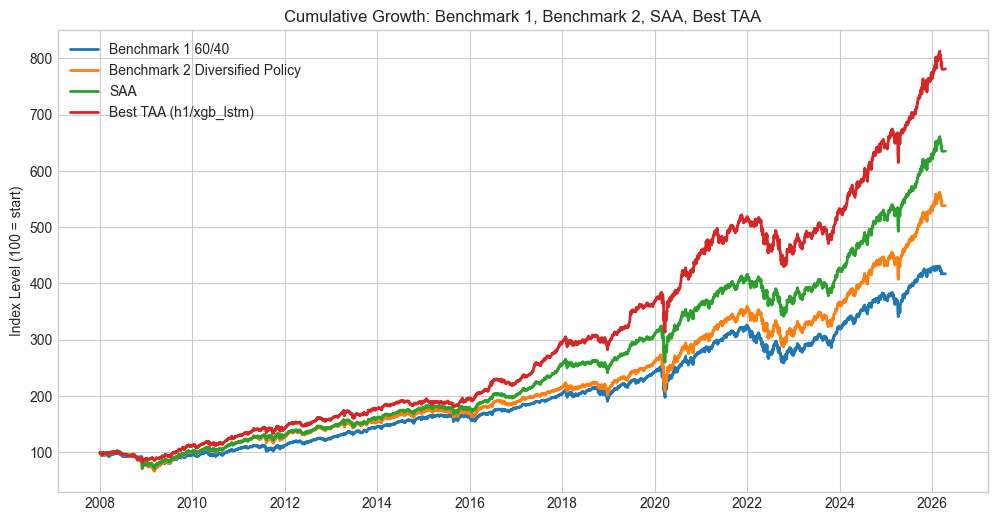

In [3]:
# Cumulative growth of the two benchmarks, SAA, and best TAA.
growth = (1.0 + all_returns).cumprod() * 100.0
fig, ax = plt.subplots(figsize=(12, 6))
for col in growth.columns:
    ax.plot(growth.index, growth[col], linewidth=2, label=col)
ax.set_title("Cumulative Growth: Benchmark 1, Benchmark 2, SAA, Best TAA")
ax.set_ylabel("Index Level (100 = start)")
ax.legend(loc="upper left")
plt.show()


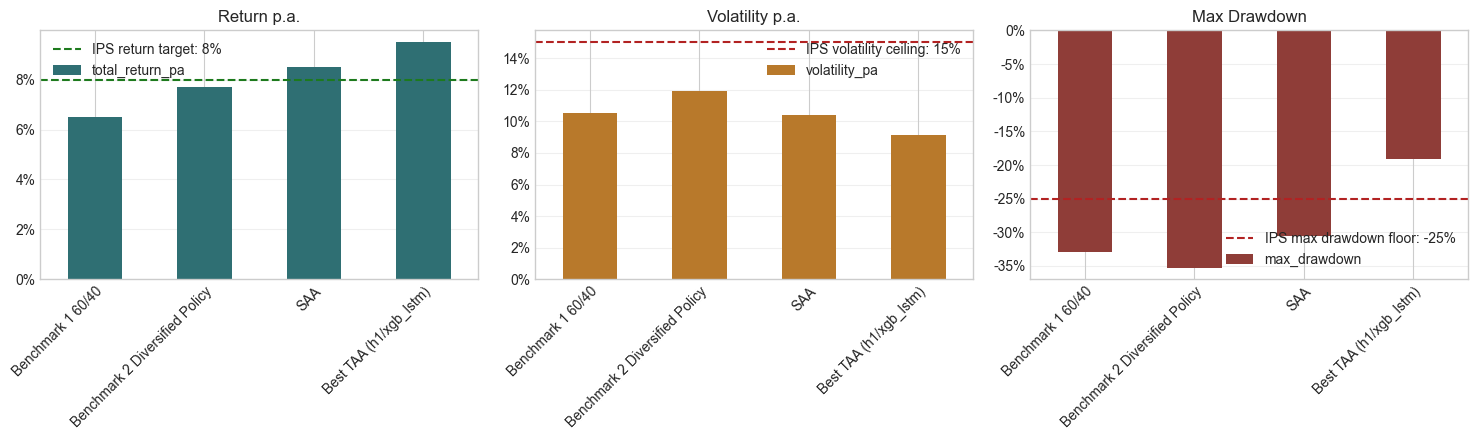

In [4]:
# IPS target bars for the four required portfolios.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
plot_metrics = metrics[["total_return_pa", "volatility_pa", "max_drawdown"]].copy()

plot_metrics["total_return_pa"].plot(kind="bar", ax=axes[0], color="#2f6f73")
axes[0].axhline(IPS_RETURN_TARGET, color="#1d7a1d", linestyle="--", linewidth=1.5, label="IPS return target: 8%")
axes[0].set_title("Return p.a.")
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[0].legend(loc="best")

plot_metrics["volatility_pa"].plot(kind="bar", ax=axes[1], color="#b8792b")
axes[1].axhline(IPS_VOL_TARGET, color="#b22222", linestyle="--", linewidth=1.5, label="IPS volatility ceiling: 15%")
axes[1].set_title("Volatility p.a.")
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[1].legend(loc="best")

plot_metrics["max_drawdown"].plot(kind="bar", ax=axes[2], color="#8f3d38")
axes[2].axhline(IPS_MAX_DRAWDOWN_TARGET, color="#b22222", linestyle="--", linewidth=1.5, label="IPS max drawdown floor: -25%")
axes[2].set_title("Max Drawdown")
axes[2].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
axes[2].legend(loc="best")

for ax in axes:
    plt.setp(
        ax.get_xticklabels(),
        rotation=45,
        ha="right",
        rotation_mode="anchor",
    )
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


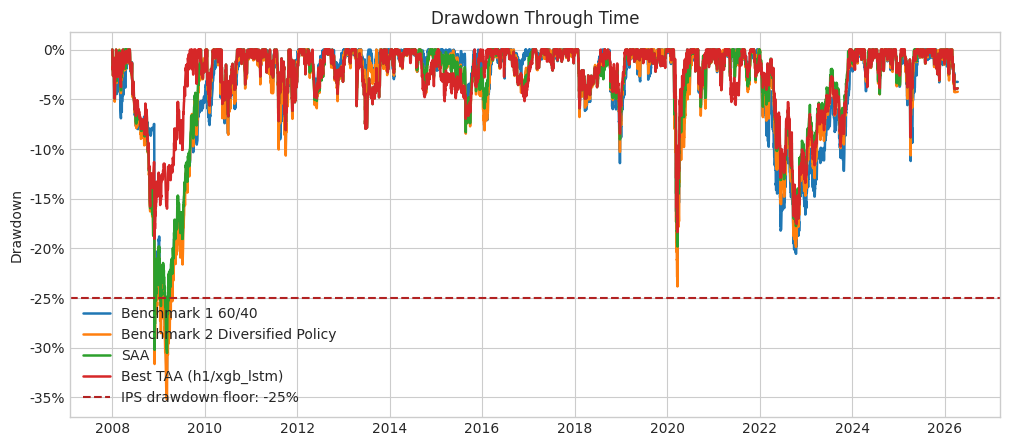

In [5]:
# Drawdown chart for both benchmarks, SAA, and best TAA.
drawdowns = growth.divide(growth.cummax()).subtract(1.0)
fig, ax = plt.subplots(figsize=(12, 5))
for col in drawdowns.columns:
    ax.plot(drawdowns.index, drawdowns[col], linewidth=1.8, label=col)
ax.axhline(IPS_MAX_DRAWDOWN_TARGET, color="#b22222", linestyle="--", linewidth=1.5, label="IPS drawdown floor: -25%")
ax.set_title("Drawdown Through Time")
ax.set_ylabel("Drawdown")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(loc="lower left")
plt.show()


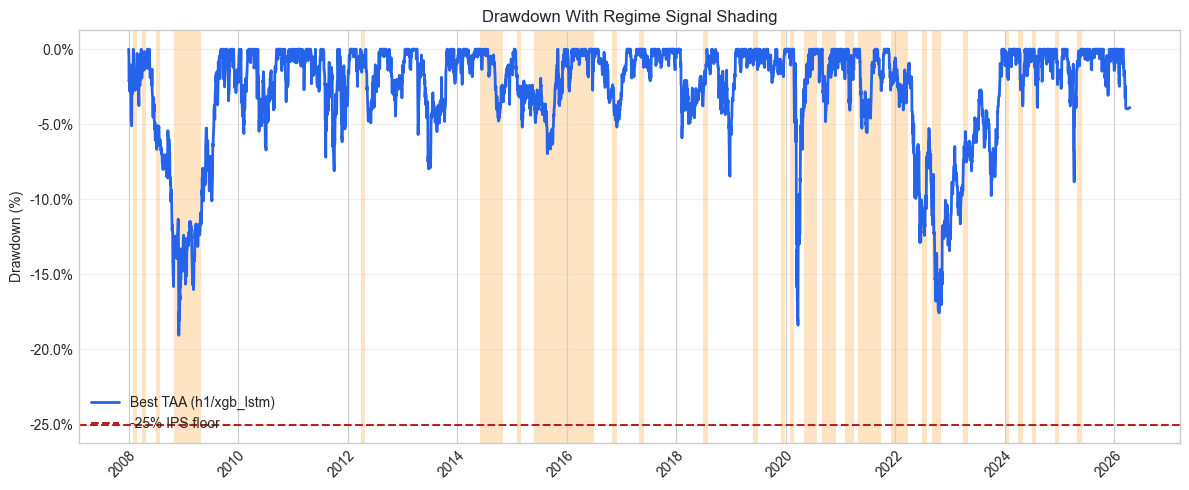

In [5]:
# Selected hybrid TAA drawdown with regime-signal shading (months where signal != 0, as-of merged to daily dates).
_sig = pd.read_csv(best_dir / "signal.csv", parse_dates=["date"]).sort_values("date")
_left = pd.DataFrame({"date": taa_returns.index}).assign(_ord=lambda d: np.arange(len(d)))
_merged = pd.merge_asof(
    _left.sort_values("date"),
    _sig.rename(columns={"signal": "signal"}),
    on="date",
    direction="backward",
).sort_values("_ord")
_mask = _merged["signal"].fillna(0).ne(0).to_numpy()

_equity = (1.0 + taa_returns).cumprod()
_dd = _equity / _equity.cummax() - 1.0

fig, ax = plt.subplots(figsize=(12, 5))
_i = 0
_n = len(_mask)
while _i < _n:
    if not _mask[_i]:
        _i += 1
        continue
    _s = _i
    while _i < _n and _mask[_i]:
        _i += 1
    ax.axvspan(
        taa_returns.index[_s],
        taa_returns.index[_i - 1],
        facecolor="#fdb863",
        alpha=0.38,
        zorder=0,
        linewidth=0,
    )

ax.plot(_dd.index, _dd.values, linewidth=2, color="#2563eb", zorder=2, label=str(taa_returns.name))
ax.axhline(
    IPS_MAX_DRAWDOWN_TARGET,
    color="#b22222",
    linestyle="--",
    linewidth=1.5,
    zorder=2,
    label=f"{IPS_MAX_DRAWDOWN_TARGET:.0%} IPS floor",
)
ax.set_title("Drawdown With Regime Signal Shading")
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.1%}")
ax.legend(loc="lower left")
ax.grid(axis="y", alpha=0.3)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()


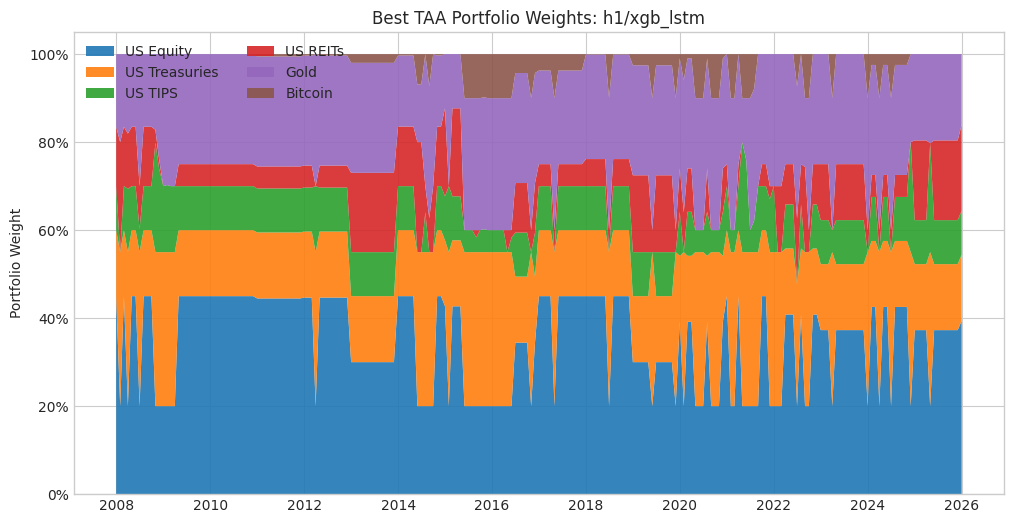

,min,mean,max,last
US Equity,20.00%,34.97%,45.00%,39.39%
Gold,10.00%,24.38%,30.00%,16.04%
US Treasuries,15.00%,20.59%,35.00%,15.00%
US TIPS,0.00%,9.10%,25.00%,10.00%
US REITs,0.00%,8.47%,25.00%,19.58%
Bitcoin,0.00%,2.49%,10.00%,0.00%


In [6]:
# Asset weights for the selected TAA portfolio.
weights = pd.read_csv(best_dir / "taa_weights.csv", parse_dates=["rebalance_date"], index_col="rebalance_date")
weights = weights.reindex(columns=ASSET_ORDER).fillna(0.0)

fig, ax = plt.subplots(figsize=(12, 6))
ax.stackplot(weights.index, [weights[col] for col in weights.columns], labels=weights.columns, alpha=0.9)
ax.set_title(f"Best TAA Portfolio Weights: {best_artifact['hypothesis']}/{best_artifact['model']}")
ax.set_ylabel("Portfolio Weight")
ax.yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(loc="upper left", ncol=2)
plt.show()

weight_summary = pd.DataFrame({
    "min": weights.min(),
    "mean": weights.mean(),
    "max": weights.max(),
    "last": weights.iloc[-1],
}).sort_values("mean", ascending=False)
display(weight_summary.style.format("{:.2%}"))


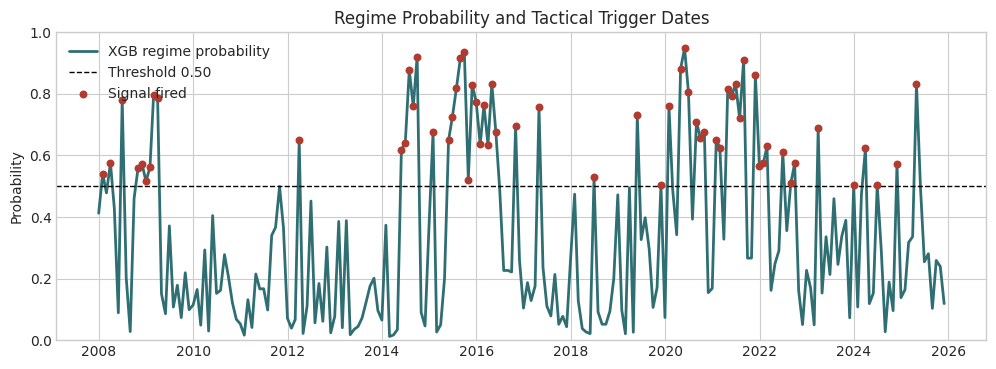

In [7]:
# Regime probability and trigger chart for the selected run.
proba = pd.read_csv(best_dir / "xgb_probability.csv", parse_dates=["date"], index_col="date")["probability"]
signal = pd.read_csv(best_dir / "signal.csv", parse_dates=["date"], index_col="date")["signal"]
selected_trial = search.loc[
    (search["hypothesis"] == best_artifact["hypothesis"])
    & (search["model"] == best_artifact["model"])
    & (search["ips_objective"] == search.loc[(search["hypothesis"] == best_artifact["hypothesis"]) & (search["model"] == best_artifact["model"]), "ips_objective"].min())
].iloc[0]
threshold = float(selected_trial["threshold"])

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(proba.index, proba, linewidth=2, color="#2f6f73", label="XGB regime probability")
ax.axhline(threshold, color="black", linestyle="--", linewidth=1, label=f"Threshold {threshold:.2f}")
active = signal[signal != 0]
ax.scatter(active.index, proba.reindex(active.index), color="#b23a2e", s=22, label="Signal fired", zorder=3)
ax.set_title("Regime Probability and Tactical Trigger Dates")
ax.set_ylabel("Probability")
ax.set_ylim(0, 1)
ax.legend(loc="upper left")
plt.show()


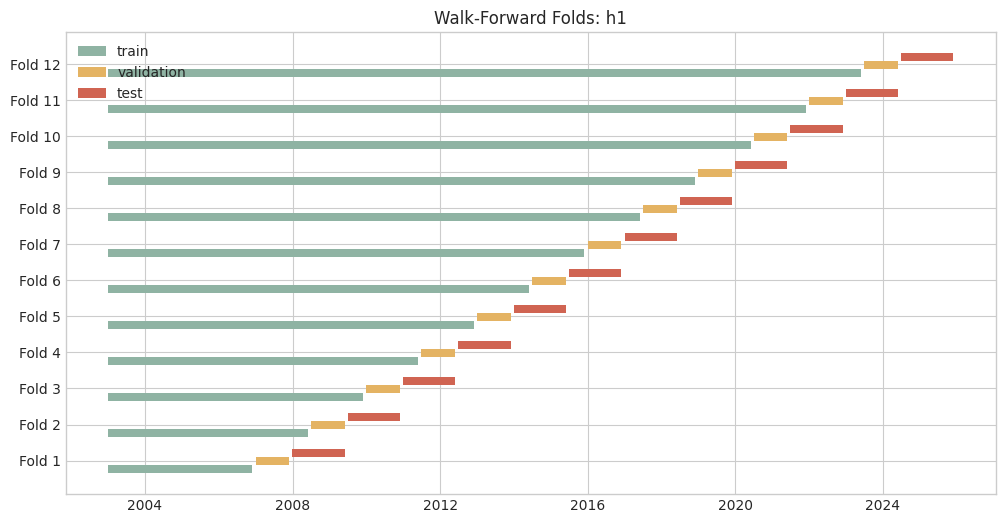

In [8]:
# Walk-forward fold structure for the selected hypothesis.
_, X, _ = prepare_dataset(str(best_artifact["hypothesis"]), panel=panel)
folds = make_folds(pd.DatetimeIndex(X.index))
fig, ax = plt.subplots(figsize=(12, 6))
colors = {"train": "#8fb3a3", "validation": "#e4b363", "test": "#d06452"}
for i, fold in enumerate(folds, start=1):
    y0 = i - 0.35
    for label, idx in [("train", fold.train), ("validation", fold.validation), ("test", fold.test)]:
        if len(idx) == 0:
            continue
        start = mdates.date2num(pd.Timestamp(idx.min()))
        end = mdates.date2num(pd.Timestamp(idx.max()))
        ax.broken_barh([(start, max(end - start, 10))], (y0, 0.22), facecolors=colors[label], label=label if i == 1 else None)
        y0 += 0.22
ax.set_title(f"Walk-Forward Folds: {best_artifact['hypothesis']}")
ax.set_yticks(range(1, len(folds) + 1))
ax.set_yticklabels([f"Fold {i}" for i in range(1, len(folds) + 1)])
ax.xaxis_date()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend(loc="upper left")
plt.show()


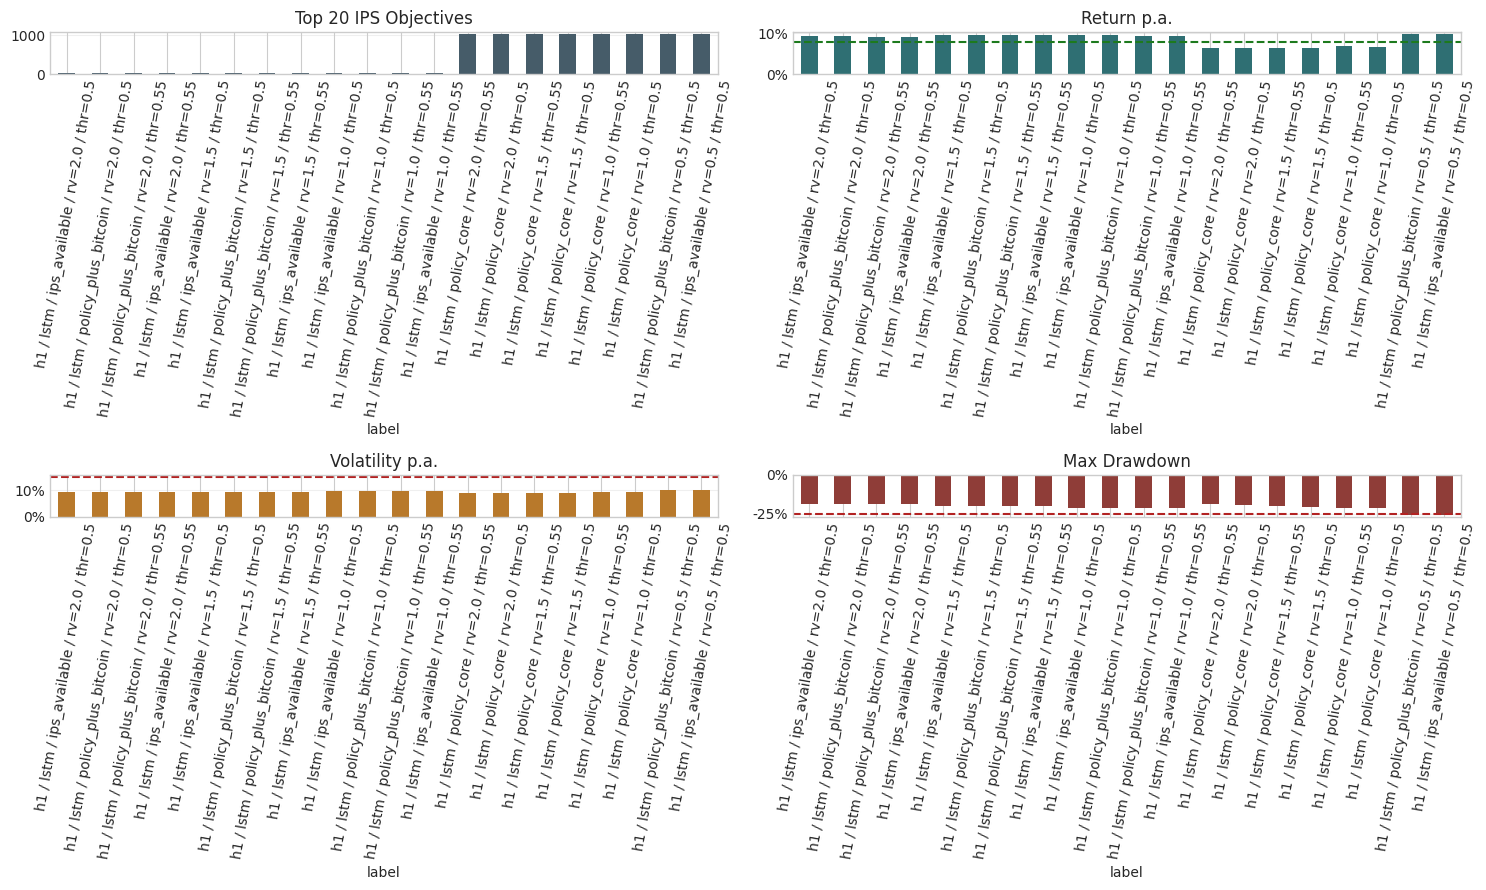

In [9]:
# Cross-trial bars: all rerun search rows, sorted by IPS objective.
plot_df = search.copy()
plot_df["label"] = (
    plot_df["hypothesis"].astype(str)
    + " / "
    + plot_df["model"].str.replace("xgb_", "", regex=False)
    + " / "
    + plot_df["asset_setup"].astype(str)
    + " / rv="
    + plot_df["regime_view_scale"].astype(str)
    + " / thr="
    + plot_df["threshold"].astype(str)
)
plot_df = plot_df.sort_values("ips_objective").head(20)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
plot_df.plot.bar(x="label", y="ips_objective", ax=axes[0, 0], legend=False, color="#465c69")
axes[0, 0].set_title("Top 20 IPS Objectives")

plot_df.plot.bar(x="label", y="return_pa", ax=axes[0, 1], legend=False, color="#2f6f73")
axes[0, 1].axhline(IPS_RETURN_TARGET, color="#1d7a1d", linestyle="--", linewidth=1.5)
axes[0, 1].set_title("Return p.a.")
axes[0, 1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plot_df.plot.bar(x="label", y="vol_pa", ax=axes[1, 0], legend=False, color="#b8792b")
axes[1, 0].axhline(IPS_VOL_TARGET, color="#b22222", linestyle="--", linewidth=1.5)
axes[1, 0].set_title("Volatility p.a.")
axes[1, 0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

plot_df.plot.bar(x="label", y="max_dd", ax=axes[1, 1], legend=False, color="#8f3d38")
axes[1, 1].axhline(IPS_MAX_DRAWDOWN_TARGET, color="#b22222", linestyle="--", linewidth=1.5)
axes[1, 1].set_title("Max Drawdown")
axes[1, 1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

for ax in axes.flat:
    plt.setp(
        ax.get_xticklabels(),
        rotation=80,
        ha="right",
        rotation_mode="anchor",
    )
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


**(Continues Part 3 — robustness)**

- **Training / retraining** is confined to **Part 4** (tagged optional); not required for Monte Carlo.

### Monte Carlo Simulation (path randomization)

The cell below runs **Monte Carlo simulations on the realized TAA daily return series** already loaded in this notebook. It does **not** re-estimate XGB or neural models.

**Fan chart (first figure):** Many **light grey** cumulative wealth paths are built from **block-bootstrapped** resamples of the same daily returns. The **realized TAA** path is drawn in **bold white** on a **dark** plot background so it stands out against the null cloud. That shows where the actual strategy’s wealth trajectory sits relative to “alternative histories” from the same return distribution—not a substitute for the trial-search disclosure below.

**What it tests**

1. **Permutation null (IID shuffle of days):** Keeps the *same* daily returns but destroys their **time order**. Recomputed metrics answer: “If timing were meaningless, how often would a random reorder produce Sharpe / IPS objective as strong as we actually got?” A realized Sharpe **above** most permuted paths suggests the *path* is not a typical draw from a “no-structure” reordering of the same data.

2. **Block bootstrap:** Resamples **overlapping blocks** of consecutive days (preserves some volatility clustering) to approximate **sampling uncertainty** around the historical path.

**How to read the p-values**

- **Permutation:** A **small** one-sided *p* for IPS objective (few shuffled paths beat your objective) or for Sharpe (few shuffled paths match your Sharpe) is consistent with “the realized *ordering* of daily returns is not something we’d often see if timing were meaningless.” A **large** *p* means many random reorderings look as strong on these metrics — the path is easier to “match” by chance.
- **Block bootstrap:** Summarizes **how unusual the historical path is** relative to alternative paths drawn by resampling blocks of the *same* daily returns — a **sensitivity** view, not a pure “no signal” null.

**What it does *not* fix**

- **Model / trial search:** Picking the best row in `search_results.csv` across thresholds, assets, and regime-view scales is **multiple testing**. Honest disclosure is still the primary control (see `search_results.csv` and `results.tsv`). This MC is an extra **path-level** check, not a substitute for White/SPA-style correction across trials.


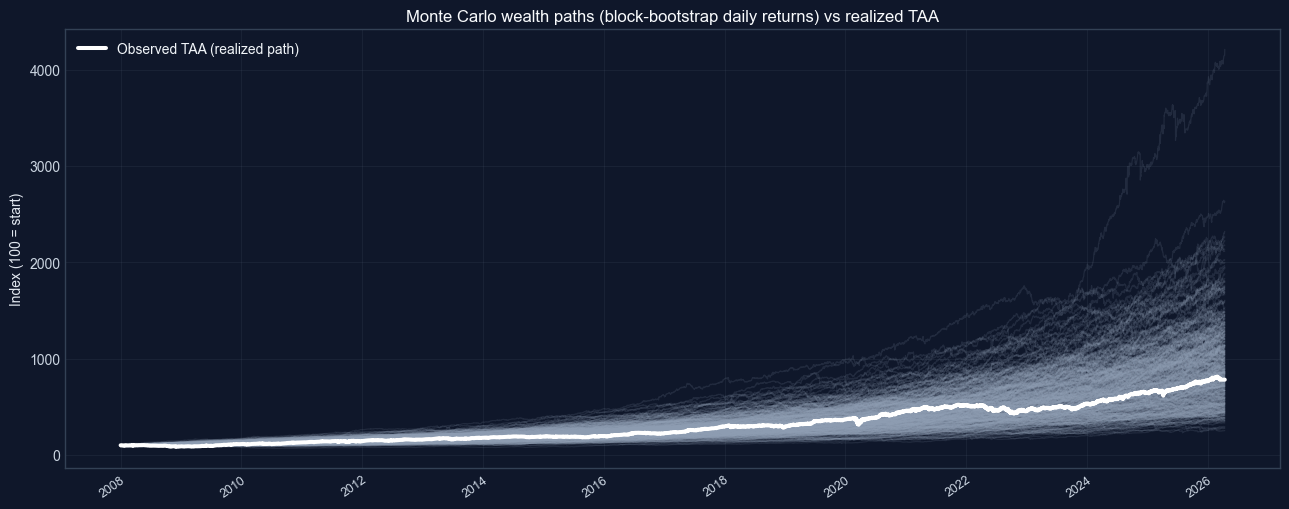

**Simulations:** 800 | **block length:** 21 trading days | **seed:** 3619

**p-values (one-sided):** For IPS objective, *p* = fraction of simulated paths at least as good as observed (≤ objective). For Sharpe, *p* = fraction with Sharpe ≥ observed.

,metric,observed,perm_p_one_sided,boot_p_one_sided
0,IPS objective (lower better),18.6977,0.662,0.552
1,Sharpe (rf=2%),0.8196,0.906,0.546


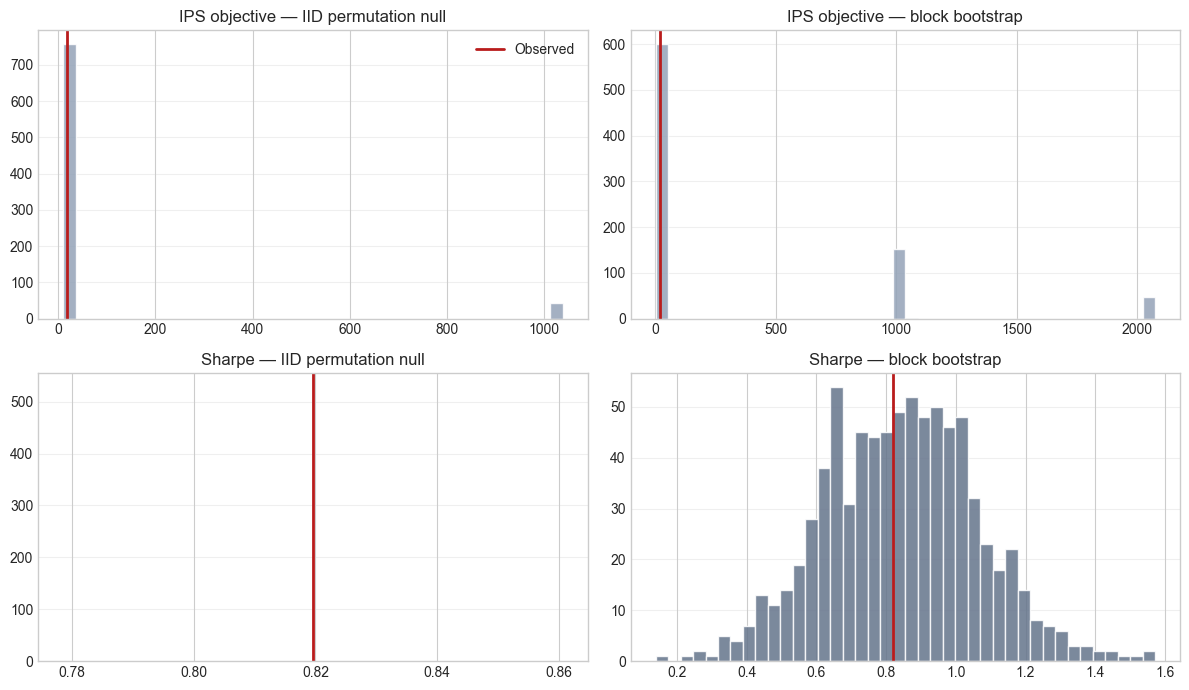

In [11]:
# Monte Carlo: permutation + block bootstrap on realized TAA daily returns. Requires embedded loader (Part 2) + artifact/benchmark cells so `taa_returns` exists.

from backtesting.core.ips import ips_objective

MC_SIMS = 800
SPAGHETTI_PATHS = 500  # cumulative wealth fan (block bootstrap); keep moderate for render speed
BLOCK_LEN = 21
RNG_SEED = 3619

_r = taa_returns.dropna().astype(float)
_obs = compute_metrics(_r)
_obs_obj = ips_objective(_obs)
_obs_sharpe = float(_obs["sharpe_rf2"])
_vals = _r.values
_idx = _r.index
_n = len(_vals)
rng = np.random.default_rng(RNG_SEED)


def _block_bootstrap_array(x: np.ndarray, block: int, rng: np.random.Generator) -> np.ndarray:
    """Resample with replacement until length n using contiguous blocks."""
    if _n == 0:
        return x
    max_start = max(0, len(x) - block)
    out: list[float] = []
    while len(out) < _n:
        s = int(rng.integers(0, max_start + 1)) if max_start >= 0 else 0
        out.extend(x[s : s + block])
    return np.asarray(out[:_n], dtype=float)


def _sim_hist(ax, sims: np.ndarray, *, max_bins: int = 40, **hist_kw) -> None:
    """Histogram that tolerates near-constant arrays (avoids matplotlib bin errors)."""
    x = np.asarray(sims, dtype=float)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return
    span = float(np.ptp(x))
    if not np.isfinite(span) or span == 0.0:
        ax.hist(x, bins=1, **hist_kw)
        return
    nu = len(np.unique(np.round(x, 10)))
    n_bins = min(max_bins, max(5, nu))
    for nb in (n_bins, max(3, n_bins // 2), 10, 5, 1):
        try:
            ax.hist(x, bins=nb, **hist_kw)
            return
        except ValueError:
            continue


perm_objs = np.empty(MC_SIMS)
perm_sharpes = np.empty(MC_SIMS)
boot_objs = np.empty(MC_SIMS)
boot_sharpes = np.empty(MC_SIMS)

for i in range(MC_SIMS):
    p = rng.permutation(_vals)
    mp = compute_metrics(pd.Series(p, index=_idx))
    perm_objs[i] = ips_objective(mp)
    perm_sharpes[i] = float(mp["sharpe_rf2"])

    b = _block_bootstrap_array(_vals, BLOCK_LEN, rng)
    mb = compute_metrics(pd.Series(b, index=_idx))
    boot_objs[i] = ips_objective(mb)
    boot_sharpes[i] = float(mb["sharpe_rf2"])

# --- Cumulative wealth: many block-bootstrap paths (grey) vs actual TAA (white on dark axis) ---
_wealth_actual = (1.0 + _r).cumprod() * 100.0
_rng_fan = np.random.default_rng(RNG_SEED + 9_001)
fig_fan, ax_fan = plt.subplots(figsize=(13, 5.2))
ax_fan.set_facecolor("#0f172a")
fig_fan.patch.set_facecolor("#0f172a")
for _ in range(SPAGHETTI_PATHS):
    _syn = _block_bootstrap_array(_vals, BLOCK_LEN, _rng_fan)
    _w = np.cumprod(1.0 + _syn) * 100.0
    ax_fan.plot(_idx, _w, color="#94a3b8", alpha=0.14, linewidth=0.85, zorder=1)
ax_fan.plot(
    _idx,
    _wealth_actual.values,
    color="white",
    linewidth=2.9,
    zorder=5,
    label="Observed TAA (realized path)",
)
ax_fan.set_title(
    "Monte Carlo wealth paths (block-bootstrap daily returns) vs realized TAA",
    color="#f8fafc",
    fontsize=12,
)
ax_fan.set_ylabel("Index (100 = start)", color="#e2e8f0")
ax_fan.tick_params(axis="x", colors="#cbd5e1", labelsize=9)
ax_fan.tick_params(axis="y", colors="#cbd5e1")
ax_fan.grid(True, alpha=0.12, color="#64748b")
ax_fan.legend(loc="upper left", facecolor="#1e293b", edgecolor="#334155", labelcolor="#f1f5f9")
for spine in ax_fan.spines.values():
    spine.set_color("#334155")
plt.setp(ax_fan.get_xticklabels(), rotation=35, ha="right", rotation_mode="anchor")
plt.tight_layout()
plt.show()

# IPS objective: lower is better. One-sided "better than random timing" p-value:
# share of null paths with objective <= observed (as good or better).
p_perm_obj = float(np.mean(perm_objs <= _obs_obj))
p_boot_obj = float(np.mean(boot_objs <= _obs_obj))
# Sharpe: higher is better under permutation null
p_perm_sh = float(np.mean(perm_sharpes >= _obs_sharpe))
p_boot_sh = float(np.mean(boot_sharpes >= _obs_sharpe))

summary_mc = pd.DataFrame(
    {
        "metric": ["IPS objective (lower better)", "Sharpe (rf=2%)"],
        "observed": [_obs_obj, _obs_sharpe],
        "perm_p_one_sided": [p_perm_obj, p_perm_sh],
        "boot_p_one_sided": [p_boot_obj, p_boot_sh],
    }
)
display(
    Markdown(
        f"**Simulations:** {MC_SIMS} | **block length:** {BLOCK_LEN} trading days | **seed:** {RNG_SEED}\n\n"
        "**p-values (one-sided):** For IPS objective, *p* = fraction of simulated paths at least as good as observed (≤ objective). "
        "For Sharpe, *p* = fraction with Sharpe ≥ observed."
    )
)
display(summary_mc.style.format({"observed": "{:.4f}", "perm_p_one_sided": "{:.3f}", "boot_p_one_sided": "{:.3f}"}))

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
_sim_hist(axes[0, 0], perm_objs, color="#94a3b8", alpha=0.85, edgecolor="white")
axes[0, 0].axvline(_obs_obj, color="#b91c1c", linewidth=2, label="Observed")
axes[0, 0].set_title("IPS objective — IID permutation null")
axes[0, 0].legend()

_sim_hist(axes[0, 1], boot_objs, color="#94a3b8", alpha=0.85, edgecolor="white")
axes[0, 1].axvline(_obs_obj, color="#b91c1c", linewidth=2, label="Observed")
axes[0, 1].set_title("IPS objective — block bootstrap")

_sim_hist(axes[1, 0], perm_sharpes, color="#64748b", alpha=0.85, edgecolor="white")
axes[1, 0].axvline(_obs_sharpe, color="#b91c1c", linewidth=2, label="Observed")
axes[1, 0].set_title("Sharpe — IID permutation null")

_sim_hist(axes[1, 1], boot_sharpes, color="#64748b", alpha=0.85, edgecolor="white")
axes[1, 1].axvline(_obs_sharpe, color="#b91c1c", linewidth=2, label="Observed")
axes[1, 1].set_title("Sharpe — block bootstrap")

for ax in axes.flat:
    ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


---

**You do not need this section for the dashboards above.** Standard path: Parts **1→2→3** only; this notebook reads `backtesting/artifacts/`. Come here only when you want to regenerate models.

## Part 4 — Optional retraining (skip when `artifacts/` already has your run)

**Purpose:** regenerate hybrid checkpoints (XGB + LSTM/Transformer, BL/TAA).

After Part 2’s loader cell (`init_embedded_backtesting`), `train_main`, `run_threshold_search_main`, and `run_all_baselines_main` are defined — they mirror:

- ``python -m backtesting.train ...`` → walk-forward **XGB** classifier + **LSTM/Transformer** return model, BL/Markowitz TAA → writes ``backtesting/artifacts/`` + appends ``results.tsv``.
- ``python -m backtesting.run_threshold_search`` → compact multi-hypothesis hybrid sweep (+ ``search_results.csv``).
- ``python -m backtesting.run_all_baselines`` → broader baseline sweep.

**Dependencies:** PyTorch + xgboost (+ CUDA optional). Charts in Part 3 read existing artifacts unless you refresh them here.

Flip the boolean switches in the cells below (**default off** so a quick dashboard run does not accidentally train).


In [ ]:
# ---------- Single hybrid experiment (embedded `backtesting.train.main`) ----------
# Same as: python -m backtesting.train --hypothesis h1 --return-model lstm ...

SMOKE_TRAIN = False  # set True to execute (often minutes → hours depending on GPU/CPU)

if SMOKE_TRAIN:
    train_main(
        [
            "--hypothesis",
            "h1",
            "--return-model",
            "lstm",
            "--threshold",
            "0.55",
            "--seq-len",
            "6",
            "--assets",
            "US Equity",
            "US Treasuries",
            "US TIPS",
            "US REITs",
            "Gold",
            "Bitcoin",
            "--taa-band",
            "0.50",
            "--description",
            "notebook smoke — Whitmore hybrid xgb+lstm",
        ]
    )
else:
    from IPython.display import Markdown, display

    display(Markdown("**Training skipped** — set **`SMOKE_TRAIN = True`** to run `train_main` with the CLI list above, or customize the list inline."))


In [ ]:
# ---------- Compact threshold / hybrid sweep (embedded `run_threshold_search`) ----------
RUN_THRESHOLD_SEARCH = False  # mirrors `python -m backtesting.run_threshold_search`

if RUN_THRESHOLD_SEARCH:
    run_threshold_search_main()
else:
    from IPython.display import Markdown, display

    display(Markdown("**Threshold sweep skipped** — set **`RUN_THRESHOLD_SEARCH = True`**."))


In [ ]:
# ---------- Twelve hybrid baselines (embedded `run_all_baselines`) ----------
RUN_ALL_BASELINES = False  # mirrors `python -m backtesting.run_all_baselines`

if RUN_ALL_BASELINES:
    run_all_baselines_main()
else:
    from IPython.display import Markdown, display

    display(Markdown("**Baseline sweep skipped** — set **`RUN_ALL_BASELINES = True`**."))
